In [1]:
# ==========================================
# DATA MANIPULATION
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# DATA VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# ==========================================
# YOUTUBE API
# ==========================================

from googleapiclient.discovery import build

# ==========================================
# DATE & TIME
# ==========================================

from datetime import datetime
import isodate

# ==========================================
# UTILITIES
# ==========================================

import warnings
import ast

print("✅ All Libraries Imported Successfully")

# Ignore Warnings
warnings.filterwarnings("ignore")

# Pandas Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Visualization Theme
sns.set_style("whitegrid")

# Figure Size Default
plt.rcParams["figure.figsize"] = (10, 6)

print("✅ Notebook Environment Configured")

PROJECT_NAME = "AI-Powered YouTube Trending Video Analytics"

AUTHOR = "Mohammed Kaif"

VERSION = "1.0"

print("="*60)
print(PROJECT_NAME)
print("Author :", AUTHOR)
print("Version :", VERSION)
print("="*60)

✅ All Libraries Imported Successfully
✅ Notebook Environment Configured
AI-Powered YouTube Trending Video Analytics
Author : Mohammed Kaif
Version : 1.0


In [2]:
csv_path = r"D:\Data-Science-Project\YouTube_Analysis\Notebook_YT_Analysis\trending_videos.csv"

df = pd.read_csv(csv_path)

In [3]:
df.head()

,video_id,title,description,channel_id,channel_title,tags,duration,definition,caption,publish_date,publish_time,publish_month_name,publish_day_name,category_id,view_count,like_count,favorite_count,comment_count,publish_year,publish_month,publish_day,publish_week,publish_quarter,publish_hour,publish_minute,publish_second,published_at,published_at_date,is_weekend,duration_seconds,duration_category,title_length,title_word_count,description_length,description_word_count,tag_count,publish_session,engagement_score,like_rate,comment_rate,engagement_rate,is_hd,has_caption,view_bucket,month_part,channel_video_count,popular_category,weekend_flag,upload_time,category_name,Definition
0,afSgBNwmZrQ,Ariana Grande - petal (official music video),The official music video for Ariana Grande’s “...,UC0VOyT2OCBKdQhF3BAbZ-1g,ArianaGrandeVevo,"['Ariana Grande', 'Ariana Grande LP6', 'Pop', ...",PT6M51S,hd,True,2026-07-31,15:00:06,July,Friday,10,9356390,630087,0,58086,2026,7,31,31,3,15,0,6,2026-07-31 15:00:06+00:00,2026-07-31 15:00:06+00:00,False,411.0,Medium,44,7,953,105,4,Afternoon,688173,0.067343,0.006208,0.073551,1,1,Very High,End,1,False,False,Afternoon,Music,hd
1,PK5FfiDX4P4,Spider-Man Brand New Day Box Office Opening We...,Spider-Man Brand New Day Box Office today! Bey...,UCAXR2zenCwvRIyQd9ydtfaA,Beyond The Trailer,"['Spider-Man Brand New Day Box Office', 'Spide...",PT29M34S,hd,False,2026-08-02,23:54:06,August,Sunday,24,70900,3752,0,867,2026,8,2,31,3,23,54,6,2026-08-02 23:54:06+00:00,2026-08-02 23:54:06+00:00,True,1774.0,Long,96,16,1350,213,28,Evening,4619,0.052920,0.012228,0.065148,1,0,Low,Beginning,1,False,True,Night,Entertainment,hd
2,psGsc1n8Klw,Five Nights at Freddy's: ULTIMATE CUSTOM STREAM,I'M FINALLY SPONSORED!! Use code MARKIPLIER to...,UC7_YxT-KID8kRbqZo7MyscQ,Markiplier,"['markiplier', 'five nights at freddys', 'fnaf...",PT3H37S,hd,False,2026-08-02,23:35:14,August,Sunday,20,1181939,57390,0,784,2026,8,2,31,3,23,35,14,2026-08-02 23:35:14+00:00,2026-08-02 23:35:14+00:00,True,10837.0,Long,47,7,299,51,6,Evening,58174,0.048556,0.000663,0.049219,1,0,Very High,Beginning,1,True,True,Night,Gaming,hd
3,xXZwZ0DolJc,BABYMONSTER - 'MOON' M/V,MOON \n\nI’m the moon\n보름달 뜨는 밤 On the loose\n...,UCqwUnggBBct-AY2lAdI88jQ,BABYMONSTER,"['BABYMONSTER', '베이비몬스터', '베몬', 'BABYMON', 'BA...",PT2M55S,hd,True,2026-08-02,15:00:06,August,Sunday,10,6170913,499751,0,41985,2026,8,2,31,3,15,0,6,2026-08-02 15:00:06+00:00,2026-08-02 15:00:06+00:00,True,175.0,Medium,24,4,2795,523,19,Afternoon,541736,0.080985,0.006804,0.087789,1,1,Very High,Beginning,1,False,True,Afternoon,Music,hd
4,3FqCH-Q_3TM,WICKER | Official Trailer | 2026 [HD],A hard man is good to find. \n \nIn a seaside ...,UCSi5779nMiFTbLm3prHaa1g,Roadshow Films,[],PT2M36S,hd,False,2026-08-03,00:28:20,August,Monday,1,13512,225,0,19,2026,8,3,32,3,0,28,20,2026-08-03 00:28:20+00:00,2026-08-03 00:28:20+00:00,False,156.0,Medium,37,7,657,96,0,Night,244,0.016652,0.001406,0.018058,1,0,Low,Beginning,1,False,False,Late Night,Film & Animation,hd


In [4]:
df.columns

Index(['video_id', 'title', 'description', 'channel_id', 'channel_title',
       'tags', 'duration', 'definition', 'caption', 'publish_date',
       'publish_time', 'publish_month_name', 'publish_day_name', 'category_id',
       'view_count', 'like_count', 'favorite_count', 'comment_count',
       'publish_year', 'publish_month', 'publish_day', 'publish_week',
       'publish_quarter', 'publish_hour', 'publish_minute', 'publish_second',
       'published_at', 'published_at_date', 'is_weekend', 'duration_seconds',
       'duration_category', 'title_length', 'title_word_count',
       'description_length', 'description_word_count', 'tag_count',
       'publish_session', 'engagement_score', 'like_rate', 'comment_rate',
       'engagement_rate', 'is_hd', 'has_caption', 'view_bucket', 'month_part',
       'channel_video_count', 'popular_category', 'weekend_flag',
       'upload_time', 'category_name', 'Definition'],
      dtype='str')

In [5]:
df.dtypes

video_id                      str
title                         str
description                   str
channel_id                    str
channel_title                 str
tags                          str
duration                      str
definition                    str
caption                      bool
publish_date                  str
publish_time                  str
publish_month_name            str
publish_day_name              str
category_id                 int64
view_count                  int64
like_count                  int64
favorite_count              int64
comment_count               int64
publish_year                int64
publish_month               int64
publish_day                 int64
publish_week                int64
publish_quarter             int64
publish_hour                int64
publish_minute              int64
publish_second              int64
published_at                  str
published_at_date             str
is_weekend                   bool
duration_secon

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 199 entries, 0 to 198
Data columns (total 51 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   video_id                199 non-null    str    
 1   title                   199 non-null    str    
 2   description             195 non-null    str    
 3   channel_id              199 non-null    str    
 4   channel_title           199 non-null    str    
 5   tags                    199 non-null    str    
 6   duration                199 non-null    str    
 7   definition              199 non-null    str    
 8   caption                 199 non-null    bool   
 9   publish_date            199 non-null    str    
 10  publish_time            199 non-null    str    
 11  publish_month_name      199 non-null    str    
 12  publish_day_name        199 non-null    str    
 13  category_id             199 non-null    int64  
 14  view_count              199 non-null    int64  
 15  

## Problems & Data Insight's

In [7]:
#Channel Performance Report

df.groupby("channel_title").agg(

    Total_Videos=("video_id","count"),

    Total_Views=("view_count","sum"),

    Avg_Views=("view_count","mean"),

    Max_Views=("view_count","max"),

    Total_Likes=("like_count","sum"),

    Avg_Likes=("like_count","mean"),

    Total_Comments=("comment_count","sum"),

    Avg_Comments=("comment_count","mean")

).sort_values("Total_Views",ascending=False).head(20)

,Total_Videos,Total_Views,Avg_Views,Max_Views,Total_Likes,Avg_Likes,Total_Comments,Avg_Comments
channel_title,,,,,,,,
MrBeast Gaming,1,23654668,23654668.0,23654668,712711,712711.0,18971,18971.0
ArianaGrandeVevo,1,9356390,9356390.0,9356390,630087,630087.0,58086,58086.0
BABYMONSTER,1,6170913,6170913.0,6170913,499751,499751.0,41985,41985.0
KATSEYE,1,3794321,3794321.0,3794321,207682,207682.0,20211,20211.0
bennyblancoVEVO,1,3075542,3075542.0,3075542,151809,151809.0,6912,6912.0
SMii7Y,1,2624779,2624779.0,2624779,109983,109983.0,4186,4186.0
The Living Tombstone,1,1736525,1736525.0,1736525,127940,127940.0,9129,9129.0
Clash Royale,1,1668880,1668880.0,1668880,46492,46492.0,962,962.0
Rubius Z,1,1516717,1516717.0,1516717,68462,68462.0,2358,2358.0


In [8]:
# Category Performance

df.groupby("category_id").agg(

    Total_Videos=("video_id","count"),

    Total_Views=("view_count","sum"),

    Average_Views=("view_count","mean"),

    Total_Likes=("like_count","sum"),

    Average_Likes=("like_count","mean")

).sort_values("Total_Views",ascending=True)

,Total_Videos,Total_Views,Average_Views,Total_Likes,Average_Likes
category_id,,,,,
1,1,13512,1.351200e+04,225,225.000000
17,1,169473,1.694730e+05,7293,7293.000000
23,1,338216,3.382160e+05,18851,18851.000000
22,4,503789,1.259472e+05,8261,2065.250000
24,11,3188988,2.899080e+05,92292,8390.181818
10,24,31051962,1.293832e+06,1822963,75956.791667
20,157,62627153,3.988991e+05,2061537,13130.808917


In [9]:
# HD vs SD Performance

df.groupby("definition").agg(

    Total_Videos=("video_id","count"),

    Average_Views=("view_count","mean"),

    Average_Likes=("like_count","mean"),

    Average_Comments=("comment_count","mean")

)

,Total_Videos,Average_Views,Average_Likes,Average_Comments
definition,,,,
hd,197,495616.253807,20301.720812,1471.395939
sd,2,128345.500000,5991.500000,384.500000


In [10]:
#Caption Performance

df.groupby("caption").agg(

    Videos=("video_id","count"),

    Views=("view_count","mean"),

    Likes=("like_count","mean"),

    Comments=("comment_count","mean")

)

,Videos,Views,Likes,Comments
caption,,,,
False,188,2.862671e+05,10014.489362,844.138298
True,11,4.006807e+06,193518.000000,11994.181818


In [11]:
# Upload Hour Analysis

df.groupby("publish_hour").agg(

    Videos=("video_id","count"),

    Views=("view_count","mean"),

    Likes=("like_count","mean"),

    Comments=("comment_count","mean")).round(2).sort_values("Views",ascending=False)

,Videos,Views,Likes,Comments
publish_hour,,,,
16,19,1721406.79,64136.84,3116.74
15,12,1506709.17,101222.42,9135.75
4,8,652844.75,23842.50,1012.12
12,4,452990.25,22560.00,3828.75
14,13,402381.85,11510.00,678.77
11,4,394854.00,12094.75,670.00
21,10,356465.90,8843.20,749.20
23,11,349209.18,12195.55,647.00
19,17,347159.59,12444.35,839.06


In [12]:
# Weekday Performance

df.groupby("publish_day").agg(

    Total_Views=("view_count","sum"),

    Avg_Views=("view_count","mean"),

    Avg_Likes=("like_count","mean")

).round(2)

,Total_Views,Avg_Views,Avg_Likes
publish_day,,,
1,35670724,1621396.55,50618.36
2,28606061,255411.26,12266.41
3,8487539,173215.08,4056.39
4,56035,56035.00,1721.00
7,33799,33799.00,391.00
10,255239,255239.00,6763.00
26,443181,443181.00,1144.00
29,55223,55223.00,216.00
31,24285292,2207753.82,119543.82


In [13]:
# Monthly Performance

df.groupby("publish_month").agg(

    Videos=("video_id","count"),

    Views=("view_count","sum"),

    Likes=("like_count","sum"),

    Comments=("comment_count","sum")

)

,Videos,Views,Likes,Comments
publish_month,,,,
7,16,25128769,1325217,104955
8,183,72764324,2686205,185679


In [14]:
# Year-wise Analysis

df.groupby("publish_year").agg(

    Videos=("video_id","count"),

    Views=("view_count","sum")

)

,Videos,Views
publish_year,,
2026,199,97893093


In [15]:
# Average Title Length by Category & # Average Duration by Category

df.groupby("category_id").agg(

    Avg_Title_Length=("title_length","mean"),
    Avg_Duration=("duration_seconds","mean")

)

,Avg_Title_Length,Avg_Duration
category_id,,
1,37.000000,156.000000
10,45.041667,653.500000
17,48.000000,1986.000000
20,44.547771,6590.082803
22,53.250000,3407.250000
23,33.000000,166.000000
24,43.090909,8168.545455


In [16]:
# Average Duration by Channel

df.groupby("channel_title").agg(

    Avg_Duration=("duration_seconds","mean")

).sort_values("Avg_Duration",ascending=False).head(20)

,Avg_Duration
channel_title,
AussieAntics,42900.0
LarryLurr,42423.0
Overwatch Esports,31849.0
KYRSP33DY,31740.0
DarkViperAU,31338.0
FNS,30989.0
PointCrow,30491.0
Gigi Murin Ch. hololive-EN,29487.0
Bundun,29172.0


In [17]:
# Longest Videos by Channel

df.groupby("channel_title").agg(

    Max_Duration=("duration_seconds","max")

).sort_values("Max_Duration",ascending=False).head(20)

,Max_Duration
channel_title,
AussieAntics,42900.0
LarryLurr,42423.0
Overwatch Esports,31849.0
KYRSP33DY,31740.0
DarkViperAU,31338.0
FNS,30989.0
PointCrow,30491.0
Gigi Murin Ch. hololive-EN,29487.0
Bundun,29172.0


In [18]:
# Most Liked Channels
df.groupby("channel_title").agg(

    Total_Likes=("like_count","sum")

).sort_values("Total_Likes",ascending=False).head(20)

,Total_Likes
channel_title,
MrBeast Gaming,712711
ArianaGrandeVevo,630087
BABYMONSTER,499751
KATSEYE,207682
bennyblancoVEVO,151809
The Living Tombstone,127940
SMii7Y,109983
Rubius Z,68462
Asmongold TV,58190


In [19]:
# Most Commented Channels

df.groupby("channel_title").agg(

    Total_Comments=("comment_count","sum")

).sort_values("Total_Comments",ascending=False).head(20)

,Total_Comments
channel_title,
ArianaGrandeVevo,58086
BABYMONSTER,41985
KATSEYE,20211
MrBeast Gaming,18971
Asmongold TV,9238
The Living Tombstone,9129
bennyblancoVEVO,6912
MandJTV,5033
LookOut2DD,4833


In [20]:
# Category-wise Maximum Views

df.groupby("category_id").agg(

    Max_Views=("view_count","max"),

    Min_Views=("view_count","min")

)

,Max_Views,Min_Views
category_id,,
1,13512,13512
10,9356390,33799
17,169473,169473
20,23654668,16178
22,378281,36419
23,338216,338216
24,722184,35055


In [21]:
# Channel Statistics

df.groupby("channel_title").agg(

    Mean_Views=("view_count","mean"),

    Median_Views=("view_count","median"),

).head(20)

,Mean_Views,Median_Views
channel_title,,
2FithyRicky,506094.0,506094.0
7clouds Rock,378281.0,378281.0
AVEX_ - Topic,56035.0,56035.0
Aminimii,99974.0,99974.0
Aphmau,278367.0,278367.0
ArianaGrandeVevo,9356390.0,9356390.0
Asmongold TV,1187180.0,1187180.0
Aura Country,55223.0,55223.0
Aura Serenity,443181.0,443181.0


In [22]:
# Upload Hour Statistics

display(
    df.groupby("publish_hour").agg(

    Mean_Views=("view_count","mean"),

    Median_Views=("view_count","median"),

    Std_Views=("view_count","std")

).round(2).astype(int)
)

,Mean_Views,Median_Views,Std_Views
publish_hour,,,
0,305688,252255,280487
1,126467,86812,113177
2,265517,248344,270015
3,290933,193648,300132
4,652844,331430,1016795
5,203397,144252,170702
6,221374,127691,272420
7,111638,90694,92672
8,211507,132565,200757


In [23]:
# Monthly Statistics

df.groupby("publish_month").agg(

    Mean_Likes=("like_count","mean"),

    Max_Likes=("like_count","max"),

    Min_Likes=("like_count","min")

)

,Mean_Likes,Max_Likes,Min_Likes
publish_month,,,
7,82826.062500,630087,216
8,14678.715847,712711,142


In [24]:
# Category Full Statistical Report

df.groupby("category_id").agg(

    Count=("video_id","count"),

    Sum=("view_count","sum"),

    Mean=("view_count","mean"),

    Median=("view_count","median"),

    Min=("view_count","min"),

    Max=("view_count","max"),

    Std=("view_count","std"),

    Variance=("view_count","var")
).round(
    {
        "Mean" : 0,
        "Std" : 0,
        "Variance" : 0 
    })

,Count,Sum,Mean,Median,Min,Max,Std,Variance
category_id,,,,,,,,
1,1,13512,13512.0,13512.0,13512,13512,NaN,NaN
10,24,31051962,1293832.0,397520.0,33799,9356390,2251671.0,5.070022e+12
17,1,169473,169473.0,169473.0,169473,169473,NaN,NaN
20,157,62627153,398899.0,133655.0,16178,23654668,1897833.0,3.601770e+12
22,4,503789,125947.0,44544.5,36419,378281,168341.0,2.833867e+10
23,1,338216,338216.0,338216.0,338216,338216,NaN,NaN
24,11,3188988,289908.0,236542.0,35055,722184,243150.0,5.912184e+10


In [25]:
# Executive KPI Report

df.groupby("category_id").agg(

    Videos=("video_id","count"),

    Views=("view_count","sum"),

    Likes=("like_count","sum"),

    Comments=("comment_count","sum"),

    Avg_Duration=("duration_seconds","mean"),

    Avg_Title=("title_length","mean")
).round({
        "Avg-Duration" : 0,
        "Avg_Title" : 0
    }).sort_values("Views",ascending=False)

,Videos,Views,Likes,Comments,Avg_Duration,Avg_Title
category_id,,,,,,
20,157,62627153,2061537,128669,6590.082803,45.0
10,24,31051962,1822963,148272,653.500000,45.0
24,11,3188988,92292,10462,8168.545455,43.0
22,4,503789,8261,1705,3407.250000,53.0
23,1,338216,18851,1120,166.000000,33.0
17,1,169473,7293,387,1986.000000,48.0
1,1,13512,225,19,156.000000,37.0


In [26]:
category_kpi = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum"),

        Avg_Views=("view_count","mean"),

        Avg_Likes=("like_count","mean"),

        Avg_Comments=("comment_count","mean"),

        Avg_Engagement=("engagement_rate","mean"),

        Avg_Duration=("duration_seconds","mean")

    )

)

category_kpi["View_Share_%"]=(

category_kpi["Total_Views"]

/

category_kpi["Total_Views"].sum()

*100

).round(2)

category_kpi["Running_View_%"]=(
category_kpi["View_Share_%"]
.cumsum()
.round(2)
)

category_kpi["Rank"]=(
category_kpi["Total_Views"]
.rank(method="dense",ascending=False)
.astype(int)
)

category_kpi.sort_values(
"Total_Views",
ascending=False
)

,category_name,Total_Videos,Total_Views,Total_Likes,Total_Comments,Avg_Views,Avg_Likes,Avg_Comments,Avg_Engagement,Avg_Duration,View_Share_%,Running_View_%,Rank
3,Gaming,157,62627153,2061537,128669,3.988991e+05,13130.808917,819.547771,0.041309,6590.082803,63.98,67.60,1
4,Music,24,31051962,1822963,148272,1.293832e+06,75956.791667,6178.000000,0.044021,653.500000,31.72,99.32,2
1,Entertainment,11,3188988,92292,10462,2.899080e+05,8390.181818,951.090909,0.045450,8168.545455,3.26,3.61,3
5,People & Blogs,4,503789,8261,1705,1.259472e+05,2065.250000,426.250000,0.045081,3407.250000,0.51,99.83,4
0,Comedy,1,338216,18851,1120,3.382160e+05,18851.000000,1120.000000,0.059048,166.000000,0.35,0.35,5
6,Sports,1,169473,7293,387,1.694730e+05,7293.000000,387.000000,0.045317,1986.000000,0.17,100.00,6
2,Film & Animation,1,13512,225,19,1.351200e+04,225.000000,19.000000,0.018058,156.000000,0.01,3.62,7


In [27]:
session_kpi=(

df

.groupby("publish_session",as_index=False)

.agg(

Videos=("video_id","count"),

Views=("view_count","sum"),

Likes=("like_count","sum"),

Comments=("comment_count","sum"),

Avg_Engagement=("engagement_rate","mean")

)

.assign(

ViewShare=lambda x:

(x["Views"]/x["Views"].sum()*100)

.round(2)

)

.sort_values(

"Views",

ascending=False

)

)

session_kpi

,publish_session,Videos,Views,Likes,Comments,Avg_Engagement,ViewShare
0,Afternoon,69,60900254,2758054,193731,0.042753,62.21
1,Evening,55,15679693,551022,39119,0.047064,16.02
3,Night,52,15231181,525449,38528,0.040592,15.56
2,Morning,23,6081965,176897,19256,0.030239,6.21


In [28]:
day_kpi=(

df

.groupby("publish_day_name",as_index=False)

.agg(

Videos=("video_id","count"),

Views=("view_count","sum"),

MedianViews=("view_count","median"),

MaxViews=("view_count","max"),

AvgViews=("view_count","mean")

)

.sort_values(

"AvgViews",

ascending=False

)

)

day_kpi["Rank"]=(
day_kpi["AvgViews"]
.rank(
ascending=False
)
.astype(int)
)

day_kpi

,publish_day_name,Videos,Views,MedianViews,MaxViews,AvgViews,Rank
0,Friday,12,24540531,866197.0,9356390,2.045044e+06,1
2,Saturday,23,35726759,553624.0,23654668,1.553337e+06,2
3,Sunday,113,29049242,134805.0,6170913,2.570729e+05,3
1,Monday,49,8487539,84202.0,773164,1.732151e+05,4
5,Wednesday,1,55223,55223.0,55223,5.522300e+04,5
4,Tuesday,1,33799,33799.0,33799,3.379900e+04,6


In [29]:
hour_kpi=(

df

.groupby("publish_hour",as_index=False)

.agg(

Videos=("video_id","count"),

Views=("view_count","sum"),

AvgViews=("view_count","mean"),

AvgLikes=("like_count","mean"),

AvgComments=("comment_count","mean")

)

)

hour_kpi["Rolling_Avg"]=(
hour_kpi["AvgViews"]
.rolling(3,min_periods=1)
.mean()
.round(0)
)

hour_kpi

,publish_hour,Videos,Views,AvgViews,AvgLikes,AvgComments,Rolling_Avg
0,0,11,3362575,3.056886e+05,9710.181818,1138.636364,305689.0
1,1,12,1517610,1.264675e+05,6373.166667,576.833333,216078.0
2,2,7,1858622,2.655174e+05,7177.857143,1099.000000,232558.0
3,3,4,1163735,2.909338e+05,11309.500000,364.750000,227640.0
4,4,8,5222758,6.528448e+05,23842.500000,1012.125000,403099.0
5,5,6,1220382,2.033970e+05,4990.833333,53.333333,382392.0
6,6,4,885499,2.213748e+05,6497.750000,378.000000,359206.0
7,7,4,446553,1.116382e+05,2634.250000,78.500000,178803.0
8,8,6,1269042,2.115070e+05,1957.166667,73.833333,181507.0
9,9,5,974993,1.949986e+05,3199.600000,100.800000,172715.0


In [30]:
duration_kpi=(

df

.groupby("duration_category",as_index=False)

.agg(

Videos=("video_id","count"),

Views=("view_count","sum"),

AvgViews=("view_count","mean"),

AvgEngagement=("engagement_rate","mean")

)

.sort_values(

"Views",

ascending=False

)

)

duration_kpi["Contribution"]=(
duration_kpi["Views"]
/
duration_kpi["Views"].sum()
*100
).round(2)

duration_kpi

,duration_category,Videos,Views,AvgViews,AvgEngagement,Contribution
0,Long,165,62065748,3.761560e+05,0.041575,63.4
1,Medium,34,35827345,1.053745e+06,0.043670,36.6


In [31]:
pivot_session=(

pd.pivot_table(

df,

values="view_count",

index="category_name",

columns="publish_session",

aggfunc="mean",

fill_value=0

)

.round(0)

)

pivot_session

publish_session,Afternoon,Evening,Morning,Night
category_name,,,,
Comedy,0.0,338216.0,0.0,0.0
Entertainment,307592.0,297437.0,644179.0,207463.0
Film & Animation,0.0,0.0,0.0,13512.0
Gaming,666703.0,263442.0,254698.0,232726.0
Music,2257143.0,540338.0,267874.0,874614.0
People & Blogs,378281.0,0.0,36419.0,44544.0
Sports,0.0,169473.0,0.0,0.0


In [32]:
pivot_month=(

pd.pivot_table(

df,

values="engagement_rate",

index="category_name",

columns="publish_month_name",

aggfunc="mean",

fill_value=0

)

.round(3)

)

pivot_month

publish_month_name,August,July
category_name,,
Comedy,0.059,0.000
Entertainment,0.045,0.000
Film & Animation,0.018,0.000
Gaming,0.041,0.043
Music,0.061,0.034
People & Blogs,0.045,0.000
Sports,0.045,0.000


In [33]:
pareto=(

df

.groupby("category_name",as_index=False)

.agg(

Views=("view_count","sum")

)

.sort_values(

"Views",

ascending=False

)

)

pareto["Contribution"]=(
pareto["Views"]
/
pareto["Views"].sum()
*100
).round(2)

pareto["Cumulative"]=(
pareto["Contribution"]
.cumsum()
.round(2)
)

pareto

,category_name,Views,Contribution,Cumulative
3,Gaming,62627153,63.98,63.98
4,Music,31051962,31.72,95.70
1,Entertainment,3188988,3.26,98.96
5,People & Blogs,503789,0.51,99.47
0,Comedy,338216,0.35,99.82
6,Sports,169473,0.17,99.99
2,Film & Animation,13512,0.01,100.00


In [34]:
dashboard=(

df

.groupby("category_name",as_index=False)

.agg(

Videos=("video_id","count"),

Views=("view_count","sum"),

Likes=("like_count","sum"),

Comments=("comment_count","sum"),

AvgViews=("view_count","mean"),

AvgLikes=("like_count","mean"),

AvgComments=("comment_count","mean"),

MedianViews=("view_count","median"),

MaxViews=("view_count","max"),

MinViews=("view_count","min"),

AvgDuration=("duration_seconds","mean"),

AvgTag=("tag_count","mean"),

AvgTitle=("title_length","mean"),

AvgDescription=("description_length","mean"),

AvgEngagement=("engagement_rate","mean")

)

)

dashboard["ViewShare"]=(
dashboard["Views"]
/
dashboard["Views"].sum()
*100
).round(2)

dashboard["RunningShare"]=(
dashboard["ViewShare"]
.cumsum()
.round(2)
)

dashboard["Rank"]=(
dashboard["Views"]
.rank(
ascending=False,
method="dense"
)
.astype(int)
)

dashboard.sort_values(

"Views",

ascending=False

)

,category_name,Videos,Views,Likes,Comments,AvgViews,AvgLikes,AvgComments,MedianViews,MaxViews,MinViews,AvgDuration,AvgTag,AvgTitle,AvgDescription,AvgEngagement,ViewShare,RunningShare,Rank
3,Gaming,157,62627153,2061537,128669,3.988991e+05,13130.808917,819.547771,133655.0,23654668,16178,6590.082803,13.949045,44.547771,659.802548,0.041309,63.98,67.60,1
4,Music,24,31051962,1822963,148272,1.293832e+06,75956.791667,6178.000000,397520.0,9356390,33799,653.500000,13.916667,45.041667,1194.958333,0.044021,31.72,99.32,2
1,Entertainment,11,3188988,92292,10462,2.899080e+05,8390.181818,951.090909,236542.0,722184,35055,8168.545455,11.454545,43.090909,572.272727,0.045450,3.26,3.61,3
5,People & Blogs,4,503789,8261,1705,1.259472e+05,2065.250000,426.250000,44544.5,378281,36419,3407.250000,15.000000,53.250000,1745.500000,0.045081,0.51,99.83,4
0,Comedy,1,338216,18851,1120,3.382160e+05,18851.000000,1120.000000,338216.0,338216,338216,166.000000,3.000000,33.000000,389.000000,0.059048,0.35,0.35,5
6,Sports,1,169473,7293,387,1.694730e+05,7293.000000,387.000000,169473.0,169473,169473,1986.000000,1.000000,48.000000,384.000000,0.045317,0.17,100.00,6
2,Film & Animation,1,13512,225,19,1.351200e+04,225.000000,19.000000,13512.0,13512,13512,156.000000,0.000000,37.000000,657.000000,0.018058,0.01,3.62,7


In [35]:
# Which Category Generates the Highest Total Views?

pivot_1 = pd.pivot_table(
    data=df,
    index="category_id",
    values="view_count",
    aggfunc="sum"
).sort_values(
    by="view_count",
    ascending=False
).round(0)

pivot_1

,view_count
category_id,
20,62627153
10,31051962
24,3188988
22,503789
23,338216
17,169473
1,13512


In [36]:
# Which Category Generates the Highest Average Likes?

pivot_2 = pd.pivot_table(
    data=df,
    index="category_id",
    values="like_count",
    aggfunc="mean"
).sort_values(
    by="like_count",
    ascending=False
).round(0)

pivot_2

,like_count
category_id,
10,75957.0
23,18851.0
20,13131.0
24,8390.0
17,7293.0
22,2065.0
1,225.0


In [37]:
# Upload Hour Performance Report

pivot_3 = pd.pivot_table(
    data=df,
    index="publish_hour",
    values=[
        "view_count",
        "like_count",
        "comment_count"
    ],
    aggfunc="mean"
).round(2)

pivot_3

,comment_count,like_count,view_count
publish_hour,,,
0,1138.64,9710.18,305688.64
1,576.83,6373.17,126467.50
2,1099.00,7177.86,265517.43
3,364.75,11309.50,290933.75
4,1012.12,23842.50,652844.75
5,53.33,4990.83,203397.00
6,378.00,6497.75,221374.75
7,78.50,2634.25,111638.25
8,73.83,1957.17,211507.00


In [38]:
# Monthly Performance Report

pivot_4 = pd.pivot_table(
    data=df,
    index="publish_month",
    values=[
        "view_count",
        "like_count",
        "comment_count"
    ],
    aggfunc="sum"
)

pivot_4

,comment_count,like_count,view_count
publish_month,,,
7,104955,1325217,25128769
8,185679,2686205,72764324


In [39]:
# Channel-wise KPI Dashboard

pivot_5 = pd.pivot_table(
    data=df,
    index="channel_title",
    values=[
        "view_count",
        "like_count",
        "comment_count"
    ],
    aggfunc=[
        "sum",
        "mean",
        "max"
    ]
)

pivot_5.head(10)

sum                                mean             \
                 comment_count like_count view_count comment_count like_count   
channel_title                                                                   
2FithyRicky               1512      24110     506094        1512.0    24110.0   
7clouds Rock                86       2319     378281          86.0     2319.0   
AVEX_ - Topic                0       1721      56035           0.0     1721.0   
Aminimii                   277       4423      99974         277.0     4423.0   
Aphmau                    1368       8768     278367        1368.0     8768.0   
ArianaGrandeVevo         58086     630087    9356390       58086.0   630087.0   
Asmongold TV              9238      58190    1187180        9238.0    58190.0   
Aura Country                 7        216      55223           7.0      216.0   
Aura Serenity                9       1144     443181           9.0     1144.0   
AussieAntics                 4       5525     530064           4.0     5525.0   

                                      max                        
                 view_count comment_count like_count view_count  
channel_title                                                    
2FithyRicky        506094.0          1512      24110     506094  
7clouds Rock       378281.0            86       2319     378281  
AVEX_ - Topic       56035.0             0       1721      56035  
Aminimii            99974.0           277       4423      99974  
Aphmau             278367.0          1368       8768     278367  
ArianaGrandeVevo  9356390.0         58086     630087    9356390  
Asmongold TV      1187180.0          9238      58190    1187180  
Aura Country        55223.0             7        216      55223  
Aura Serenity      443181.0             9       1144     443181  
AussieAntics       530064.0             4       5525     530064

In [40]:
# HD vs SD Performance

pivot_6 = pd.pivot_table(
    data=df,
    index="definition",
    values=[
        "view_count",
        "like_count",
        "comment_count"
    ],
    aggfunc="mean"
)

pivot_6

,comment_count,like_count,view_count
definition,,,
hd,1471.395939,20301.720812,495616.253807
sd,384.500000,5991.500000,128345.500000


In [41]:
pivot_n = pd.pivot_table(
    data = df,
    index = "definition",
    values = ['view_count', 'like_count', 'comment_count', 'title_length'],
    aggfunc = "corr"
)
pivot_n

comment_count  like_count  title_length  view_count
definition                                                                   
hd         view_count          0.633441    0.912600     -0.038667    1.000000
           like_count          0.883266    1.000000     -0.035476    0.912600
           comment_count       1.000000    0.883266     -0.038231    0.633441
           title_length       -0.038231   -0.035476      1.000000   -0.038667
sd         view_count         -1.000000   -1.000000     -1.000000    1.000000
           like_count          1.000000    1.000000      1.000000   -1.000000
           comment_count       1.000000    1.000000      1.000000   -1.000000
           title_length        1.000000    1.000000      1.000000   -1.000000

In [42]:
# Caption Performance Analysis

pivot_7 = pd.pivot_table(
    data=df,
    index="caption",
    values=[
        "view_count",
        "like_count",
        "comment_count"
    ],
    aggfunc="mean"
).round(2)

pivot_7

,comment_count,like_count,view_count
caption,,,
False,844.14,10014.49,286267.10
True,11994.18,193518.00,4006807.18


In [43]:
# Average Video Duration by Category
pivot_8 = pd.pivot_table(
    data=df,
    index="category_id",
    values="duration_seconds",
    aggfunc=[
        "mean",
        "max",
        "min"
    ]
)

pivot_8

,mean,max,min
,duration_seconds,duration_seconds,duration_seconds
category_id,,,
1,156.000000,156.0,156.0
10,653.500000,10906.0,118.0
17,1986.000000,1986.0,1986.0
20,6590.082803,42423.0,87.0
22,3407.250000,5821.0,223.0
23,166.000000,166.0,166.0
24,8168.545455,42900.0,383.0


In [44]:
# Average Title Length by Channel

pivot_9 = pd.pivot_table(
    data=df,
    index="channel_title",
    values="title_length",
    aggfunc="mean"
).sort_values(
    by="title_length",
    ascending=False
)

pivot_9.head(10)

,title_length
channel_title,
LarryLurr,100.0
TheBurntPeanut,99.0
Worship Songs,99.0
Soup,98.0
GameGasm,97.0
Beyond The Trailer,96.0
YoThatsEJ,95.0
The Living Tombstone,92.0
Praise Of Light,91.0


In [45]:
# Executive Business Dashboard

pivot_10 = pd.pivot_table(
    data=df,
    index="category_id",
    values=[
        "view_count",
        "like_count",
        "comment_count",
        "duration_seconds",
        "title_length"
    ],
    aggfunc=[
        "count",
        "sum",
        "mean",
        "median",
        "max",
        "min",
        "std"
    ]
).round(2)

pivot_10

count                                                      \
            comment_count duration_seconds like_count title_length view_count   
category_id                                                                     
1                       1                1          1            1          1   
10                     24               24         24           24         24   
17                      1                1          1            1          1   
20                    157              157        157          157        157   
22                      4                4          4            4          4   
23                      1                1          1            1          1   
24                     11               11         11           11         11   

                      sum                                                      \
            comment_count duration_seconds like_count title_length view_count   
category_id                                                                     
1                      19            156.0        225           37      13512   
10                 148272          15684.0    1822963         1081   31051962   
17                    387           1986.0       7293           48     169473   
20                 128669        1034643.0    2061537         6994   62627153   
22                   1705          13629.0       8261          213     503789   
23                   1120            166.0      18851           33     338216   
24                  10462          89854.0      92292          474    3188988   

                     mean                                           \
            comment_count duration_seconds like_count title_length   
category_id                                                          
1                   19.00           156.00     225.00        37.00   
10                6178.00           653.50   75956.79        45.04   
17                 387.00          1986.00    7293.00        48.00   
20                 819.55          6590.08   13130.81        44.55   
22                 426.25          3407.25    2065.25        53.25   
23                1120.00           166.00   18851.00        33.00   
24                 951.09          8168.55    8390.18        43.09   

                               median                              \
             view_count comment_count duration_seconds like_count   
category_id                                                         
1              13512.00          19.0            156.0      225.0   
10           1293831.75         465.0            192.5     8414.5   
17            169473.00         387.0           1986.0     7293.0   
20            398899.06         342.0           2561.0     4997.0   
22            125947.25         247.0           3792.5     2430.5   
23            338216.00        1120.0            166.0    18851.0   
24            289908.00         739.0           1774.0     5544.0   

                                              max                              \
            title_length view_count comment_count duration_seconds like_count   
category_id                                                                     
1                   37.0    13512.0            19            156.0        225   
10                  42.5   397520.0         58086          10906.0     630087   
17                  48.0   169473.0           387           1986.0       7293   
20                  42.0   133655.0         18971          42423.0     712711   
22                  46.0    44544.5          1192           5821.0       2968   
23                  33.0   338216.0          1120            166.0      18851   
24                  36.0   236542.0          3699          42900.0      36524   

                                              min                              \
            title_length view_count comment_count duration_seconds like_count   
category_id                      

# 🎯 YouTube Trending Analytics – Executive Business Questions (Improved)

## 📂 Section 1: Executive Overview

### 1. Which YouTube categories generate the highest total views?

**Visualization:** Horizontal Bar Chart

### 2. Which YouTube categories achieve the highest average engagement rate?

**Visualization:** Horizontal Bar Chart

### 3. Which YouTube categories receive the highest average like rate?

**Visualization:** Horizontal Bar Chart

### 4. Which YouTube categories generate the highest total audience engagement score?

**Visualization:** Horizontal Bar Chart

> **(Engagement Score = Likes + Comments)**

---

# 📂 Section 2: Category Performance

### 5. Which categories contribute the largest share of total platform views?

**Visualization:** Donut Chart + Pareto Chart

### 6. Which categories dominate the Trending page by video volume?

**Visualization:** Treemap

### 7. Which categories publish the longest videos on average?

**Visualization:** Lollipop Chart

### 8. Which categories use the longest video titles?

**Visualization:** Cleveland Dot Plot

---

# 📂 Section 3: Channel Performance

### 9. Which channels contribute the largest share of total trending views?

**Visualization:** Treemap

### 10. Which channels generate the highest total audience engagement?

**Visualization:** Bubble Chart

> Bubble Size → Engagement Score

> Color → Average Engagement Rate

### 11. Which channels receive the highest audience appreciation (Total Likes)?

**Visualization:** Polar Bar Chart

> **Ye question tumhare dataset ke hisaab se average engagement se zyada meaningful hai.**

---

# 📂 Section 4: Publishing Strategy

### 12. Which upload hour generates the highest average views?

**Visualization:** Line Chart

### 13. Which upload session (Morning / Afternoon / Evening / Night) performs best?

**Visualization:** Polar Bar Chart

### 14. Which day of the week generates the highest audience engagement?

**Visualization:** Heatmap

### 15. Which upload day and hour combination produces the highest average views?

**Visualization:** Heatmap (Day × Hour)

### 16. Which upload session generates the highest audience engagement across different categories?

**Visualization:** Sunburst Chart

> **Weekend vs Weekday remove kar diya**, kyunki Day × Hour analysis zyada valuable hai.

---

# 📂 Section 5: Content Optimization

### 17. Does video duration influence views and engagement?

**Visualization:** Scatter Plot + Violin Plot

### 18. Does title length influence video performance?

**Visualization:** Density Heatmap

### 19. Does the number of tags improve audience engagement?

**Visualization:** Bubble Chart

### 20. Which video duration performs best across different YouTube categories?

**Visualization:** Annotated Heatmap

---

# ⭐ Advanced Business Insights

### 21. Which content categories perform best in each upload session?

**Visualization:** Heatmap

---

### 22. Which categories receive the highest engagement during weekends?

**Visualization:** Stacked Bar Chart

---

### 23. What is the relationship between upload hour and upload day?

**Visualization:** Heatmap

---

### 24. Which KPIs are strongly correlated?

**Visualization:** Correlation Heatmap

---

### 25. Which are the Top 20 Trending Videos by Engagement Score?

**Visualization:** Funnel Chart

---

### 26. Which channels dominate the Trending ecosystem?

**Visualization:** Treemap Dashboard

---

### 27. How are videos distributed across different view buckets?

**Visualization:** Histogram

---

### 28. What is the distribution of engagement rates?

**Visualization:** Violin Plot

---

### 29. Which content categories consistently achieve high engagement?

**Visualization:** Radar Chart

---

### 30. Executive KPI Dashboard

**Visualization:**

* KPI Cards
* Treemap
* Heatmap
* Bubble Chart
* Line Chart
* Filters

,category_name,Total_Videos,Total_Views,Average_Views,Total_Likes,Total_Comments,Average_Engagement,View_Share_%,Cumulative_%,Rank
3,Gaming,157,62627153,3.988991e+05,2061537,128669,0.041309,63.98,63.98,1
4,Music,24,31051962,1.293832e+06,1822963,148272,0.044021,31.72,95.70,2
1,Entertainment,11,3188988,2.899080e+05,92292,10462,0.045450,3.26,98.96,3
5,People & Blogs,4,503789,1.259472e+05,8261,1705,0.045081,0.51,99.47,4
0,Comedy,1,338216,3.382160e+05,18851,1120,0.059048,0.35,99.82,5
6,Sports,1,169473,1.694730e+05,7293,387,0.045317,0.17,99.99,6
2,Film & Animation,1,13512,1.351200e+04,225,19,0.018058,0.01,100.00,7


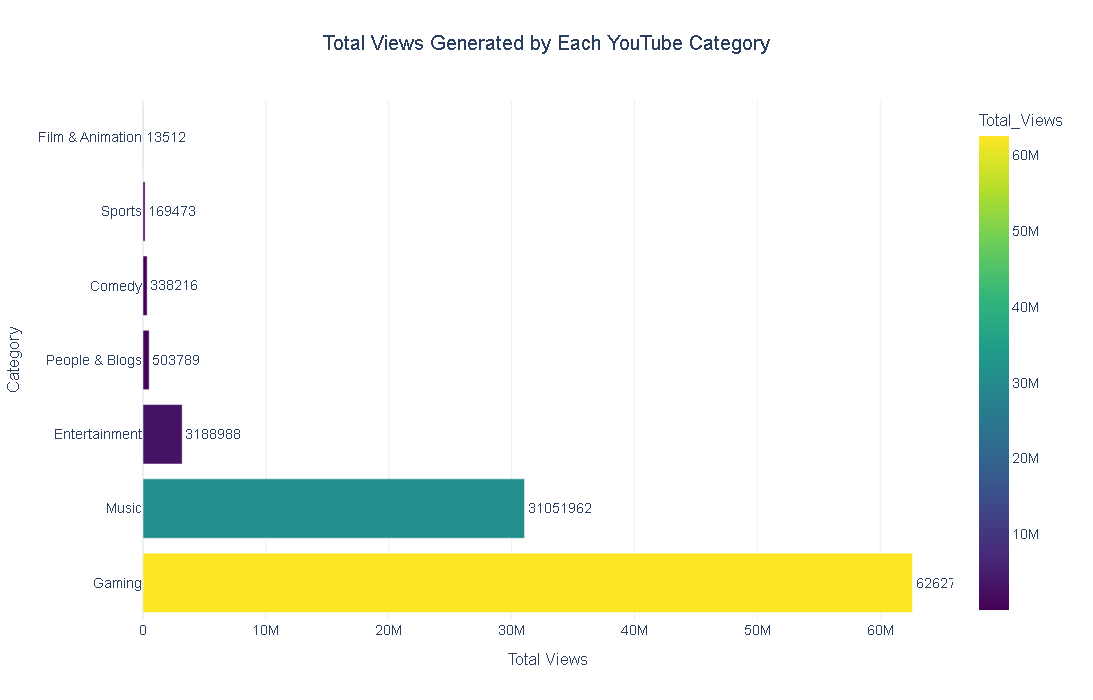

In [46]:
# ==========================================================
# Business Question:
# Which YouTube categories generate the highest total views?
# ==========================================================

# Group data by category and calculate business KPIs
category_views = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id", "count"),

        Total_Views=("view_count", "sum"),

        Average_Views=("view_count", "mean"),

        Total_Likes=("like_count", "sum"),

        Total_Comments=("comment_count", "sum"),

        Average_Engagement=("engagement_rate", "mean")

    )

    .sort_values(

        by="Total_Views",

        ascending=False

    )

)

# Calculate percentage contribution of each category
category_views["View_Share_%"] = (

    category_views["Total_Views"]

    /

    category_views["Total_Views"].sum()

    *100

).round(2)

# Running cumulative percentage (Pareto Analysis)
category_views["Cumulative_%"] = (

    category_views["View_Share_%"]

    .cumsum()

    .round(2)

)

# Category Ranking
category_views["Rank"] = (

    category_views["Total_Views"]

    .rank(

        method="dense",

        ascending=False

    )

    .astype(int)

)

# Display Final Report
display(category_views)

import plotly.express as px

fig = px.bar(

    category_views,

    x="Total_Views",

    y="category_name",

    orientation="h",

    color="Total_Views",

    text="Total_Views",

    hover_data=[

        "Rank",

        "Total_Videos",

        "Average_Views",

        "Average_Engagement",

        "View_Share_%"

    ],

    color_continuous_scale="Viridis",

    title="Total Views Generated by Each YouTube Category"

)

fig.update_traces(

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="Total Views",

    yaxis_title="Category",

    font=dict(

        family="Arial",

        size=14

    )

)

fig.show()

,category_name,Total_Videos,Average_Engagement,Median_Engagement,Maximum_Engagement,Average_Views,Average_Likes,Average_Comments,Rank
0,Comedy,1,0.0590,0.0590,0.059048,3.382160e+05,18851.000000,1120.000000,1
1,Entertainment,11,0.0455,0.0255,0.170046,2.899080e+05,8390.181818,951.090909,2
6,Sports,1,0.0453,0.0453,0.045317,1.694730e+05,7293.000000,387.000000,3
5,People & Blogs,4,0.0451,0.0430,0.087921,1.259472e+05,2065.250000,426.250000,4
4,Music,24,0.0440,0.0383,0.110227,1.293832e+06,75956.791667,6178.000000,5
3,Gaming,157,0.0413,0.0376,0.119010,3.988991e+05,13130.808917,819.547771,6
2,Film & Animation,1,0.0181,0.0181,0.018058,1.351200e+04,225.000000,19.000000,7


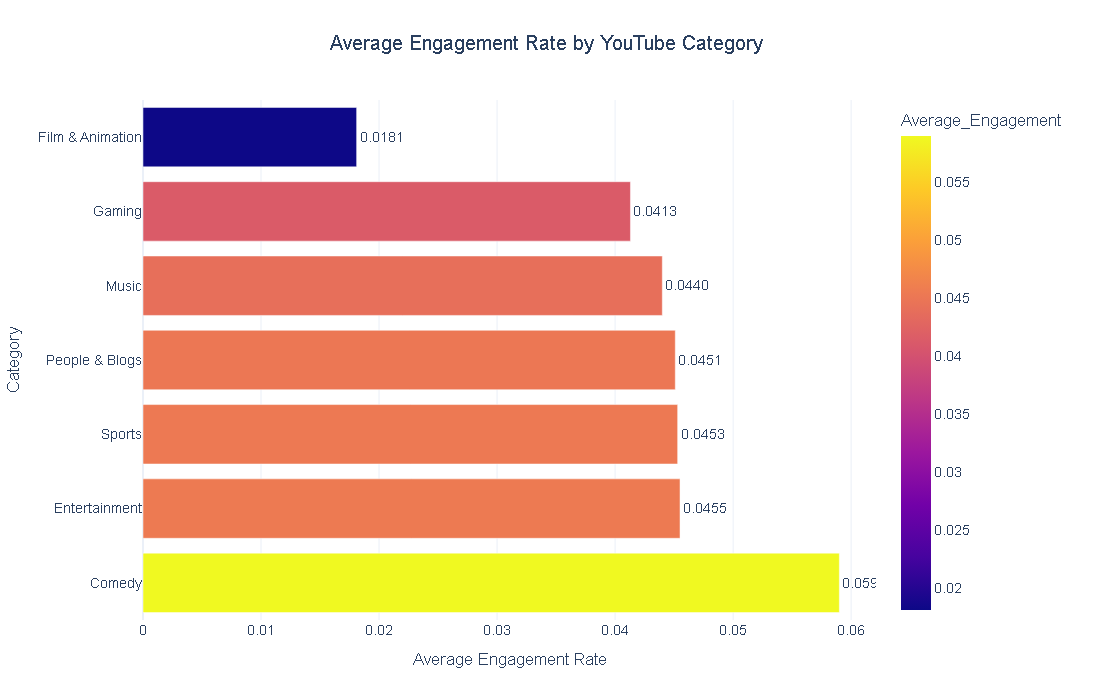

In [47]:
# ==========================================================
# Business Question:
# Which YouTube categories have the highest average engagement rate?
# ==========================================================

# Calculate category-wise engagement metrics

category_engagement = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id", "count"),

        Average_Engagement=("engagement_rate", "mean"),

        Median_Engagement=("engagement_rate", "median"),

        Maximum_Engagement=("engagement_rate", "max"),

        Average_Views=("view_count", "mean"),

        Average_Likes=("like_count", "mean"),

        Average_Comments=("comment_count", "mean")

    )

)

# Round values
category_engagement["Average_Engagement"] = (
    category_engagement["Average_Engagement"]
    .round(4)
)

category_engagement["Median_Engagement"] = (
    category_engagement["Median_Engagement"]
    .round(4)
)

# Rank categories
category_engagement["Rank"] = (

    category_engagement["Average_Engagement"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# Sort report
category_engagement = (

    category_engagement

    .sort_values(

        "Average_Engagement",

        ascending=False

    )

)

display(category_engagement)

import plotly.express as px

fig = px.bar(

    category_engagement,

    x="Average_Engagement",

    y="category_name",

    orientation="h",

    color="Average_Engagement",

    text="Average_Engagement",

    hover_data=[

        "Rank",

        "Total_Videos",

        "Average_Views",

        "Average_Likes",

        "Average_Comments"

    ],

    color_continuous_scale="Plasma",

    title="Average Engagement Rate by YouTube Category"

)

fig.update_traces(

    texttemplate="%{text:.4f}",

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="Average Engagement Rate",

    yaxis_title="Category",

    font=dict(

        family="Arial",

        size=14

    )

)

fig.show()

,category_name,Total_Videos,Average_Like_Rate,Median_Like_Rate,Maximum_Like_Rate,Average_Views,Average_Likes,Average_Comments,Rank,LikeRate_Share_%
0,Comedy,1,0.0557,0.0557,0.055737,3.382160e+05,18851.000000,1120.000000,1,20.55
6,Sports,1,0.0430,0.0430,0.043033,1.694730e+05,7293.000000,387.000000,2,15.87
4,Music,24,0.0415,0.0375,0.105578,1.293832e+06,75956.791667,6178.000000,3,15.31
1,Entertainment,11,0.0400,0.0206,0.154408,2.899080e+05,8390.181818,951.090909,4,14.76
3,Gaming,157,0.0377,0.0337,0.109415,3.988991e+05,13130.808917,819.547771,5,13.91
5,People & Blogs,4,0.0364,0.0310,0.077296,1.259472e+05,2065.250000,426.250000,6,13.43
2,Film & Animation,1,0.0167,0.0167,0.016652,1.351200e+04,225.000000,19.000000,7,6.16


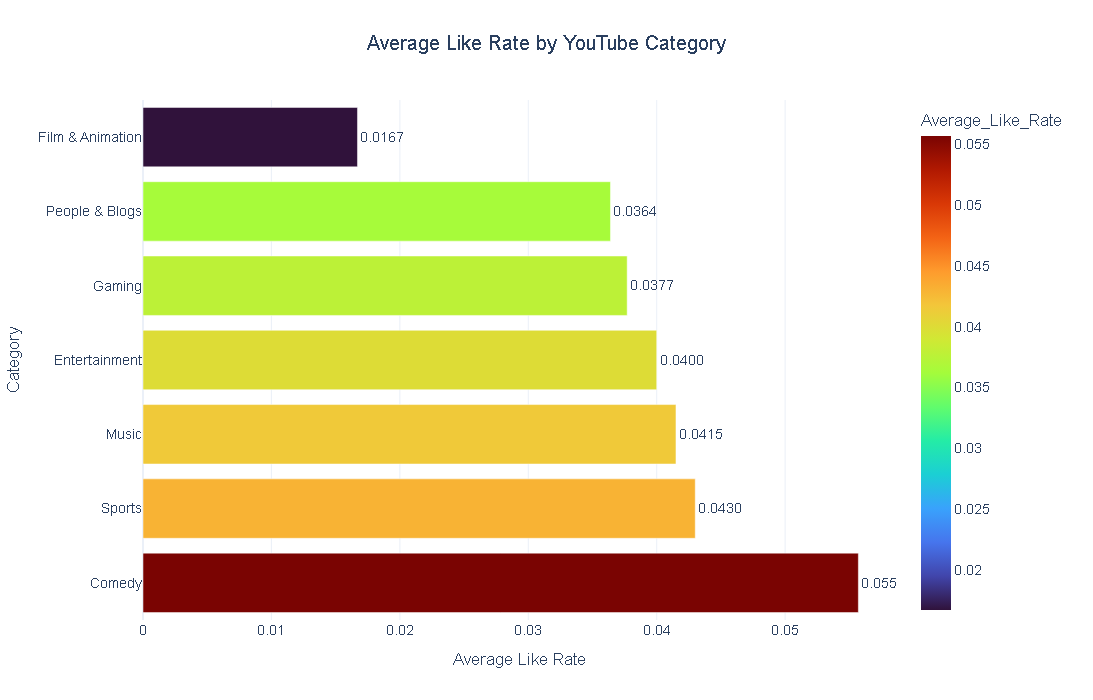

In [48]:
# ==========================================================
# Business Question:
# Which YouTube categories receive the highest average like rate?
# ==========================================================

# Calculate category-wise Like Rate KPIs

category_like = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id", "count"),

        Average_Like_Rate=("like_rate", "mean"),

        Median_Like_Rate=("like_rate", "median"),

        Maximum_Like_Rate=("like_rate", "max"),

        Average_Views=("view_count", "mean"),

        Average_Likes=("like_count", "mean"),

        Average_Comments=("comment_count", "mean")

    )

)

# Round numerical columns

category_like["Average_Like_Rate"] = (
    category_like["Average_Like_Rate"]
    .round(4)
)

category_like["Median_Like_Rate"] = (
    category_like["Median_Like_Rate"]
    .round(4)
)

# Rank categories

category_like["Rank"] = (

    category_like["Average_Like_Rate"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# Like Rate Contribution

category_like["LikeRate_Share_%"] = (

    category_like["Average_Like_Rate"]

    /

    category_like["Average_Like_Rate"].sum()

    *100

).round(2)

# Sort Report

category_like = (

    category_like

    .sort_values(

        "Average_Like_Rate",

        ascending=False

    )

)

display(category_like)

import plotly.express as px

fig = px.bar(

    category_like,

    x="Average_Like_Rate",

    y="category_name",

    orientation="h",

    color="Average_Like_Rate",

    text="Average_Like_Rate",

    hover_data=[

        "Rank",

        "Total_Videos",

        "Average_Views",

        "Average_Likes",

        "Average_Comments",

        "LikeRate_Share_%"

    ],

    color_continuous_scale="Turbo",

    title="Average Like Rate by YouTube Category"

)

fig.update_traces(

    texttemplate="%{text:.4f}",

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="Average Like Rate",

    yaxis_title="Category",

    font=dict(

        family="Arial",

        size=14

    )

)

fig.show()

In [49]:
# ==========================================================
# Business Question:
# Which YouTube categories receive the highest average comment rate?
# ==========================================================

# Calculate category-wise Comment Rate KPIs

category_comment = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Average_Comment_Rate=("comment_rate","mean"),

        Median_Comment_Rate=("comment_rate","median"),

        Maximum_Comment_Rate=("comment_rate","max"),

        Average_Views=("view_count","mean"),

        Average_Comments=("comment_count","mean"),

        Average_Engagement=("engagement_rate","mean")

    )

)

# Round values

category_comment["Average_Comment_Rate"] = (
    category_comment["Average_Comment_Rate"]
    .round(4)
)

category_comment["Median_Comment_Rate"] = (
    category_comment["Median_Comment_Rate"]
    .round(4)
)

# Ranking

category_comment["Rank"] = (

    category_comment["Average_Comment_Rate"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# Percentage Share

category_comment["CommentRate_Share_%"] = (

    category_comment["Average_Comment_Rate"]

    /

    category_comment["Average_Comment_Rate"].sum()

    *100

).round(2)

# Sort Final Report

category_comment = (

    category_comment

    .sort_values(

        "Average_Comment_Rate",

        ascending=False

    )

)

category_comment

,category_name,Total_Videos,Average_Comment_Rate,Median_Comment_Rate,Maximum_Comment_Rate,Average_Views,Average_Comments,Average_Engagement,Rank,CommentRate_Share_%
5,People & Blogs,4,0.0087,0.0056,0.023515,1.259472e+05,426.250000,0.045081,1,31.87
1,Entertainment,11,0.0055,0.0049,0.015638,2.899080e+05,951.090909,0.045450,2,20.15
3,Gaming,157,0.0036,0.0026,0.019090,3.988991e+05,819.547771,0.041309,3,13.19
0,Comedy,1,0.0033,0.0033,0.003311,3.382160e+05,1120.000000,0.059048,4,12.09
4,Music,24,0.0025,0.0015,0.006804,1.293832e+06,6178.000000,0.044021,5,9.16
6,Sports,1,0.0023,0.0023,0.002284,1.694730e+05,387.000000,0.045317,6,8.42
2,Film & Animation,1,0.0014,0.0014,0.001406,1.351200e+04,19.000000,0.018058,7,5.13


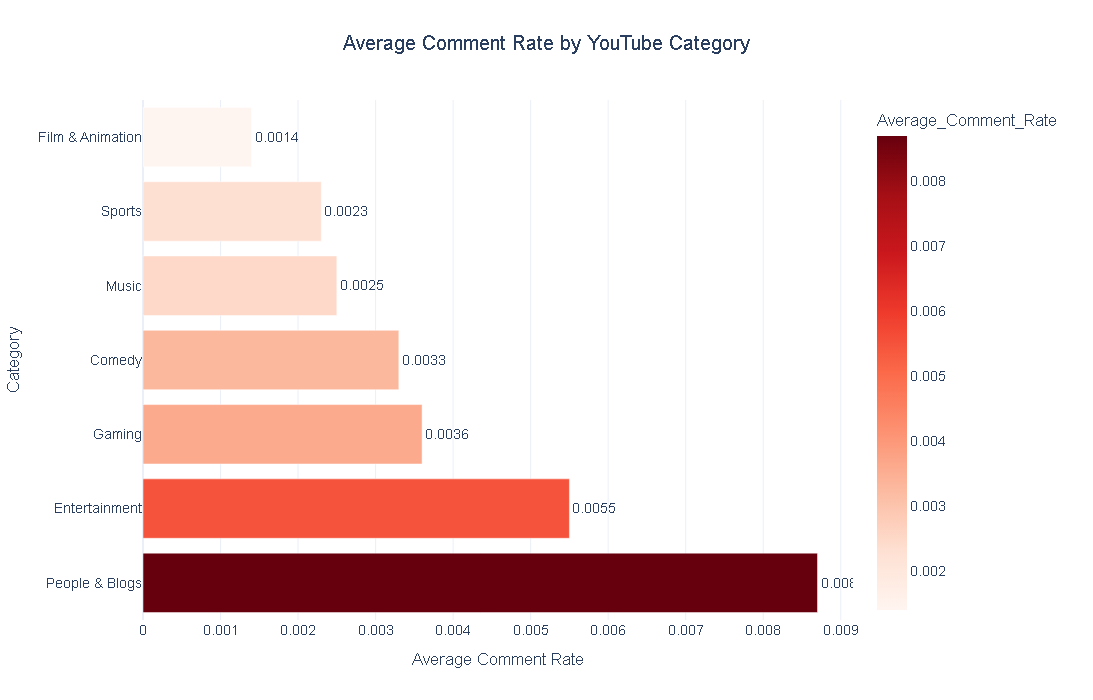

In [50]:
import plotly.express as px

fig = px.bar(

    category_comment,

    x="Average_Comment_Rate",

    y="category_name",

    orientation="h",

    color="Average_Comment_Rate",

    text="Average_Comment_Rate",

    hover_data=[

        "Rank",

        "Total_Videos",

        "Average_Views",

        "Average_Comments",

        "Average_Engagement",

        "CommentRate_Share_%"

    ],

    color_continuous_scale="Reds",

    title="Average Comment Rate by YouTube Category"

)

fig.update_traces(

    texttemplate="%{text:.4f}",

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=700,

    xaxis_title="Average Comment Rate",

    yaxis_title="Category",

    font=dict(

        family="Arial",

        size=14

    )

)

fig.show()

In [51]:
# ==========================================================
# Business Question:
# Which YouTube categories contribute the highest share of total views?
# ==========================================================

category_share = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum"),

        Avg_Views=("view_count","mean"),

        Avg_Engagement=("engagement_rate","mean")

    )

)

# Calculate View Share Percentage

category_share["View_Share_%"] = (

    category_share["Total_Views"]

    /

    category_share["Total_Views"].sum()

    *100

).round(2)

# Cumulative Percentage (Pareto Analysis)

category_share["Cumulative_%"] = (

    category_share["View_Share_%"]

    .cumsum()

    .round(2)

)

# Rank Categories

category_share["Rank"] = (

    category_share["Total_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# Sort Report

category_share = (

    category_share

    .sort_values(

        "Total_Views",

        ascending=False

    )

)

category_share

,category_name,Total_Videos,Total_Views,Total_Likes,Total_Comments,Avg_Views,Avg_Engagement,View_Share_%,Cumulative_%,Rank
3,Gaming,157,62627153,2061537,128669,3.988991e+05,0.041309,63.98,67.60,1
4,Music,24,31051962,1822963,148272,1.293832e+06,0.044021,31.72,99.32,2
1,Entertainment,11,3188988,92292,10462,2.899080e+05,0.045450,3.26,3.61,3
5,People & Blogs,4,503789,8261,1705,1.259472e+05,0.045081,0.51,99.83,4
0,Comedy,1,338216,18851,1120,3.382160e+05,0.059048,0.35,0.35,5
6,Sports,1,169473,7293,387,1.694730e+05,0.045317,0.17,100.00,6
2,Film & Animation,1,13512,225,19,1.351200e+04,0.018058,0.01,3.62,7


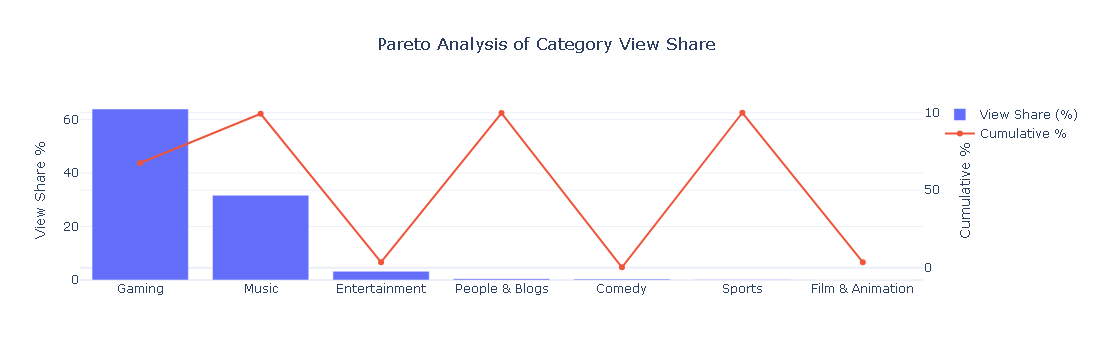

In [52]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(

    go.Bar(

        x=category_share["category_name"],

        y=category_share["View_Share_%"],

        name="View Share (%)"

    )

)

fig.add_trace(

    go.Scatter(

        x=category_share["category_name"],

        y=category_share["Cumulative_%"],

        mode="lines+markers",

        name="Cumulative %",

        yaxis="y2"

    )

)

fig.update_layout(

    template="plotly_white",

    title="Pareto Analysis of Category View Share",

    title_x=.5,

    yaxis=dict(title="View Share %"),

    yaxis2=dict(

        title="Cumulative %",

        overlaying="y",

        side="right"

    )

)

fig.show()

In [53]:
# ==========================================================
# Business Question:
# Which categories upload the largest number of trending videos?
# ==========================================================

category_frequency = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Trending_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum")

    )

)

# Market Share (%)

category_frequency["Trending_Share_%"]=(

    category_frequency["Trending_Videos"]

    /

    category_frequency["Trending_Videos"].sum()

    *100

).round(2)

# Cumulative %

category_frequency["Cumulative_%"]=(

    category_frequency["Trending_Share_%"]

    .cumsum()

    .round(2)

)

# Ranking

category_frequency["Rank"]=(

    category_frequency["Trending_Videos"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# Sort

category_frequency=(

    category_frequency

    .sort_values(

        "Trending_Videos",

        ascending=False

    )

)

category_frequency

,category_name,Trending_Videos,Total_Views,Average_Views,Average_Engagement,Total_Likes,Total_Comments,Trending_Share_%,Cumulative_%,Rank
3,Gaming,157,62627153,3.988991e+05,0.041309,2061537,128669,78.89,85.42,1
4,Music,24,31051962,1.293832e+06,0.044021,1822963,148272,12.06,97.48,2
1,Entertainment,11,3188988,2.899080e+05,0.045450,92292,10462,5.53,6.03,3
5,People & Blogs,4,503789,1.259472e+05,0.045081,8261,1705,2.01,99.49,4
0,Comedy,1,338216,3.382160e+05,0.059048,18851,1120,0.50,0.50,5
2,Film & Animation,1,13512,1.351200e+04,0.018058,225,19,0.50,6.53,5
6,Sports,1,169473,1.694730e+05,0.045317,7293,387,0.50,99.99,5


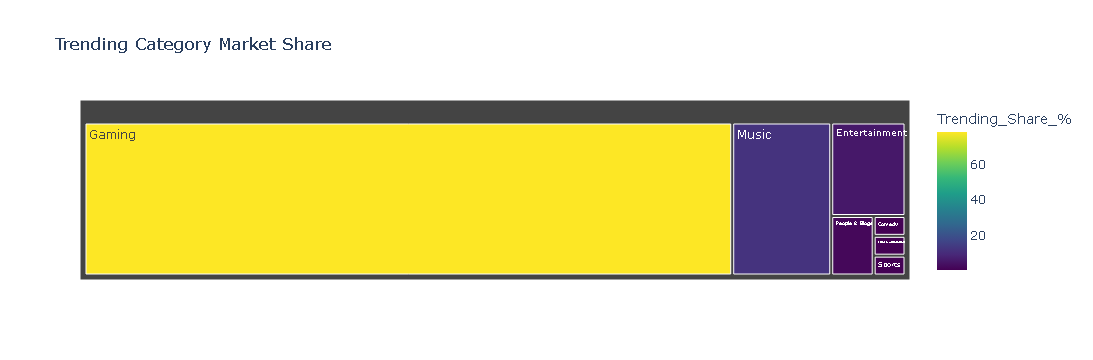

In [54]:
fig=px.treemap(

category_frequency,

path=["category_name"],

values="Trending_Videos",

color="Trending_Share_%",

hover_data=[

"Average_Views",

"Average_Engagement"

],

color_continuous_scale="Viridis",

title="Trending Category Market Share"

)

fig.show()

In [55]:
# ==========================================================
# Business Question:
# Which categories have the highest average video duration?
# ==========================================================

duration_report = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Avg_Duration_Min=("duration_seconds",
                          lambda x: x.mean()/60),

        Median_Duration_Min=("duration_seconds",
                             lambda x: x.median()/60),

        Min_Duration_Min=("duration_seconds",
                          lambda x: x.min()/60),

        Max_Duration_Min=("duration_seconds",
                          lambda x: x.max()/60),

        Std_Duration=("duration_seconds","std"),

        Avg_Views=("view_count","mean"),

        Avg_Engagement=("engagement_rate","mean")

    )

)

duration_report = duration_report.round(2)

duration_report["Duration_Share_%"]=(

duration_report["Avg_Duration_Min"]

/

duration_report["Avg_Duration_Min"].sum()

*100

).round(2)

duration_report["Rank"]=(

duration_report["Avg_Duration_Min"]

.rank(

ascending=False,

method="dense"

)

.astype(int)

)

duration_report = duration_report.sort_values(

"Avg_Duration_Min",

ascending=True

)

duration_report

,category_name,Total_Videos,Avg_Duration_Min,Median_Duration_Min,Min_Duration_Min,Max_Duration_Min,Std_Duration,Avg_Views,Avg_Engagement,Duration_Share_%,Rank
2,Film & Animation,1,2.60,2.60,2.60,2.60,NaN,13512.00,0.02,0.74,7
0,Comedy,1,2.77,2.77,2.77,2.77,NaN,338216.00,0.06,0.79,6
4,Music,24,10.89,3.21,1.97,181.77,2184.83,1293831.75,0.04,3.09,5
6,Sports,1,33.10,33.10,33.10,33.10,NaN,169473.00,0.05,9.40,4
5,People & Blogs,4,56.79,63.21,3.72,97.02,2528.73,125947.25,0.05,16.13,3
3,Gaming,157,109.83,42.68,1.45,707.05,8395.80,398899.06,0.04,31.19,2
1,Entertainment,11,136.14,29.57,6.38,715.00,14070.52,289908.00,0.05,38.66,1


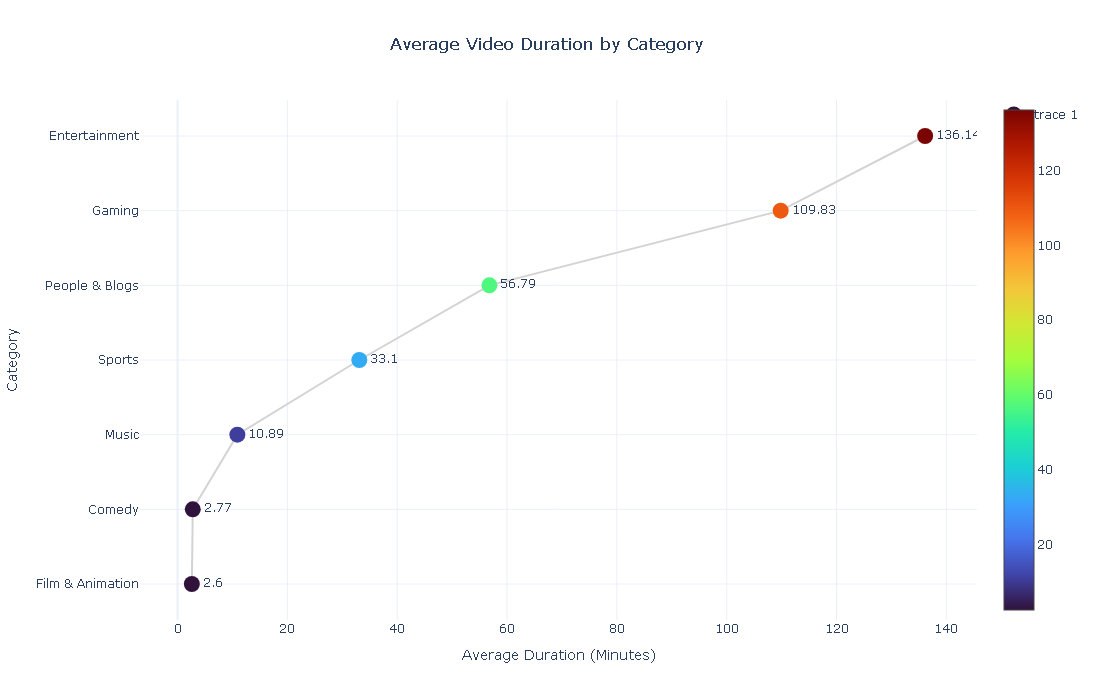

In [56]:
import plotly.graph_objects as go

fig = go.Figure()

# Lollipop Line

fig.add_trace(

    go.Scatter(

        x=duration_report["Avg_Duration_Min"],

        y=duration_report["category_name"],

        mode="lines",

        line=dict(color="lightgray", width=2),

        showlegend=False

    )

)

# Lollipop Dot

fig.add_trace(

    go.Scatter(

        x=duration_report["Avg_Duration_Min"],

        y=duration_report["category_name"],

        mode="markers+text",

        marker=dict(

            size=16,

            color=duration_report["Avg_Duration_Min"],

            colorscale="Turbo",

            showscale=True

        ),

        text=duration_report["Avg_Duration_Min"],

        textposition="middle right",

        hovertemplate=

        "<b>%{y}</b><br>" +

        "Avg Duration: %{x:.2f} min<extra></extra>"

    )

)

fig.update_layout(

    template="plotly_white",

    title="Average Video Duration by Category",

    title_x=0.5,

    height=700,

    xaxis_title="Average Duration (Minutes)",

    yaxis_title="Category"

)

fig.show()

In [57]:
# ==========================================================
# Business Question:
# Which YouTube categories produce the longest video titles?
# ==========================================================

title_analysis = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Avg_Title_Length=("title_length","mean"),

        Median_Title_Length=("title_length","median"),

        Avg_Title_Words=("title_word_count","mean"),

        Max_Title_Length=("title_length","max"),

        Min_Title_Length=("title_length","min"),

        Std_Title_Length=("title_length","std"),

        Avg_Views=("view_count","mean"),

        Avg_Engagement=("engagement_rate","mean")

    )

)

title_analysis = title_analysis.round(2)

title_analysis["Rank"]=(

title_analysis["Avg_Title_Length"]

.rank(

ascending=False,

method="dense"

)

.astype(int)

)

title_analysis = (

title_analysis

.sort_values(

"Avg_Title_Length",

ascending=True

)

)

title_analysis

,category_name,Total_Videos,Avg_Title_Length,Median_Title_Length,Avg_Title_Words,Max_Title_Length,Min_Title_Length,Std_Title_Length,Avg_Views,Avg_Engagement,Rank
0,Comedy,1,33.00,33.0,4.00,33,33,NaN,338216.00,0.06,7
2,Film & Animation,1,37.00,37.0,7.00,37,37,NaN,13512.00,0.02,6
1,Entertainment,11,43.09,36.0,7.36,97,10,28.01,289908.00,0.05,5
3,Gaming,157,44.55,42.0,7.97,100,12,16.87,398899.06,0.04,4
4,Music,24,45.04,42.5,7.79,99,3,25.15,1293831.75,0.04,3
6,Sports,1,48.00,48.0,10.00,48,48,NaN,169473.00,0.05,2
5,People & Blogs,4,53.25,46.0,10.25,91,30,28.04,125947.25,0.05,1


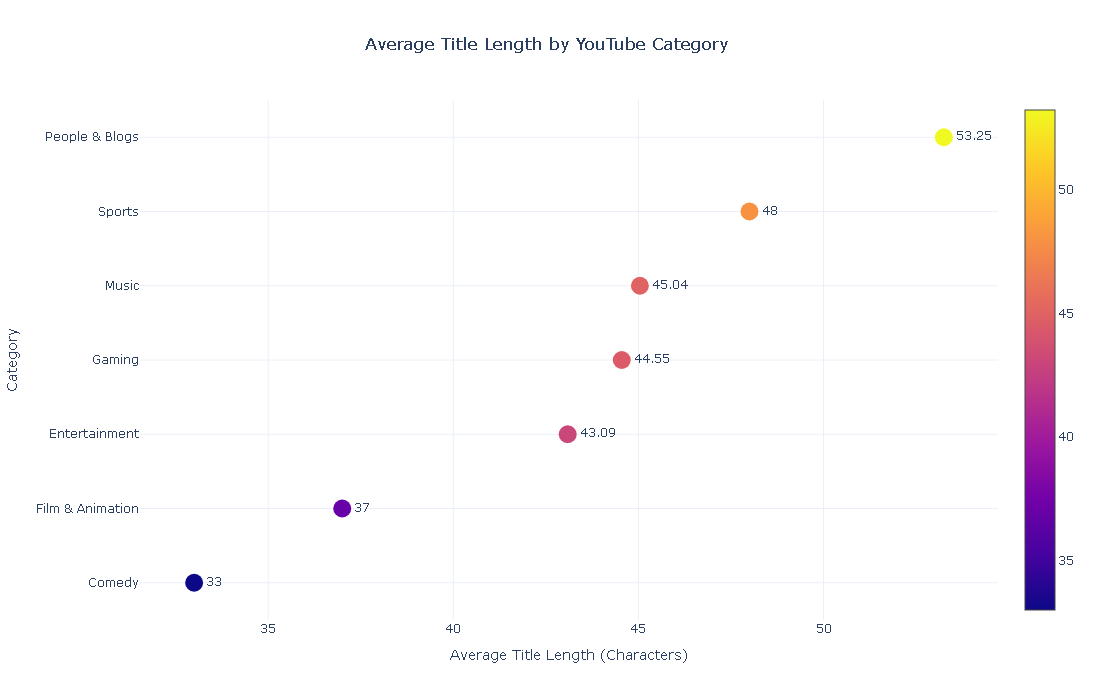

In [58]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(

    go.Scatter(

        x=title_analysis["Avg_Title_Length"],

        y=title_analysis["category_name"],

        mode="markers+text",

        marker=dict(

            size=18,

            color=title_analysis["Avg_Title_Length"],

            colorscale="Plasma",

            showscale=True

        ),

        text=title_analysis["Avg_Title_Length"],

        textposition="middle right",

        hovertemplate=

        "<b>%{y}</b><br>"+

        "Average Title Length: %{x:.1f} Characters<extra></extra>"

    )

)

fig.update_layout(

    template="plotly_white",

    title="Average Title Length by YouTube Category",

    title_x=.5,

    height=700,

    xaxis_title="Average Title Length (Characters)",

    yaxis_title="Category"

)

fig.show()

In [59]:
# ==========================================================
# Business Question:
# Which YouTube channels generate the highest total views?
# ==========================================================

channel_views = (

    df

    .groupby("channel_title", as_index=False)

    .agg(

        Trending_Videos=("video_id", "count"),

        Total_Views=("view_count", "sum"),

        Average_Views=("view_count", "mean"),

        Total_Likes=("like_count", "sum"),

        Total_Comments=("comment_count", "sum"),

        Average_Engagement=("engagement_rate", "mean"),

        Average_Like_Rate=("like_rate", "mean"),

        Average_Comment_Rate=("comment_rate", "mean")

    )

)

# Round KPI Columns

channel_views = channel_views.round({

    "Average_Views":0,

    "Average_Engagement":2,

    "Average_Like_Rate":2,

    "Average_Comment_Rate":2

})

# View Share %

channel_views["View_Share_%"] = (

    channel_views["Total_Views"]

    /

    channel_views["Total_Views"].sum()

    *100

).round(2)

# Rank Channels

channel_views["Rank"] = (

    channel_views["Total_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

# Top 20 Channels

top20_channels = (

    channel_views

    .sort_values(

        "Total_Views",

        ascending=False

    )

    .head(20)

)

top20_channels

,channel_title,Trending_Videos,Total_Views,Average_Views,Total_Likes,Total_Comments,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,View_Share_%,Rank
114,MrBeast Gaming,1,23654668,23654668.0,712711,18971,0.03,0.03,0.00,24.16,1
5,ArianaGrandeVevo,1,9356390,9356390.0,630087,58086,0.07,0.07,0.01,9.56,2
11,BABYMONSTER,1,6170913,6170913.0,499751,41985,0.09,0.08,0.01,6.30,3
83,KATSEYE,1,3794321,3794321.0,207682,20211,0.06,0.05,0.01,3.88,4
187,bennyblancoVEVO,1,3075542,3075542.0,151809,6912,0.05,0.05,0.00,3.14,5
140,SMii7Y,1,2624779,2624779.0,109983,4186,0.04,0.04,0.00,2.68,6
160,The Living Tombstone,1,1736525,1736525.0,127940,9129,0.08,0.07,0.01,1.77,7
29,Clash Royale,1,1668880,1668880.0,46492,962,0.03,0.03,0.00,1.70,8
138,Rubius Z,1,1516717,1516717.0,68462,2358,0.05,0.05,0.00,1.55,9
6,Asmongold TV,1,1187180,1187180.0,58190,9238,0.06,0.05,0.01,1.21,10


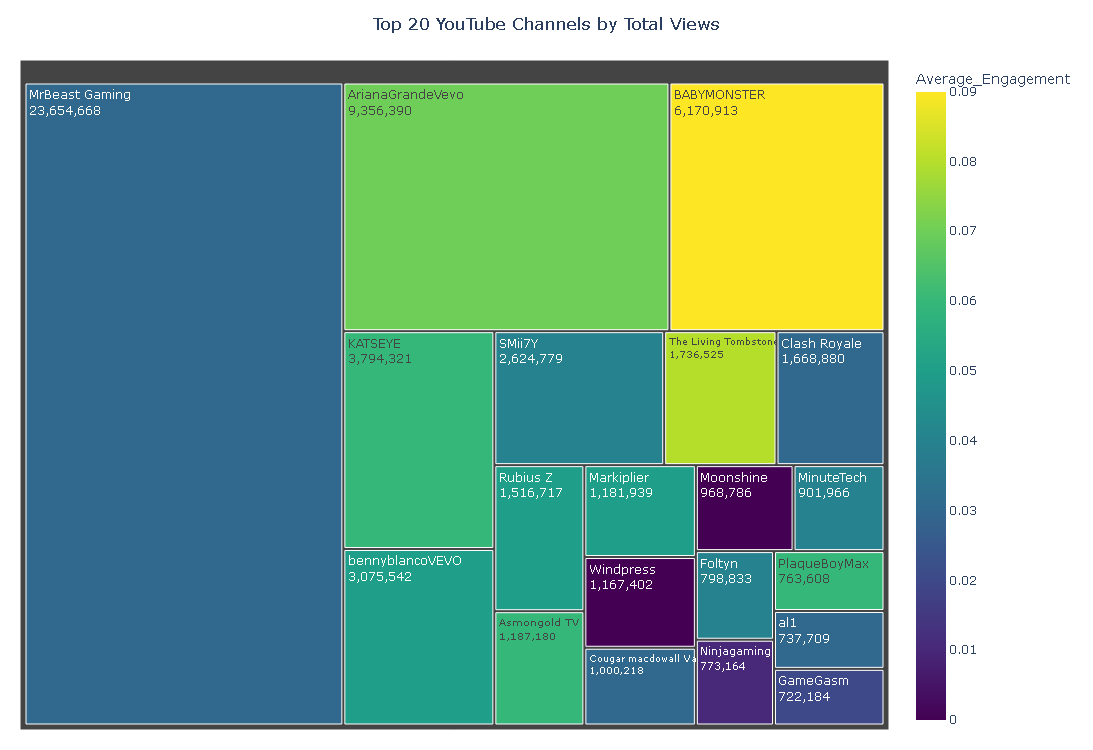

In [60]:
import plotly.express as px

fig = px.treemap(

    top20_channels,

    path=["channel_title"],

    values="Total_Views",

    color="Average_Engagement",

    color_continuous_scale="Viridis",

    hover_data={

        "Trending_Videos":True,

        "Average_Views":":,.0f",

        "Average_Engagement":":.2f",

        "Average_Like_Rate":":.2f",

        "Average_Comment_Rate":":.2f",

        "View_Share_%":":.2f"

    },

    title="Top 20 YouTube Channels by Total Views"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=750,

    margin=dict(t=60, l=20, r=20, b=20)

)

fig.update_traces(

    textinfo="label+value"

)

fig.show()

In [61]:
# ==========================================================
# Business Question:
# Which channels have the highest engagement performance?
# ==========================================================

channel_engagement = (

    df

    .groupby("channel_title", as_index=False)

    .agg(

        Trending_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Total_Engagement=("engagement_score","sum"),

        Avg_Engagement_Rate=("engagement_rate","mean"),

        Avg_Like_Rate=("like_rate","mean"),

        Avg_Comment_Rate=("comment_rate","mean"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum")

    )

)

# View Share
channel_engagement["View_Share_%"]=(

channel_engagement["Total_Views"]

/

channel_engagement["Total_Views"].sum()

*100

)

# Rank

channel_engagement["Rank"]=(

channel_engagement["Total_Engagement"]

.rank(

ascending=False,

method="dense"

)

.astype(int)

)

# Top 20

top20_engagement=(

channel_engagement

.sort_values(

"Total_Engagement",

ascending=False

)

.head(20)

)

top20_engagement.round(2)

,channel_title,Trending_Videos,Total_Views,Total_Engagement,Avg_Engagement_Rate,Avg_Like_Rate,Avg_Comment_Rate,Total_Likes,Total_Comments,View_Share_%,Rank
114,MrBeast Gaming,1,23654668,731682,0.03,0.03,0.00,712711,18971,24.16,1
5,ArianaGrandeVevo,1,9356390,688173,0.07,0.07,0.01,630087,58086,9.56,2
11,BABYMONSTER,1,6170913,541736,0.09,0.08,0.01,499751,41985,6.30,3
83,KATSEYE,1,3794321,227893,0.06,0.05,0.01,207682,20211,3.88,4
187,bennyblancoVEVO,1,3075542,158721,0.05,0.05,0.00,151809,6912,3.14,5
160,The Living Tombstone,1,1736525,137069,0.08,0.07,0.01,127940,9129,1.77,6
140,SMii7Y,1,2624779,114169,0.04,0.04,0.00,109983,4186,2.68,7
138,Rubius Z,1,1516717,70820,0.05,0.05,0.00,68462,2358,1.55,8
6,Asmongold TV,1,1187180,67428,0.06,0.05,0.01,58190,9238,1.21,9
105,Markiplier,1,1181939,58174,0.05,0.05,0.00,57390,784,1.21,10


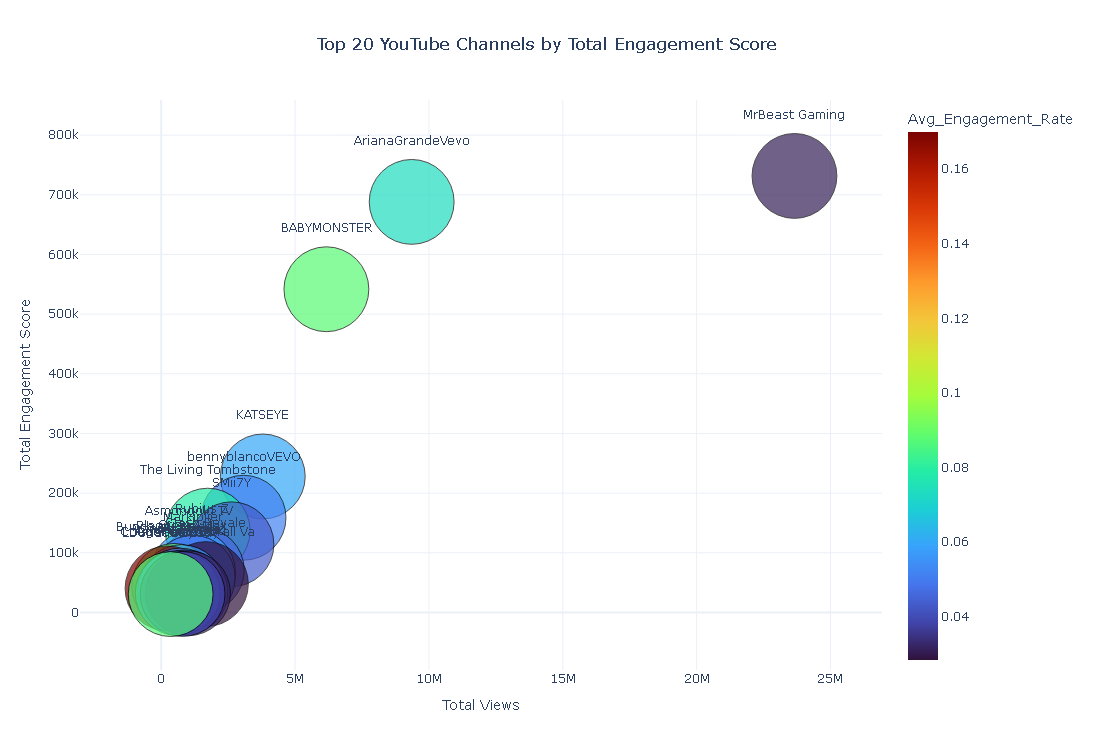

In [62]:
import plotly.express as px

fig = px.scatter(

    top20_engagement,

    x="Total_Views",

    y="Total_Engagement",

    size="Trending_Videos",

    color="Avg_Engagement_Rate",

    hover_name="channel_title",

    text="channel_title",

    size_max=60,

    color_continuous_scale="Turbo",

    title="Top 20 YouTube Channels by Total Engagement Score"

)

fig.update_traces(

    textposition="top center",

    marker=dict(

        line=dict(

            color="black",

            width=1

        )

    )

)

fig.update_layout(

    template="plotly_white",

    height=750,

    title_x=0.5,

    xaxis_title="Total Views",

    yaxis_title="Total Engagement Score",

    legend_title="Engagement"

)

fig.show()

In [63]:
# ==========================================================
# Business Question:
# Which YouTube channels contribute the largest share
# of total platform views among trending videos?
# ==========================================================

channel_summary = (

    df

    .groupby("channel_title", as_index=False)

    .agg(

        Trending_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum"),

        Avg_Views=("view_count","mean"),

        Avg_Engagement=("engagement_rate","mean")

    )

)

# View Share %

channel_summary["View_Share_%"]=(

channel_summary["Total_Views"]

/

channel_summary["Total_Views"].sum()

*100

)

# Cumulative %

channel_summary["Cumulative_View_%"]=(

channel_summary

.sort_values("Total_Views",ascending=False)

["View_Share_%"]

.cumsum()

)

# Rank

channel_summary["Rank"]=(

channel_summary["Total_Views"]

.rank(

ascending=False,

method="dense"

)

.astype(int)

)

# Top 20

top20_channels=(

channel_summary

.sort_values(

"Total_Views",

ascending=False

)

.head(20)

)

top20_channels

,channel_title,Trending_Videos,Total_Views,Total_Likes,Total_Comments,Avg_Views,Avg_Engagement,View_Share_%,Cumulative_View_%,Rank
114,MrBeast Gaming,1,23654668,712711,18971,23654668.0,0.030932,24.163776,24.163776,1
5,ArianaGrandeVevo,1,9356390,630087,58086,9356390.0,0.073551,9.557763,33.721539,2
11,BABYMONSTER,1,6170913,499751,41985,6170913.0,0.087789,6.303727,40.025266,3
83,KATSEYE,1,3794321,207682,20211,3794321.0,0.060062,3.875984,43.901251,4
187,bennyblancoVEVO,1,3075542,151809,6912,3075542.0,0.051607,3.141735,47.042986,5
140,SMii7Y,1,2624779,109983,4186,2624779.0,0.043497,2.681271,49.724257,6
160,The Living Tombstone,1,1736525,127940,9129,1736525.0,0.078933,1.773899,51.498156,7
29,Clash Royale,1,1668880,46492,962,1668880.0,0.028435,1.704799,53.202955,8
138,Rubius Z,1,1516717,68462,2358,1516717.0,0.046693,1.549361,54.752315,9
6,Asmongold TV,1,1187180,58190,9238,1187180.0,0.056797,1.212731,55.965046,10


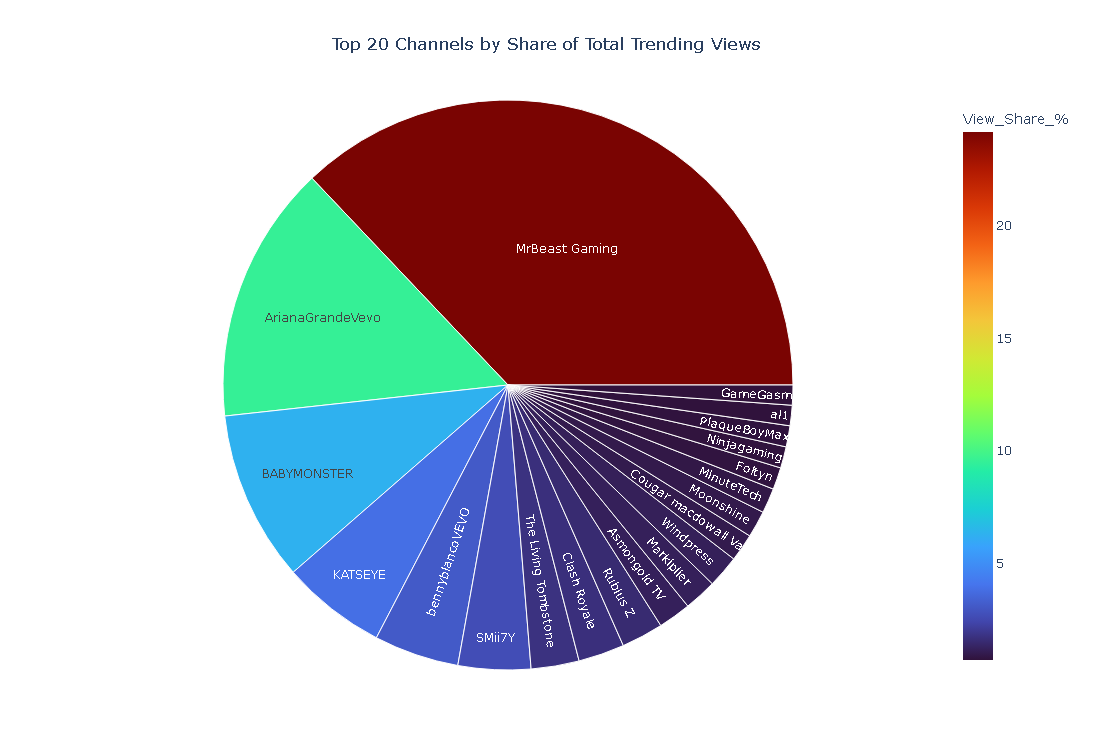

In [64]:
import plotly.express as px

fig = px.sunburst(

    top20_channels,

    path=["channel_title"],

    values="Total_Views",

    color="View_Share_%",

    color_continuous_scale="Turbo",

    hover_data={

        "Trending_Videos":True,

        "Total_Likes":":,",

        "Total_Comments":":,",

        "View_Share_%":":.2f"

    },

    title="Top 20 Channels by Share of Total Trending Views"

)

fig.update_layout(

    template="plotly_white",

    height=750,

    title_x=0.5

)

fig.show()

In [65]:
# ==========================================================
# Business Question:
# Which upload hour generates the highest average views?
# ==========================================================

hourly_views = (

    df

    .groupby("publish_hour", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

# Round Values

hourly_views = hourly_views.round({

    "Average_Views":0,

    "Median_Views":0,

    "Average_Engagement":2,

    "Average_Like_Rate":2,

    "Average_Comment_Rate":2

})

# Rank

hourly_views["Rank"]=(

hourly_views["Average_Views"]

.rank(

ascending=False,

method="dense"

)

.astype(int)

)

hourly_views = (

hourly_views

.sort_values(

"publish_hour"

)

)

hourly_views

,publish_hour,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Rank
0,0,11,3362575,305689.0,252255.0,0.04,0.04,0.01,10
1,1,12,1517610,126468.0,86812.0,0.06,0.05,0.01,21
2,2,7,1858622,265517.0,248344.0,0.03,0.03,0.00,12
3,3,4,1163735,290934.0,193648.0,0.04,0.04,0.00,11
4,4,8,5222758,652845.0,331430.0,0.03,0.03,0.00,3
5,5,6,1220382,203397.0,144252.0,0.03,0.03,0.00,16
6,6,4,885499,221375.0,127691.0,0.04,0.03,0.00,13
7,7,4,446553,111638.0,90694.0,0.03,0.03,0.00,22
8,8,6,1269042,211507.0,132566.0,0.02,0.02,0.00,15
9,9,5,974993,194999.0,36419.0,0.02,0.02,0.00,17


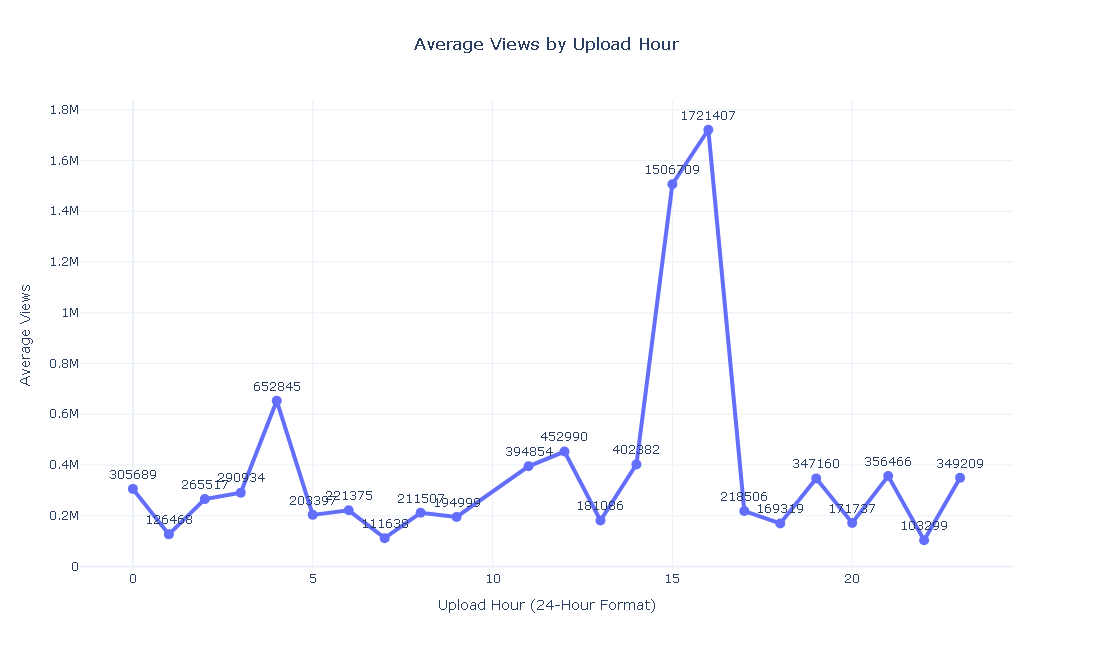

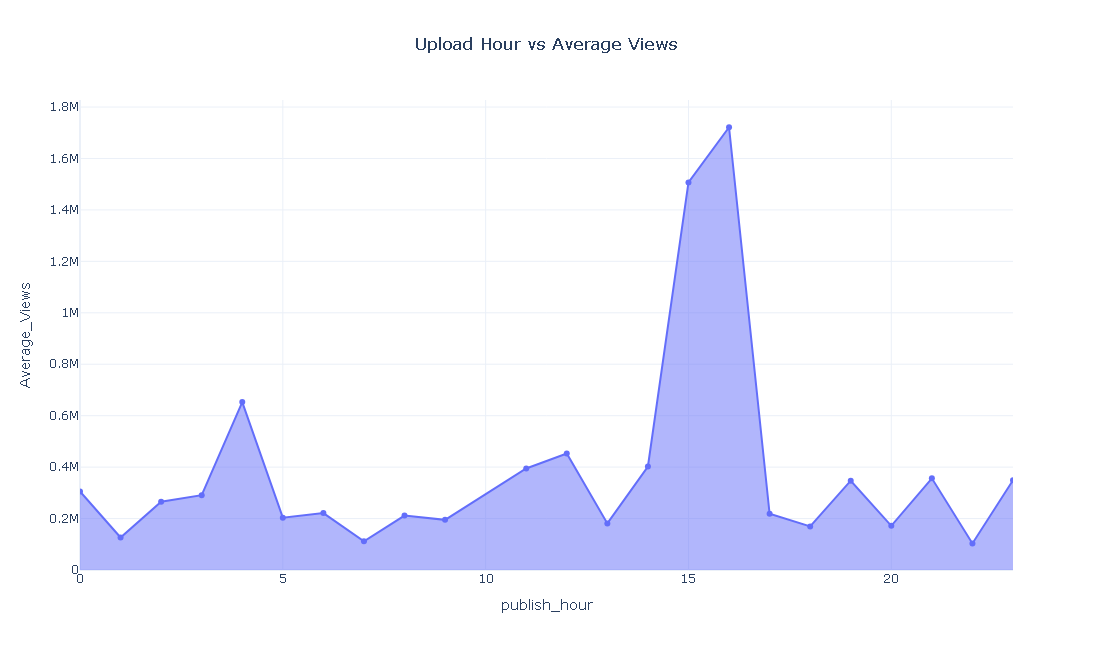

In [66]:
import plotly.express as px

fig = px.line(

    hourly_views,

    x="publish_hour",

    y="Average_Views",

    markers=True,

    text="Average_Views",

    title="Average Views by Upload Hour"

)

fig.update_traces(

    line=dict(width=4),

    marker=dict(size=10),

    textposition="top center"

)

fig.update_layout(

    template="plotly_white",

    height=650,

    title_x=0.5,

    xaxis_title="Upload Hour (24-Hour Format)",

    yaxis_title="Average Views"

)

fig.show()

fig = px.area(

    hourly_views,

    x="publish_hour",

    y="Average_Views",

    markers=True,

    title="Upload Hour vs Average Views"

)

fig.update_layout(

    template="plotly_white",

    height=650,

    title_x=.5

)

fig.show()

In [67]:
# ==========================================================
# Business Question:
# Which upload session performs best?
# ==========================================================

session_report = (

    df

    .groupby("publish_session", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum")

    )

)

session_report = session_report.round({

    "Average_Views":0,

    "Median_Views":0,

    "Average_Engagement":2,

    "Average_Like_Rate":2,

    "Average_Comment_Rate":2

})

session_report["Rank"]=(

session_report["Average_Views"]

.rank(

ascending=False,

method="dense"

)

.astype(int)

)

session_report = session_report.sort_values(

"Rank"

)

session_report

,publish_session,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Total_Likes,Total_Comments,Rank
0,Afternoon,69,60900254,882612.0,158649.0,0.04,0.04,0.0,2758054,193731,1
3,Night,52,15231181,292907.0,138200.0,0.04,0.04,0.0,525449,38528,2
1,Evening,55,15679693,285085.0,121728.0,0.05,0.04,0.0,551022,39119,3
2,Morning,23,6081965,264433.0,170404.0,0.03,0.03,0.0,176897,19256,4


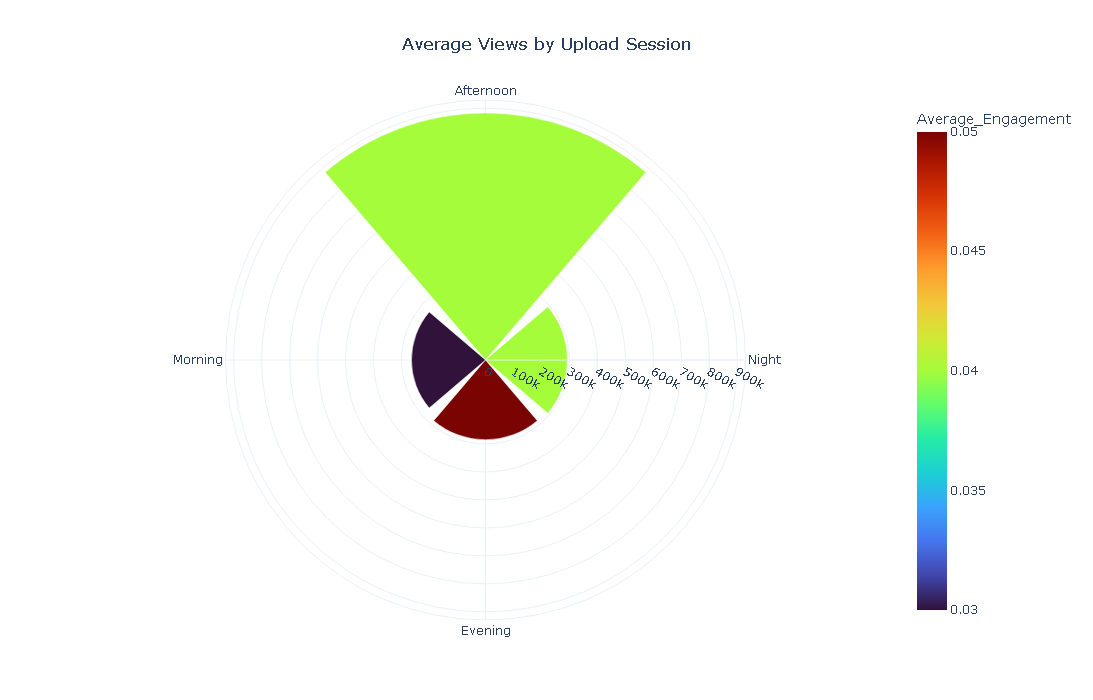

In [68]:
import plotly.express as px

fig = px.bar_polar(

    session_report,

    r="Average_Views",

    theta="publish_session",

    color="Average_Engagement",

    color_continuous_scale="Turbo",

    hover_data=[

        "Total_Videos",

        "Average_Like_Rate",

        "Average_Comment_Rate"

    ],

    title="Average Views by Upload Session"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=700

)

fig.show()

In [69]:
# ==========================================================
# Business Question:
# Which day of the week generates the highest audience engagement?
# ==========================================================

day_order = [

    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"

]

weekday_report = (

    df

    .groupby("publish_day_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

weekday_report["publish_day_name"] = pd.Categorical(

    weekday_report["publish_day_name"],

    categories=day_order,

    ordered=True

)

weekday_report = (

    weekday_report

    .sort_values("publish_day_name")

)

weekday_report = weekday_report.round(2)

weekday_report["Rank"] = (

    weekday_report["Average_Engagement"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

weekday_report

,publish_day_name,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Rank
1,Monday,49,8487539,173215.08,0.03,0.03,0.0,3
4,Tuesday,1,33799,33799.00,0.01,0.01,0.0,4
5,Wednesday,1,55223,55223.00,0.00,0.00,0.0,5
0,Friday,12,24540531,2045044.25,0.04,0.04,0.0,2
2,Saturday,23,35726759,1553337.35,0.04,0.03,0.0,2
3,Sunday,113,29049242,257072.94,0.05,0.04,0.0,1


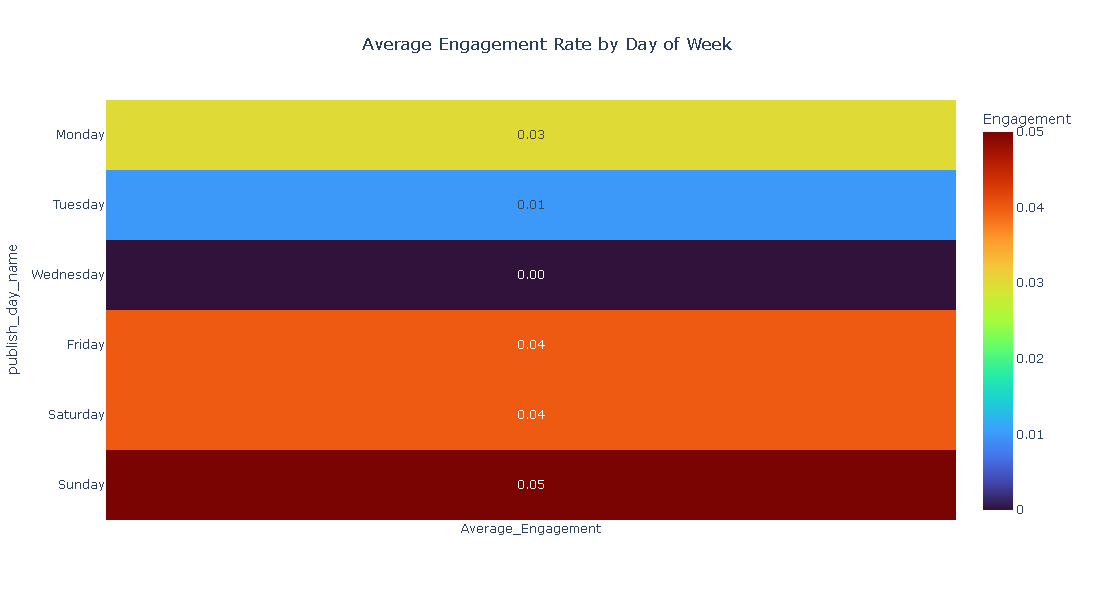

In [70]:
import plotly.express as px

heatmap_df = weekday_report.pivot_table(

    index="publish_day_name",

    values="Average_Engagement"

)

fig = px.imshow(

    heatmap_df,

    text_auto=".2f",

    color_continuous_scale="Turbo",

    aspect="auto",

    title="Average Engagement Rate by Day of Week"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=600,

    coloraxis_colorbar_title="Engagement"

)

fig.show()

In [71]:
# ==========================================================
# Business Question:
# Which month produces the highest average views?
# ==========================================================

month_order = [

    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"

]

monthly_report = (

    df

    .groupby("publish_month_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

monthly_report["publish_month_name"] = pd.Categorical(

    monthly_report["publish_month_name"],

    categories=month_order,

    ordered=True

)

monthly_report = (

    monthly_report

    .sort_values("publish_month_name")

)

monthly_report = monthly_report.round(2)

monthly_report["Rank"] = (

    monthly_report["Average_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

monthly_report

,publish_month_name,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Rank
1,July,16,25128769,1570548.06,653254.0,0.03,0.03,0.0,1
0,August,183,72764324,397619.26,134805.0,0.04,0.04,0.0,2


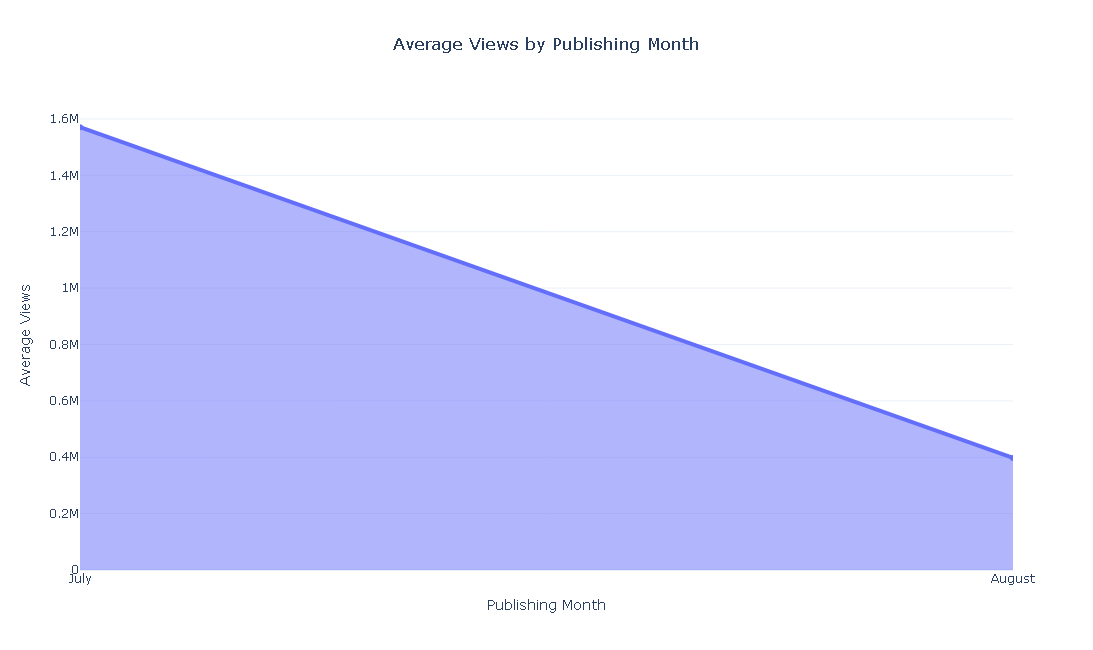

In [72]:
import plotly.express as px

fig = px.area(

    monthly_report,

    x="publish_month_name",

    y="Average_Views",

    markers=True,

    color_discrete_sequence=["#636EFA"],

    title="Average Views by Publishing Month"

)

fig.update_traces(

    line=dict(width=4)

)

fig.update_layout(

    template="plotly_white",

    height=650,

    title_x=0.5,

    xaxis_title="Publishing Month",

    yaxis_title="Average Views"

)

fig.show()

In [73]:
# ==========================================================
# Business Question:
# Which upload day and upload hour combination
# generates the highest average views?
# ==========================================================

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

upload_schedule = (

    df

    .groupby(
        ["publish_day_name", "publish_hour"],
        as_index=False
    )

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

upload_schedule["publish_day_name"] = pd.Categorical(

    upload_schedule["publish_day_name"],

    categories=day_order,

    ordered=True

)

upload_schedule = (

    upload_schedule

    .sort_values(

        ["publish_day_name","publish_hour"]

    )

)

upload_schedule = upload_schedule.round(2)

upload_schedule

,publish_day_name,publish_hour,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate
8,Monday,0,9,2239340,248815.56,0.04,0.04,0.01
9,Monday,1,8,641647,80205.88,0.06,0.05,0.01
10,Monday,2,5,769997,153999.40,0.03,0.03,0.00
11,Monday,3,3,453178,151059.33,0.03,0.03,0.00
12,Monday,4,5,840708,168141.60,0.04,0.03,0.00
13,Monday,5,5,1080221,216044.20,0.03,0.03,0.00
14,Monday,6,3,658962,219654.00,0.02,0.02,0.00
15,Monday,7,4,446553,111638.25,0.03,0.03,0.00
16,Monday,8,4,673598,168399.50,0.02,0.02,0.00
17,Monday,9,3,683335,227778.33,0.01,0.01,0.00


In [74]:
heatmap_data = upload_schedule.pivot_table(

    index="publish_day_name",

    columns="publish_hour",

    values="Average_Views"

)

heatmap_data

publish_hour,0,1,2,3,4,5,6,7,8,9,11,12,13,14,15,16,17,18,19,20,21,22,23
publish_day_name,,,,,,,,,,,,,,,,,,,,,,,
Monday,248815.56,80205.88,153999.4,151059.33,168141.60,216044.2,219654.0,111638.25,168399.5,227778.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tuesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,33799.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,55223.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Friday,NaN,NaN,NaN,NaN,1460683.33,NaN,NaN,NaN,NaN,255239.00,NaN,NaN,NaN,NaN,9356390.00,2765423.00,NaN,306974.00,2624779.00,763608.00,NaN,NaN,660322.5
Saturday,506094.00,278089.00,NaN,710557.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,652885.5,NaN,1097770.00,500066.00,8028984.00,737709.00,133202.33,NaN,NaN,560236.4,NaN,607356.0
Sunday,617141.00,199291.33,544312.5,NaN,NaN,140161.0,226537.0,NaN,297722.0,36419.00,394854.0,253095.0,212551.5,211539.44,858220.89,220637.93,171305.36,161993.25,204808.38,97752.62,152695.4,103298.88,239162.5


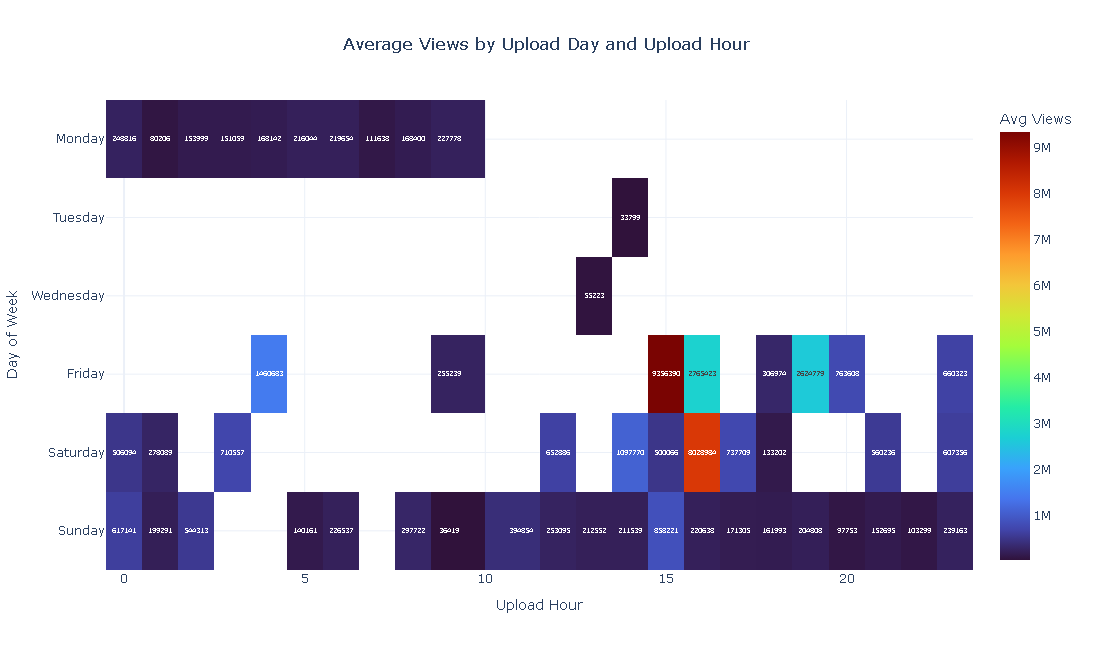

In [75]:
import plotly.express as px

fig = px.imshow(

    heatmap_data,

    text_auto=".0f",

    aspect="auto",

    color_continuous_scale="Turbo",

    title="Average Views by Upload Day and Upload Hour"

)

fig.update_layout(

    template="plotly_white",

    height=650,

    title_x=0.5,

    xaxis_title="Upload Hour",

    yaxis_title="Day of Week",

    coloraxis_colorbar_title="Avg Views"

)

fig.show()

In [76]:
best_slots = (

    upload_schedule

    .sort_values(

        "Average_Views",

        ascending=False

    )

    .head(10)

)

best_slots

,publish_day_name,publish_hour,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate
2,Friday,15,1,9356390,9356390.00,0.07,0.07,0.01
24,Saturday,16,3,24086952,8028984.00,0.05,0.04,0.00
3,Friday,16,2,5530846,2765423.00,0.07,0.06,0.01
5,Friday,19,1,2624779,2624779.00,0.04,0.04,0.00
0,Friday,4,3,4382050,1460683.33,0.03,0.03,0.00
22,Saturday,14,3,3293310,1097770.00,0.02,0.02,0.00
40,Sunday,15,9,7723988,858220.89,0.04,0.04,0.01
6,Friday,20,1,763608,763608.00,0.06,0.05,0.00
25,Saturday,17,1,737709,737709.00,0.03,0.03,0.00
20,Saturday,3,1,710557,710557.00,0.05,0.05,0.00


In [77]:
# ==========================================================
# Business Question:
# Does video duration influence views and engagement?
# ==========================================================

duration_analysis = (

    df

    .groupby("duration_category", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean"),

        Average_Duration=("duration_seconds","mean")

    )

)

duration_analysis = duration_analysis.round(2)

duration_analysis["View_Share_%"]=(

    duration_analysis["Total_Views"]

    /

    duration_analysis["Total_Views"].sum()

    *100

).round(2)

duration_analysis["Rank"]=(

    duration_analysis["Average_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

duration_analysis

,duration_category,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Average_Duration,View_Share_%,Rank
0,Long,165,62065748,376156.05,132427.0,0.04,0.04,0.0,6956.86,63.4,2
1,Medium,34,35827345,1053745.44,345037.5,0.04,0.04,0.0,242.24,36.6,1


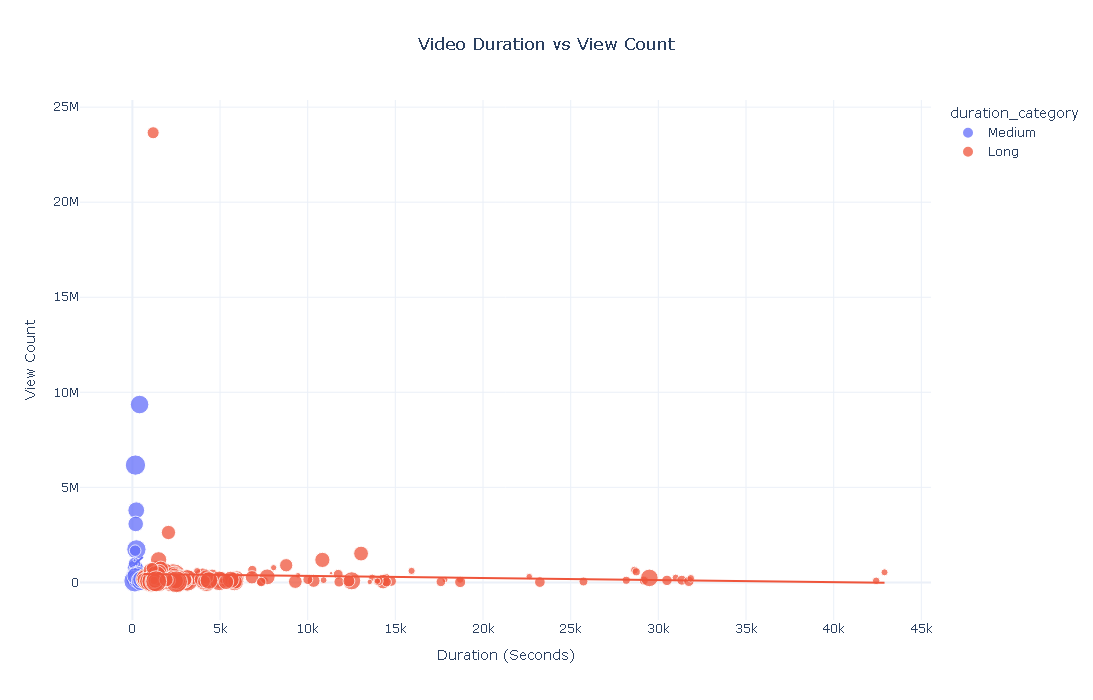

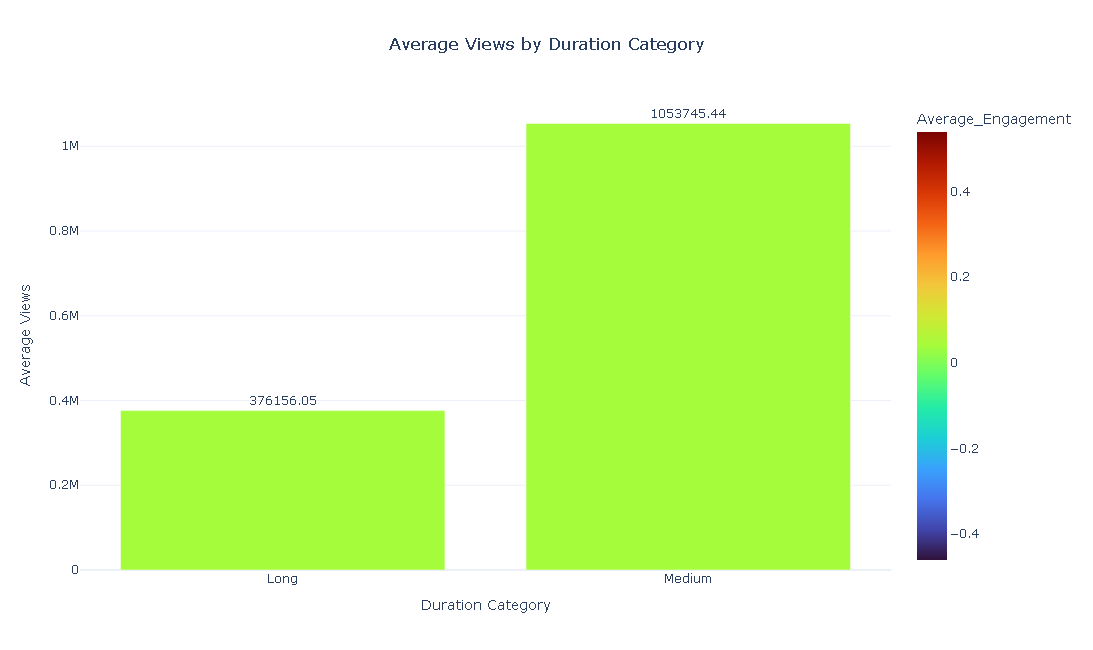

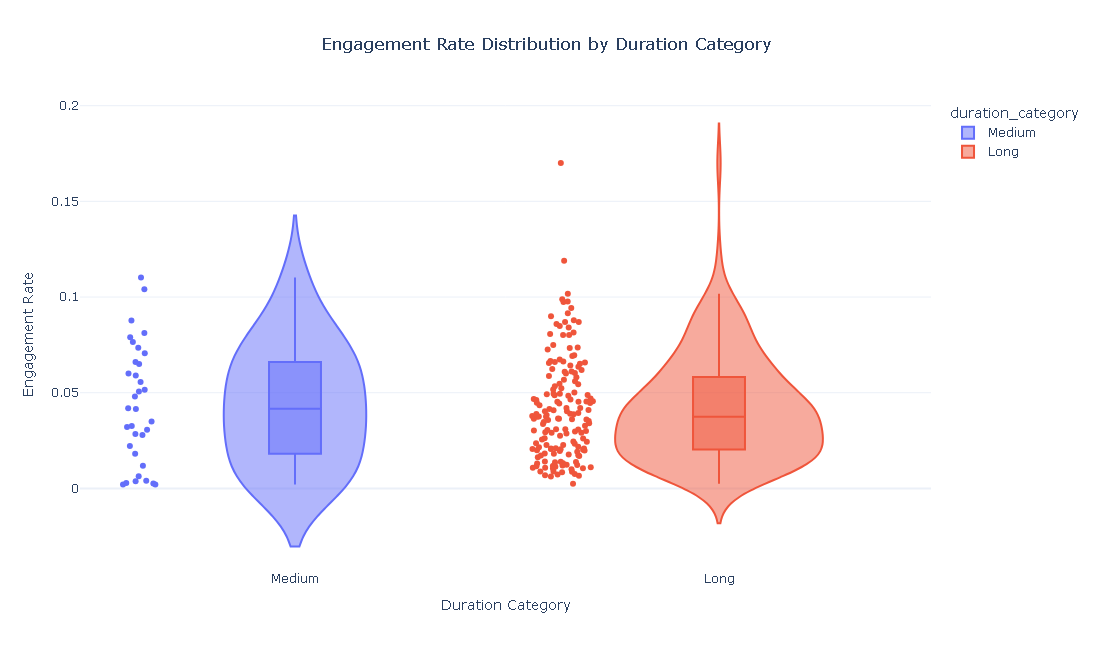

In [78]:
import plotly.express as px
import statsmodels


fig = px.scatter(

    df,

    x="duration_seconds",

    y="view_count",

    color="duration_category",

    size="engagement_rate",

    hover_name="title",

    trendline="ols",

    opacity=0.75,

    title="Video Duration vs View Count"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=700,

    xaxis_title="Duration (Seconds)",

    yaxis_title="View Count"

)

fig.show()

fig = px.bar(

    duration_analysis,

    x="duration_category",

    y="Average_Views",

    color="Average_Engagement",

    text="Average_Views",

    color_continuous_scale="Turbo",

    title="Average Views by Duration Category"

)

fig.update_traces(

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=650,

    xaxis_title="Duration Category",

    yaxis_title="Average Views"

)

fig.show()

fig = px.violin(

    df,

    x="duration_category",

    y="engagement_rate",

    color="duration_category",

    box=True,

    points="all",

    title="Engagement Rate Distribution by Duration Category"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=650,

    xaxis_title="Duration Category",

    yaxis_title="Engagement Rate"

)

fig.show()

In [79]:
# ==========================================================
# Business Question:
# Does title length influence video performance?
# ==========================================================

title_analysis = (

    df

    .groupby("title_word_count", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

title_analysis = title_analysis.round(2)

title_analysis["Rank"] = (

    title_analysis["Average_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

title_analysis

,title_word_count,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Rank
0,1,2,683481,341740.50,341740.5,0.04,0.04,0.00,8
1,2,3,292446,97482.00,122408.0,0.03,0.03,0.00,18
2,3,4,3344721,836180.25,325025.5,0.04,0.04,0.00,3
3,4,15,9731296,648753.07,278367.0,0.05,0.05,0.00,5
4,5,18,29829062,1657170.11,220432.0,0.04,0.03,0.00,1
5,6,32,8471834,264744.81,108557.0,0.04,0.04,0.01,12
6,7,31,21159908,682577.68,133655.0,0.05,0.04,0.00,4
7,8,26,7237755,278375.19,213191.0,0.04,0.03,0.00,10
8,9,19,4423524,232817.05,121728.0,0.04,0.04,0.00,14
9,10,15,1800845,120056.33,87941.0,0.06,0.05,0.00,16


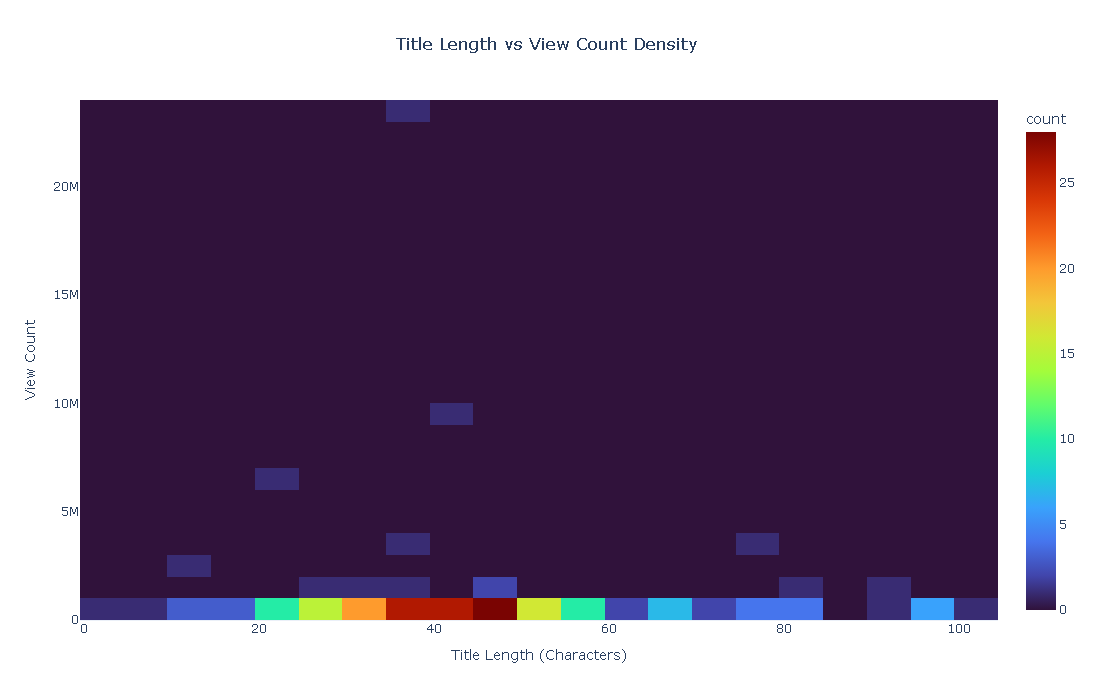

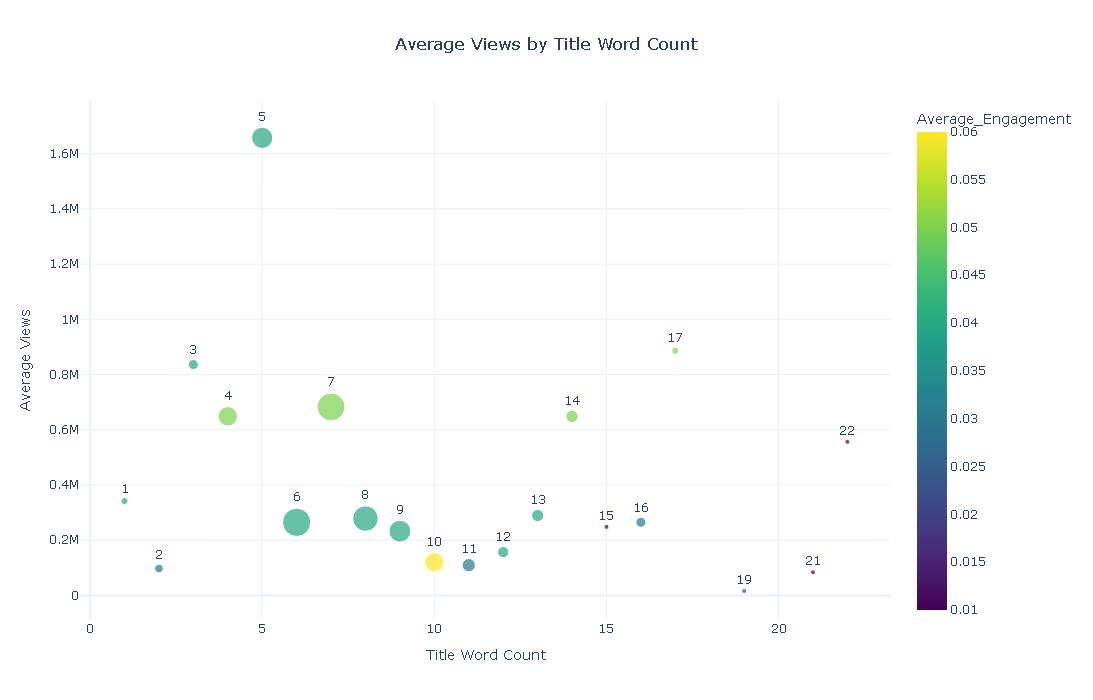

In [80]:
import plotly.express as px

fig = px.density_heatmap(

    df,

    x="title_length",

    y="view_count",

    nbinsx=25,

    nbinsy=25,

    color_continuous_scale="Turbo",

    title="Title Length vs View Count Density"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=700,

    xaxis_title="Title Length (Characters)",

    yaxis_title="View Count"

)

fig.show()

fig = px.scatter(

    title_analysis,

    x="title_word_count",

    y="Average_Views",

    size="Total_Videos",

    color="Average_Engagement",

    text="title_word_count",

    color_continuous_scale="Viridis",

    title="Average Views by Title Word Count"

)

fig.update_traces(

    textposition="top center"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=700,

    xaxis_title="Title Word Count",

    yaxis_title="Average Views"

)

fig.show()

In [81]:
# ==========================================================
# Business Question:
# Does the number of tags improve video performance?
# ==========================================================

tag_analysis = (

    df

    .groupby("tag_count", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

tag_analysis = tag_analysis.round(2)

tag_analysis["Rank"]=(

    tag_analysis["Average_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

tag_analysis

,tag_count,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Rank
0,0,46,37314670,811188.48,159153.0,0.04,0.03,0.00,4
1,1,2,373256,186628.00,186628.0,0.04,0.04,0.00,27
2,2,4,1165445,291361.25,248012.5,0.02,0.02,0.00,13
3,3,10,2407627,240762.70,136510.5,0.05,0.05,0.00,20
4,4,6,12386793,2064465.50,623546.5,0.04,0.04,0.00,1
5,5,8,667118,83389.75,82107.5,0.06,0.05,0.01,42
6,6,5,6661694,1332338.80,1181939.0,0.04,0.04,0.00,3
7,7,3,607962,202654.00,151646.0,0.05,0.04,0.00,23
8,8,4,1724087,431021.75,374511.5,0.02,0.02,0.00,7
9,9,1,103419,103419.00,103419.0,0.05,0.04,0.01,41


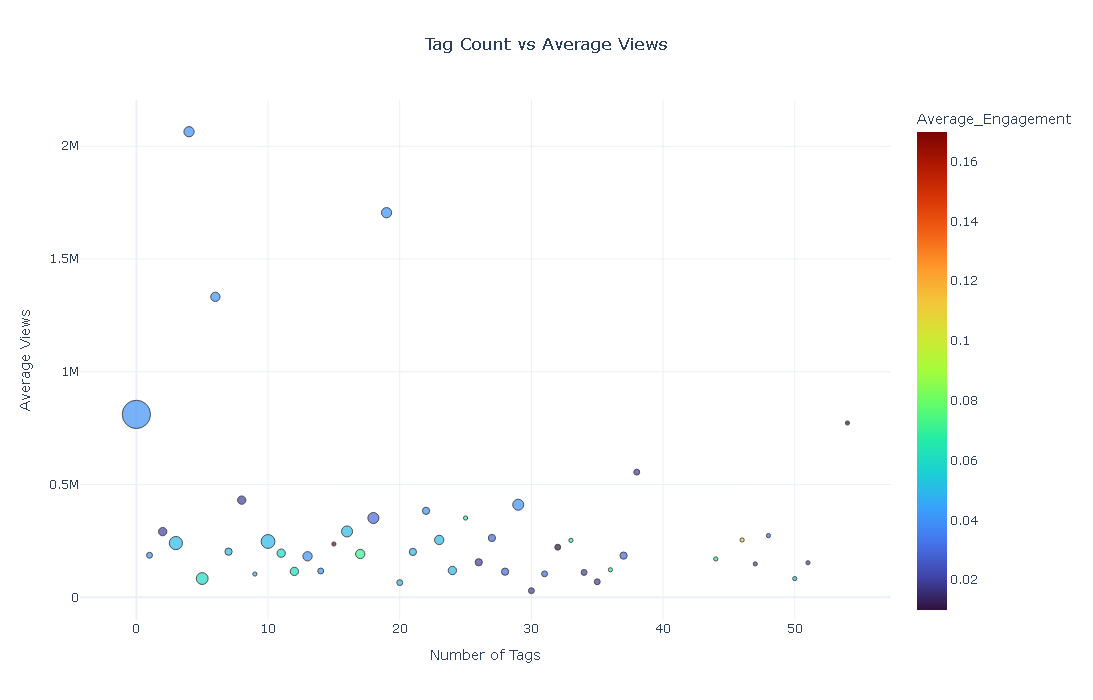

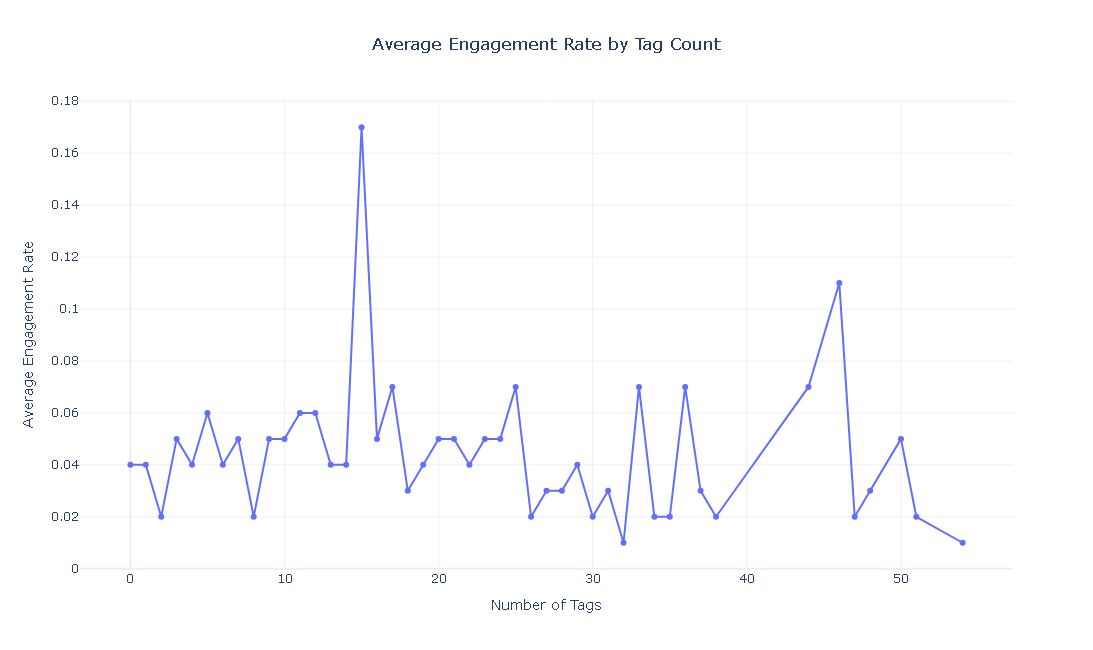

In [82]:
import plotly.express as px

fig = px.scatter(

    tag_analysis,

    x="tag_count",

    y="Average_Views",

    size="Total_Videos",

    color="Average_Engagement",

    hover_data=[

        "Average_Like_Rate",

        "Average_Comment_Rate"

    ],

    color_continuous_scale="Turbo",

    title="Tag Count vs Average Views"

)

fig.update_traces(

    marker=dict(

        line=dict(

            color="black",

            width=1

        )

    )

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=700,

    xaxis_title="Number of Tags",

    yaxis_title="Average Views"

)

fig.show()

fig = px.line(

    tag_analysis,

    x="tag_count",

    y="Average_Engagement",

    markers=True,

    title="Average Engagement Rate by Tag Count"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=650,

    xaxis_title="Number of Tags",

    yaxis_title="Average Engagement Rate"

)

fig.show()

In [83]:
# ==========================================================
# Business Question:
# Which duration category performs best across
# different YouTube categories?
# ==========================================================

duration_category_analysis = (

    df

    .groupby(

        ["category_name","duration_category"],

        as_index=False

    )

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

duration_category_analysis = duration_category_analysis.round(2)

duration_category_analysis

,category_name,duration_category,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate
0,Comedy,Medium,1,338216,338216.00,0.06,0.06,0.00
1,Entertainment,Long,10,2466804,246680.40,0.05,0.04,0.01
2,Entertainment,Medium,1,722184,722184.00,0.02,0.02,0.00
3,Film & Animation,Medium,1,13512,13512.00,0.02,0.02,0.00
4,Gaming,Long,150,59185372,394569.15,0.04,0.04,0.00
5,Gaming,Medium,7,3441781,491683.00,0.05,0.04,0.00
6,Music,Long,1,118591,118591.00,0.01,0.01,0.00
7,Music,Medium,23,30933371,1344929.17,0.05,0.04,0.00
8,People & Blogs,Long,3,125508,41836.00,0.06,0.05,0.01
9,People & Blogs,Medium,1,378281,378281.00,0.01,0.01,0.00


In [84]:
heatmap = duration_category_analysis.pivot_table(

    index="category_name",

    columns="duration_category",

    values="Average_Engagement"

)

heatmap

duration_category,Long,Medium
category_name,,
Comedy,NaN,0.06
Entertainment,0.05,0.02
Film & Animation,NaN,0.02
Gaming,0.04,0.05
Music,0.01,0.05
People & Blogs,0.06,0.01
Sports,0.05,NaN


In [85]:
best_duration = (

    duration_category_analysis

    .sort_values(

        "Average_Engagement",

        ascending=False

    )

)

best_duration.head(20)

,category_name,duration_category,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate
0,Comedy,Medium,1,338216,338216.00,0.06,0.06,0.00
8,People & Blogs,Long,3,125508,41836.00,0.06,0.05,0.01
1,Entertainment,Long,10,2466804,246680.40,0.05,0.04,0.01
7,Music,Medium,23,30933371,1344929.17,0.05,0.04,0.00
5,Gaming,Medium,7,3441781,491683.00,0.05,0.04,0.00
10,Sports,Long,1,169473,169473.00,0.05,0.04,0.00
4,Gaming,Long,150,59185372,394569.15,0.04,0.04,0.00
2,Entertainment,Medium,1,722184,722184.00,0.02,0.02,0.00
3,Film & Animation,Medium,1,13512,13512.00,0.02,0.02,0.00
6,Music,Long,1,118591,118591.00,0.01,0.01,0.00


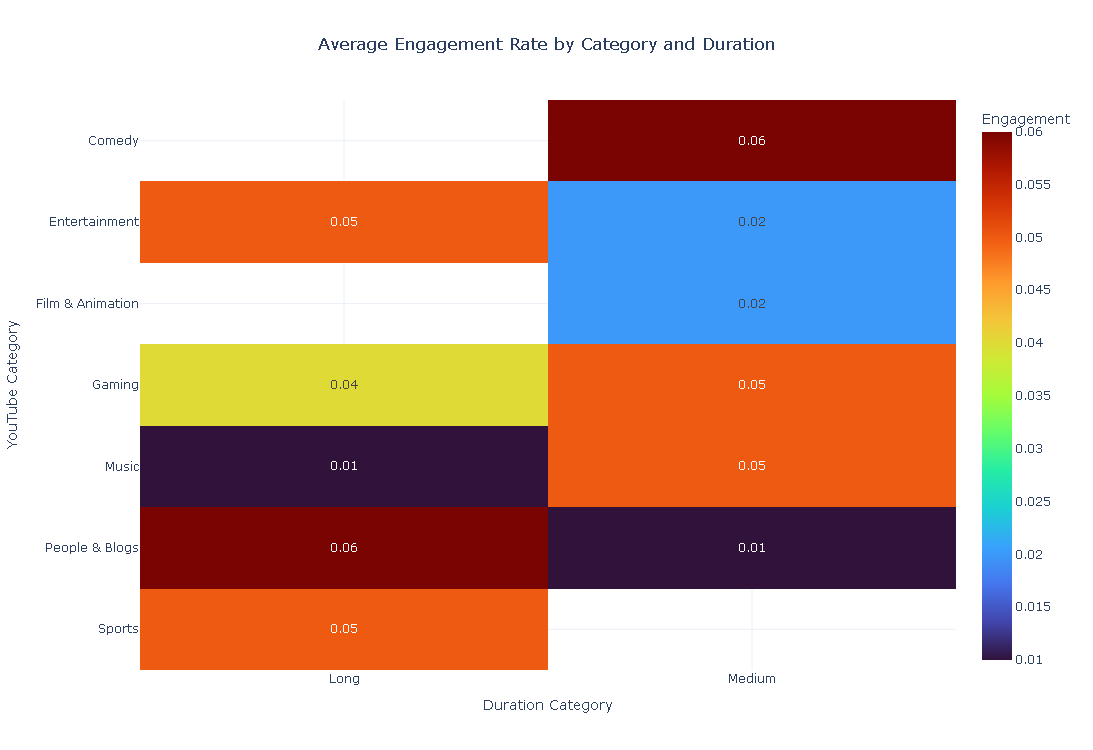

In [86]:
import plotly.express as px

fig = px.imshow(

    heatmap,

    text_auto=".2f",

    aspect="auto",

    color_continuous_scale="Turbo",

    title="Average Engagement Rate by Category and Duration"

)

fig.update_layout(

    template="plotly_white",

    height=750,

    title_x=0.5,

    xaxis_title="Duration Category",

    yaxis_title="YouTube Category",

    coloraxis_colorbar_title="Engagement"

)

fig.show()

In [87]:
# ==========================================================
# Business Question:
# Which content categories perform best in each upload session?
# ==========================================================

session_category = (

    df

    .groupby(

        ["category_name","publish_session"],

        as_index=False

    )

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum")

    )

)

session_category = session_category.round(2)

session_category

,category_name,publish_session,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Total_Likes,Total_Comments
0,Comedy,Evening,1,338216,338216.00,338216.0,0.06,0.06,0.00,18851,1120
1,Entertainment,Afternoon,2,615184,307592.00,307592.0,0.02,0.02,0.00,10639,2155
2,Entertainment,Evening,3,892310,297436.67,99226.0,0.05,0.04,0.01,23256,3389
3,Entertainment,Morning,1,644179,644179.00,644179.0,0.01,0.01,0.00,8270,133
4,Entertainment,Night,5,1037315,207463.00,136239.0,0.06,0.05,0.01,50127,4785
5,Film & Animation,Night,1,13512,13512.00,13512.0,0.02,0.02,0.00,225,19
6,Gaming,Afternoon,56,37335362,666702.89,151323.5,0.04,0.04,0.00,1243581,60519
7,Gaming,Evening,46,12118340,263442.17,116850.5,0.05,0.04,0.00,429529,28218
8,Gaming,Morning,17,4329871,254698.29,152263.0,0.03,0.03,0.00,132306,17489
9,Gaming,Night,38,8843580,232725.79,125172.5,0.04,0.03,0.00,256121,22443


In [88]:
heatmap = session_category.pivot_table(

    index="category_name",

    columns="publish_session",

    values="Average_Views"

)

heatmap

publish_session,Afternoon,Evening,Morning,Night
category_name,,,,
Comedy,NaN,338216.00,NaN,NaN
Entertainment,307592.00,297436.67,644179.00,207463.00
Film & Animation,NaN,NaN,NaN,13512.00
Gaming,666702.89,263442.17,254698.29,232725.79
Music,2257142.70,540338.50,267874.00,874614.17
People & Blogs,378281.00,NaN,36419.00,44544.50
Sports,NaN,169473.00,NaN,NaN


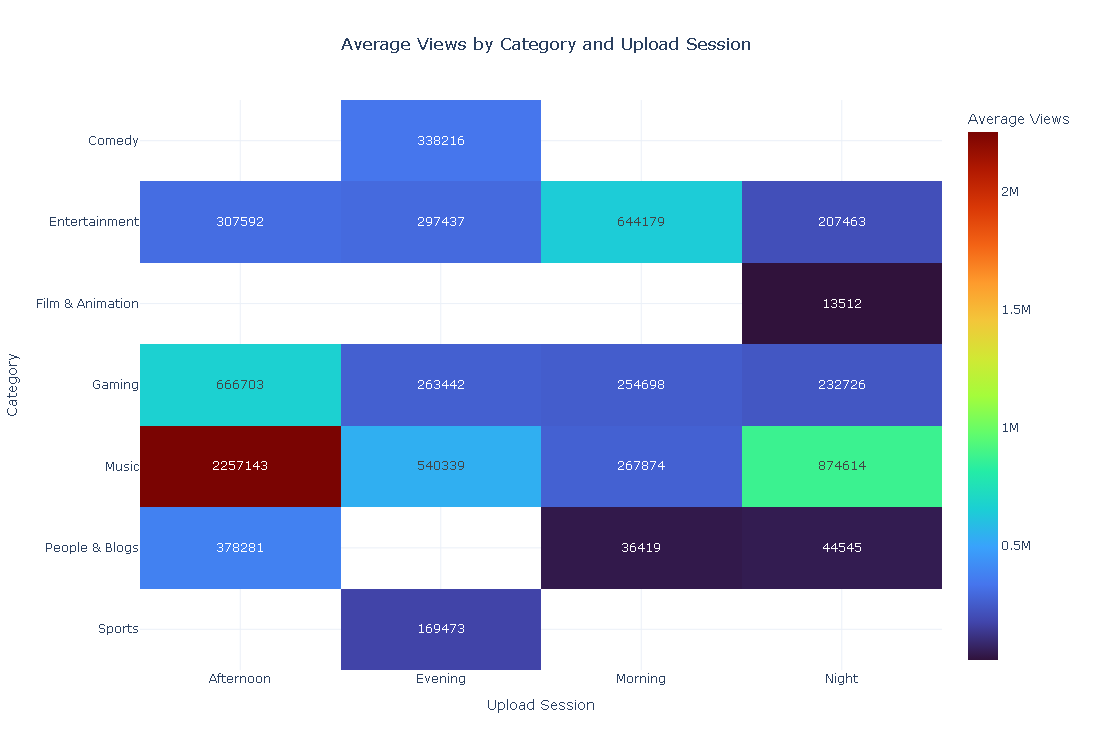

In [89]:
import plotly.express as px

fig = px.imshow(

    heatmap,

    text_auto=".0f",

    aspect="auto",

    color_continuous_scale="Turbo",

    title="Average Views by Category and Upload Session"

)

fig.update_layout(

    template="plotly_white",

    height=750,

    title_x=0.5,

    xaxis_title="Upload Session",

    yaxis_title="Category",

    coloraxis_colorbar_title="Average Views"

)

fig.show()

In [90]:
# ==========================================================
# Business Question:
# Which YouTube categories receive the highest audience
# engagement on weekends compared to weekdays?
# ==========================================================

weekend_analysis = (

    df

    .groupby(

        ["category_name", "weekend_flag"],

        as_index=False

    )

    .agg(

        Total_Videos=("video_id", "count"),

        Total_Views=("view_count", "sum"),

        Average_Views=("view_count", "mean"),

        Average_Engagement=("engagement_rate", "mean"),

        Average_Like_Rate=("like_rate", "mean"),

        Average_Comment_Rate=("comment_rate", "mean")

    )

)

weekend_analysis = weekend_analysis.round(2)

weekend_analysis

,category_name,weekend_flag,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate
0,Comedy,True,1,338216,338216.00,0.06,0.06,0.00
1,Entertainment,False,6,1681494,280249.00,0.05,0.05,0.01
2,Entertainment,True,5,1507494,301498.80,0.04,0.03,0.01
3,Film & Animation,False,1,13512,13512.00,0.02,0.02,0.00
4,Gaming,False,41,9328223,227517.63,0.03,0.03,0.00
5,Gaming,True,116,53298930,459473.53,0.04,0.04,0.00
6,Music,False,13,22004774,1692674.92,0.04,0.03,0.00
7,Music,True,11,9047188,822471.64,0.05,0.05,0.00
8,People & Blogs,False,2,89089,44544.50,0.08,0.06,0.02
9,People & Blogs,True,2,414700,207350.00,0.01,0.01,0.00


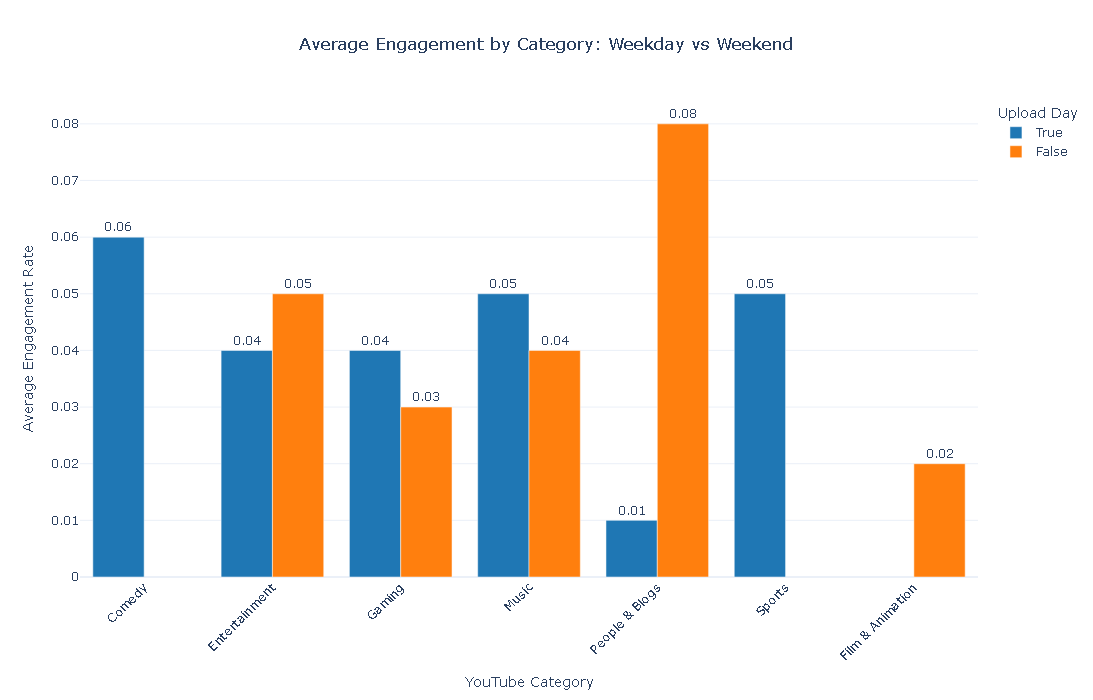

In [91]:
import plotly.express as px

fig = px.bar(

    weekend_analysis,

    x="category_name",

    y="Average_Engagement",

    color="weekend_flag",

    barmode="group",

    text="Average_Engagement",

    color_discrete_sequence=["#1F77B4", "#FF7F0E"],

    title="Average Engagement by Category: Weekday vs Weekend"

)

fig.update_traces(

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="YouTube Category",

    yaxis_title="Average Engagement Rate",

    legend_title="Upload Day",

    xaxis_tickangle=-45

)

fig.show()

In [92]:
# ==========================================================
# Business Question:
# Which upload day and upload hour combination
# generates the highest average engagement rate?
# ==========================================================

import pandas as pd

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

upload_schedule = (

    df

    .groupby(

        ["publish_day_name","publish_hour"],

        as_index=False

    )

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

upload_schedule["publish_day_name"] = pd.Categorical(

    upload_schedule["publish_day_name"],

    categories=day_order,

    ordered=True

)

upload_schedule = (

    upload_schedule

    .sort_values(

        ["publish_day_name","publish_hour"]

    )

)

upload_schedule = upload_schedule.round(2)

upload_schedule

,publish_day_name,publish_hour,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate
8,Monday,0,9,2239340,248815.56,0.04,0.04,0.01
9,Monday,1,8,641647,80205.88,0.06,0.05,0.01
10,Monday,2,5,769997,153999.40,0.03,0.03,0.00
11,Monday,3,3,453178,151059.33,0.03,0.03,0.00
12,Monday,4,5,840708,168141.60,0.04,0.03,0.00
13,Monday,5,5,1080221,216044.20,0.03,0.03,0.00
14,Monday,6,3,658962,219654.00,0.02,0.02,0.00
15,Monday,7,4,446553,111638.25,0.03,0.03,0.00
16,Monday,8,4,673598,168399.50,0.02,0.02,0.00
17,Monday,9,3,683335,227778.33,0.01,0.01,0.00


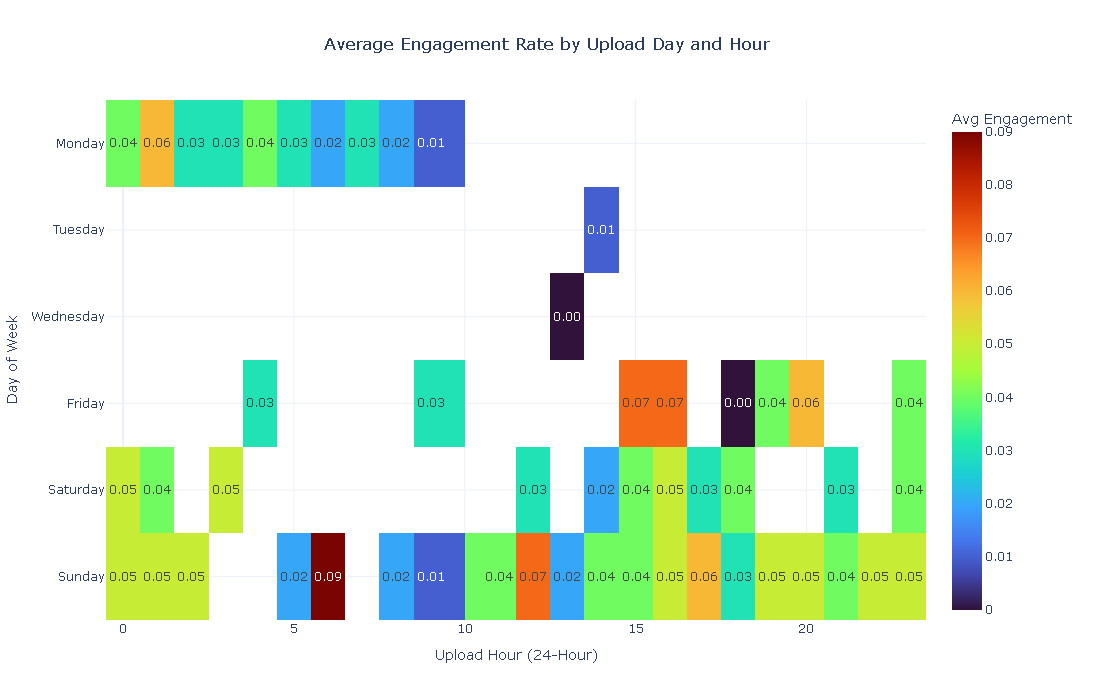

In [93]:
import plotly.express as px

heatmap = upload_schedule.pivot_table(

    index="publish_day_name",

    columns="publish_hour",

    values="Average_Engagement"

)

fig = px.imshow(

    heatmap,

    text_auto=".2f",

    color_continuous_scale="Turbo",

    aspect="auto",

    title="Average Engagement Rate by Upload Day and Hour"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="Upload Hour (24-Hour)",

    yaxis_title="Day of Week",

    coloraxis_colorbar_title="Avg Engagement"

)

fig.show()

In [94]:
# ==========================================================
# Business Question:
# Which business KPIs are most strongly correlated?
# ==========================================================

kpi_columns = [

    "view_count",

    "like_count",

    "comment_count",

    "favorite_count",

    "duration_seconds",

    "title_length",

    "title_word_count",

    "description_length",

    "description_word_count",

    "tag_count",

    "engagement_score",

    "engagement_rate",

    "like_rate",

    "comment_rate",

    "channel_video_count"

]

correlation_matrix = (

    df

    [kpi_columns]

    .corr(

        method="pearson"

    )

    .round(2)

)

correlation_matrix

,view_count,like_count,comment_count,favorite_count,duration_seconds,title_length,title_word_count,description_length,description_word_count,tag_count,engagement_score,engagement_rate,like_rate,comment_rate,channel_video_count
view_count,1.00,0.91,0.63,NaN,-0.09,-0.04,-0.08,0.10,0.13,-0.09,0.90,0.02,0.03,-0.04,NaN
like_count,0.91,1.00,0.88,NaN,-0.12,-0.04,-0.08,0.15,0.17,-0.09,1.00,0.15,0.16,0.04,NaN
comment_count,0.63,0.88,1.00,NaN,-0.14,-0.04,-0.07,0.14,0.17,-0.07,0.90,0.21,0.20,0.16,NaN
favorite_count,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_seconds,-0.09,-0.12,-0.14,NaN,1.00,0.23,0.27,0.04,0.01,-0.02,-0.12,-0.35,-0.33,-0.34,NaN
title_length,-0.04,-0.04,-0.04,NaN,0.23,1.00,0.92,0.17,0.17,0.15,-0.04,-0.02,-0.01,-0.08,NaN
title_word_count,-0.08,-0.08,-0.07,NaN,0.27,0.92,1.00,0.19,0.19,0.18,-0.08,-0.06,-0.05,-0.11,NaN
description_length,0.10,0.15,0.14,NaN,0.04,0.17,0.19,1.00,0.97,0.25,0.15,-0.03,-0.03,-0.04,NaN
description_word_count,0.13,0.17,0.17,NaN,0.01,0.17,0.19,0.97,1.00,0.23,0.17,-0.08,-0.08,-0.06,NaN
tag_count,-0.09,-0.09,-0.07,NaN,-0.02,0.15,0.18,0.25,0.23,1.00,-0.08,-0.04,-0.04,-0.04,NaN


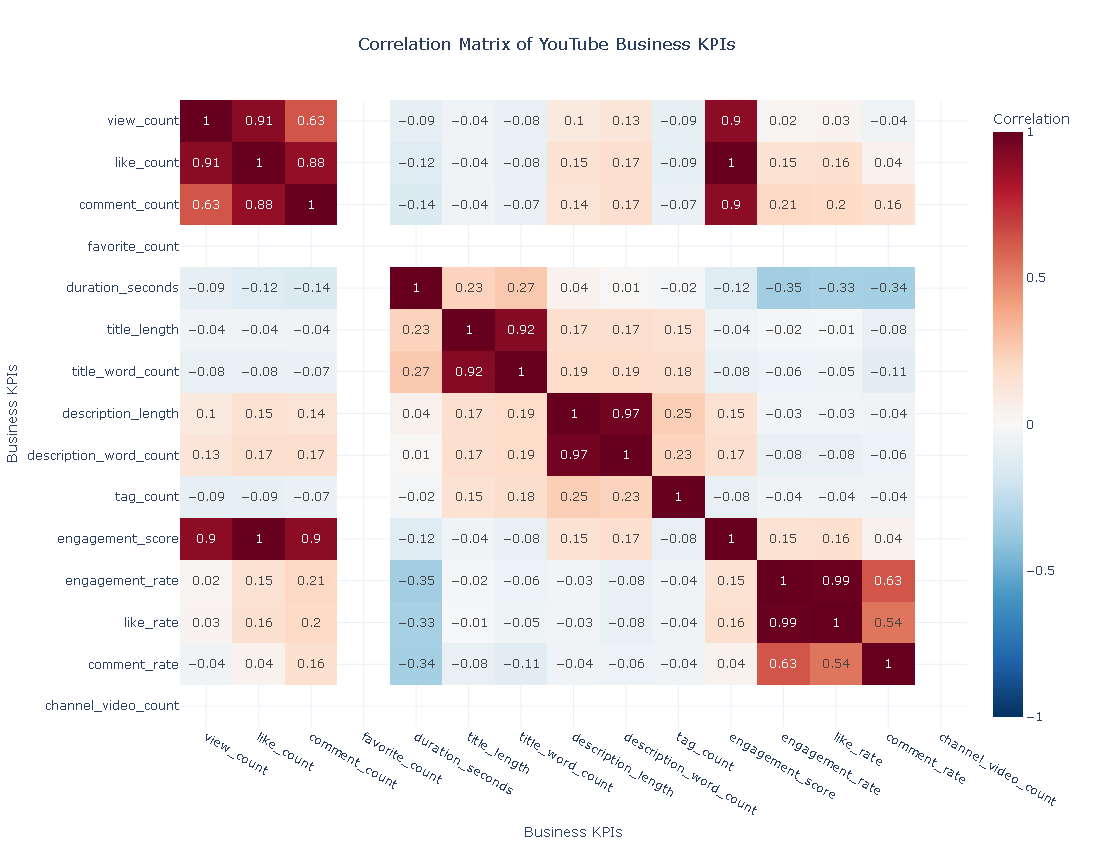

In [95]:
import plotly.express as px

fig = px.imshow(

    correlation_matrix,

    text_auto=True,

    color_continuous_scale="RdBu_r",

    zmin=-1,

    zmax=1,

    aspect="auto",

    title="Correlation Matrix of YouTube Business KPIs"

)

fig.update_layout(

    template="plotly_white",

    height=850,

    title_x=0.5,

    xaxis_title="Business KPIs",

    yaxis_title="Business KPIs",

    coloraxis_colorbar_title="Correlation"

)

fig.show()

In [96]:
# ==========================================================
# Business Question:
# Which trending videos generate the highest
# overall audience engagement?
# ==========================================================

top_videos = (

    df

    .assign(

        Engagement_Score =

        df["like_count"] +

        df["comment_count"]

    )

    .sort_values(

        "Engagement_Score",

        ascending=False

    )

    .head(20)

)

top_videos = top_videos[

[
    "title",

    "channel_title",

    "category_name",

    "view_count",

    "like_count",

    "comment_count",

    "Engagement_Score",

    "engagement_rate",

    "duration_category"

]

]

top_videos.round(2)

,title,channel_title,category_name,view_count,like_count,comment_count,Engagement_Score,engagement_rate,duration_category
19,Exploring My Abandoned Minecraft Server,MrBeast Gaming,Gaming,23654668,712711,18971,731682,0.03,Long
0,Ariana Grande - petal (official music video),ArianaGrandeVevo,Music,9356390,630087,58086,688173,0.07,Medium
3,BABYMONSTER - 'MOON' M/V,BABYMONSTER,Music,6170913,499751,41985,541736,0.09,Medium
26,KATSEYE - Animal (on the dance floor),KATSEYE,Music,3794321,207682,20211,227893,0.06,Medium
42,"benny blanco, Selena Gomez, Becky G - Te Olvid...",bennyblancoVEVO,Music,3075542,151809,6912,158721,0.05,Medium
20,Five Nights at Freddy's: Secret of the Mimic S...,The Living Tombstone,Music,1736525,127940,9129,137069,0.08,Medium
134,OH MY GOD...,SMii7Y,Gaming,2624779,109983,4186,114169,0.04,Long
137,Tienes Una Deuda de $100.000.000,Rubius Z,Gaming,1516717,68462,2358,70820,0.05,Long
113,They killed the greatest franchise of all time..,Asmongold TV,Gaming,1187180,58190,9238,67428,0.06,Long
2,Five Nights at Freddy's: ULTIMATE CUSTOM STREAM,Markiplier,Gaming,1181939,57390,784,58174,0.05,Long


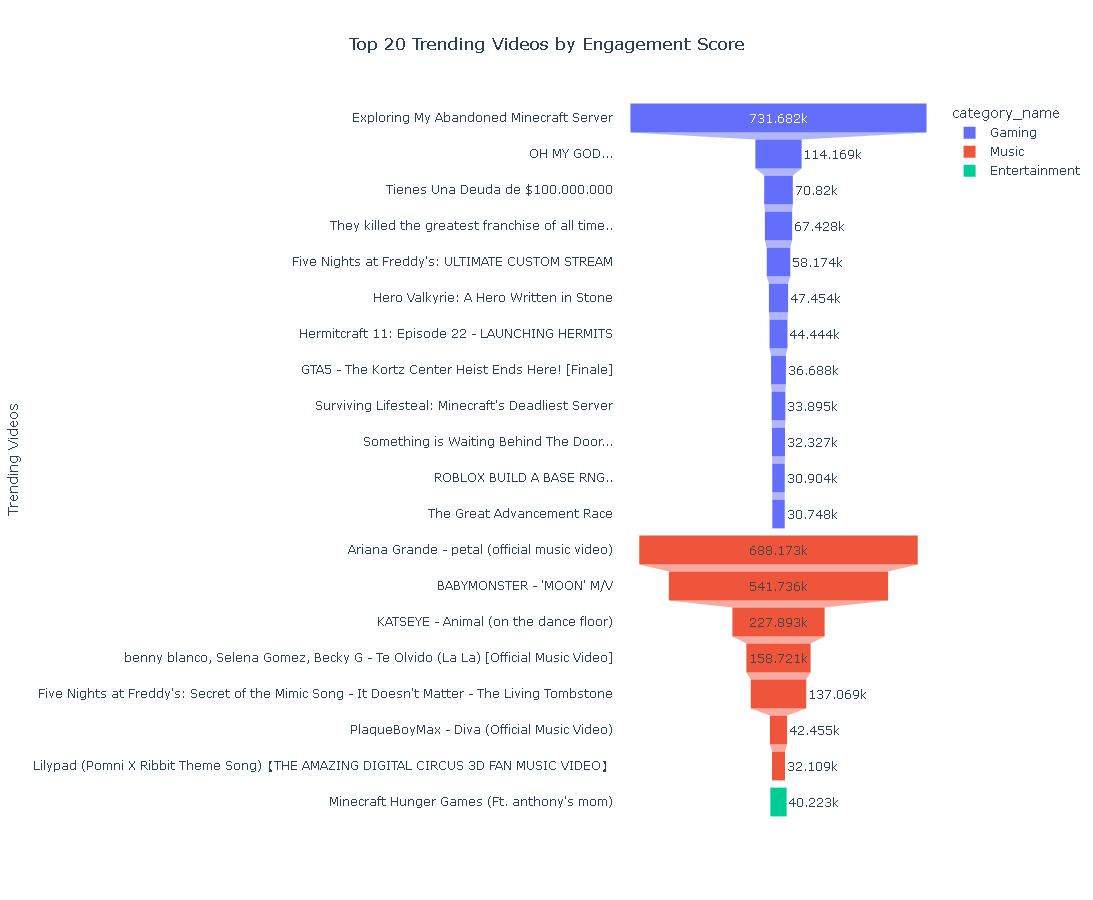

In [97]:
import plotly.express as px

fig = px.funnel(

    top_videos,

    y="title",

    x="Engagement_Score",

    color="category_name",

    hover_data=[

        "channel_title",

        "view_count",

        "engagement_rate"

    ],

    title="Top 20 Trending Videos by Engagement Score"

)

fig.update_layout(

    template="plotly_white",

    height=900,

    title_x=0.5,

    yaxis_title="Trending Videos",

    xaxis_title="Engagement Score"

)

fig.show()

In [98]:
# ==========================================================
# Business Question:
# Which YouTube channels dominate the trending ecosystem?
# ==========================================================

channel_dashboard = (

    df

    .groupby("channel_title", as_index=False)

    .agg(

        Trending_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean")

    )

)

channel_dashboard["Engagement_Score"] = (

    channel_dashboard["Total_Likes"]

    +

    channel_dashboard["Total_Comments"]

)

channel_dashboard["View_Share_%"] = (

    channel_dashboard["Total_Views"]

    /

    channel_dashboard["Total_Views"].sum()

    *100

).round(2)

channel_dashboard["Rank"] = (

    channel_dashboard["Total_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

top_channels = (

    channel_dashboard

    .sort_values(

        "Total_Views",

        ascending=False

    )

    .head(20)

)

top_channels

,channel_title,Trending_Videos,Total_Views,Total_Likes,Total_Comments,Average_Views,Average_Engagement,Engagement_Score,View_Share_%,Rank
114,MrBeast Gaming,1,23654668,712711,18971,23654668.0,0.030932,731682,24.16,1
5,ArianaGrandeVevo,1,9356390,630087,58086,9356390.0,0.073551,688173,9.56,2
11,BABYMONSTER,1,6170913,499751,41985,6170913.0,0.087789,541736,6.30,3
83,KATSEYE,1,3794321,207682,20211,3794321.0,0.060062,227893,3.88,4
187,bennyblancoVEVO,1,3075542,151809,6912,3075542.0,0.051607,158721,3.14,5
140,SMii7Y,1,2624779,109983,4186,2624779.0,0.043497,114169,2.68,6
160,The Living Tombstone,1,1736525,127940,9129,1736525.0,0.078933,137069,1.77,7
29,Clash Royale,1,1668880,46492,962,1668880.0,0.028435,47454,1.70,8
138,Rubius Z,1,1516717,68462,2358,1516717.0,0.046693,70820,1.55,9
6,Asmongold TV,1,1187180,58190,9238,1187180.0,0.056797,67428,1.21,10


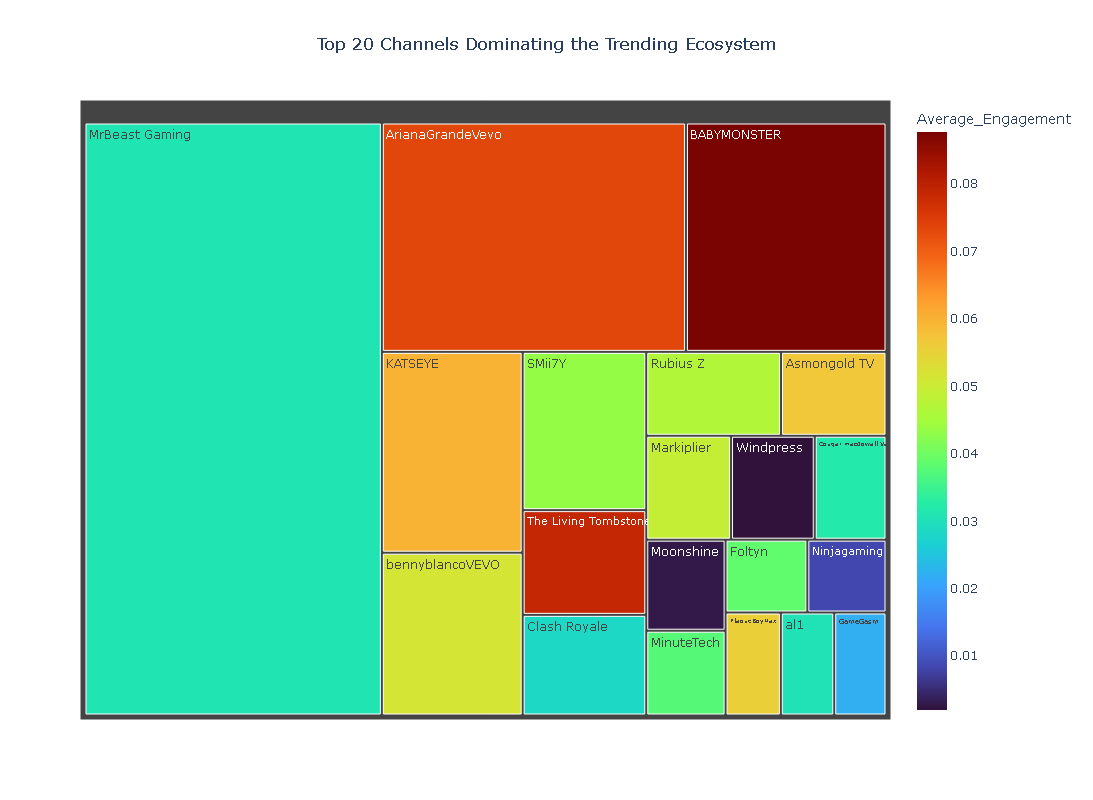

In [99]:
import plotly.express as px

fig = px.treemap(

    top_channels,

    path=["channel_title"],

    values="Total_Views",

    color="Average_Engagement",

    color_continuous_scale="Turbo",

    hover_data={

        "Trending_Videos":True,

        "Engagement_Score":":,",

        "View_Share_%":":.2f",

        "Average_Views":":,.0f"

    },

    title="Top 20 Channels Dominating the Trending Ecosystem"

)

fig.update_layout(

    template="plotly_white",

    height=800,

    title_x=0.5

)

fig.show()

In [100]:
# ==========================================================
# Business Question:
# How are trending videos distributed across different
# view buckets?
# ==========================================================

view_bucket_analysis = (

    df

    .groupby("view_bucket", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean")

    )

)

# Percentage of videos in each bucket

view_bucket_analysis["Video_Share_%"] = (

    view_bucket_analysis["Total_Videos"]

    /

    view_bucket_analysis["Total_Videos"].sum()

    *100

).round(2)

# Rank

view_bucket_analysis["Rank"] = (

    view_bucket_analysis["Total_Videos"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

view_bucket_analysis = (

    view_bucket_analysis

    .sort_values("Average_Views")

)

view_bucket_analysis.round(2)

,view_bucket,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Video_Share_%,Rank
1,Low,50,2365587,47311.74,50315.5,0.04,0.04,0.0,25.13,1
2,Medium,50,5296123,105922.46,103364.0,0.05,0.04,0.0,25.13,1
0,High,49,11053478,225581.18,231916.0,0.05,0.04,0.0,24.62,2
3,Very High,50,79177905,1583558.10,634195.5,0.03,0.03,0.0,25.13,1


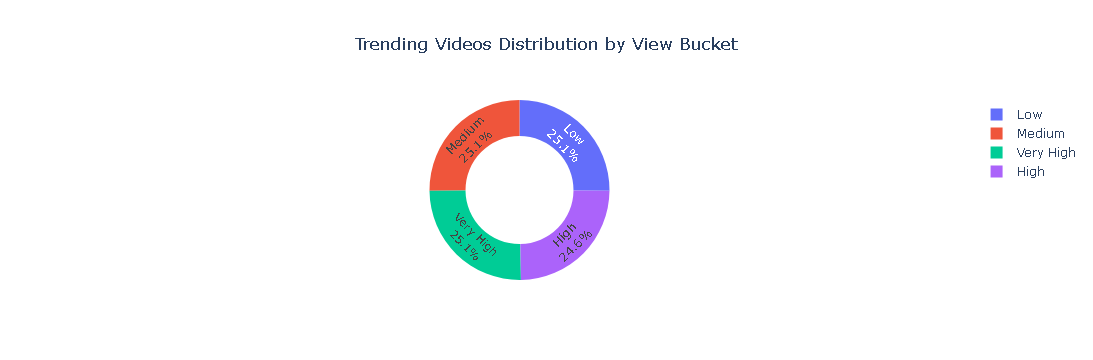

In [101]:
fig = px.pie(

    view_bucket_analysis,

    names="view_bucket",

    values="Total_Videos",

    hole=0.6,

    title="Trending Videos Distribution by View Bucket"

)

fig.update_traces(

    textposition="inside",

    textinfo="percent+label"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5

)

fig.show()

In [102]:
# ==========================================================
# Executive Summary
# Engagement Rate Distribution by Category
# ==========================================================

engagement_summary = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id", "count"),

        Average_Engagement=("engagement_rate", "mean"),

        Median_Engagement=("engagement_rate", "median"),

        Min_Engagement=("engagement_rate", "min"),

        Max_Engagement=("engagement_rate", "max"),

        Std_Engagement=("engagement_rate", "std"),

        Average_Views=("view_count", "mean"),

        Total_Views=("view_count", "sum")

    )

)

engagement_summary["View_Share_%"] = (

    engagement_summary["Total_Views"]

    /

    engagement_summary["Total_Views"].sum()

    * 100

)

engagement_summary["Rank"] = (

    engagement_summary["Average_Engagement"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

engagement_summary = (

    engagement_summary

    .round(2)

    .sort_values(

        "Average_Engagement",

        ascending=False

    )

)

engagement_summary

,category_name,Total_Videos,Average_Engagement,Median_Engagement,Min_Engagement,Max_Engagement,Std_Engagement,Average_Views,Total_Views,View_Share_%,Rank
0,Comedy,1,0.06,0.06,0.06,0.06,NaN,338216.00,338216,0.35,1
1,Entertainment,11,0.05,0.03,0.01,0.17,0.05,289908.00,3188988,3.26,2
6,Sports,1,0.05,0.05,0.05,0.05,NaN,169473.00,169473,0.17,3
5,People & Blogs,4,0.05,0.04,0.01,0.09,0.04,125947.25,503789,0.51,4
4,Music,24,0.04,0.04,0.00,0.11,0.03,1293831.75,31051962,31.72,5
3,Gaming,157,0.04,0.04,0.00,0.12,0.03,398899.06,62627153,63.98,6
2,Film & Animation,1,0.02,0.02,0.02,0.02,NaN,13512.00,13512,0.01,7


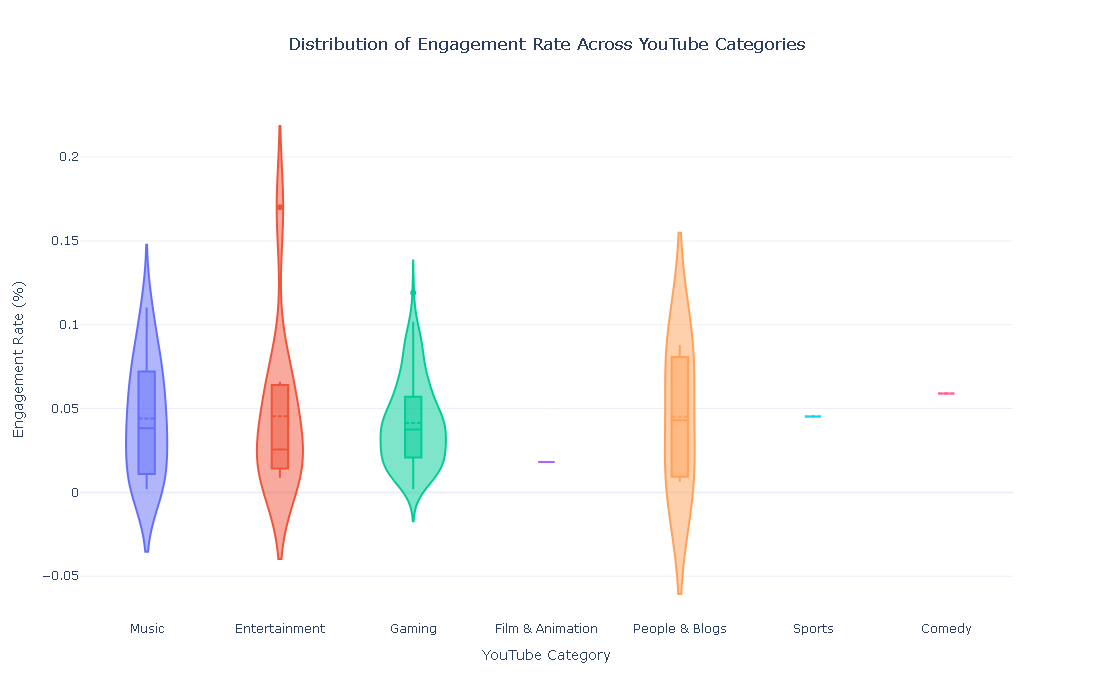

In [103]:
# ==========================================================
# Business Question:
# How is the engagement rate distributed
# across trending videos?
# ==========================================================

import plotly.express as px

fig = px.violin(

    df,

    y="engagement_rate",

    x="category_name",

    color="category_name",

    box=True,

    points="outliers",

    hover_data=[

        "view_count",

        "like_count",

        "comment_count",

        "duration_category"

    ],

    title="Distribution of Engagement Rate Across YouTube Categories"

)

fig.update_traces(

    meanline_visible=True

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="YouTube Category",

    yaxis_title="Engagement Rate (%)",

    showlegend=False

)

fig.show()

In [104]:
# ==========================================================
# Business Question:
# Which YouTube content categories consistently
# achieve the highest audience engagement?
# ==========================================================

category_engagement = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Like_Rate=("like_rate","mean"),

        Average_Comment_Rate=("comment_rate","mean"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum")

    )

)

category_engagement["Engagement_Score"] = (

    category_engagement["Total_Likes"]

    +

    category_engagement["Total_Comments"]

)

category_engagement["View_Share_%"] = (

    category_engagement["Total_Views"]

    /

    category_engagement["Total_Views"].sum()

    *100

).round(2)

category_engagement["Rank"] = (

    category_engagement["Average_Engagement"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

category_engagement = (

    category_engagement

    .round(2)

    .sort_values(

        "Average_Engagement",

        ascending=False

    )

)

category_engagement

,category_name,Total_Videos,Total_Views,Average_Views,Average_Engagement,Average_Like_Rate,Average_Comment_Rate,Total_Likes,Total_Comments,Engagement_Score,View_Share_%,Rank
0,Comedy,1,338216,338216.00,0.06,0.06,0.00,18851,1120,19971,0.35,1
1,Entertainment,11,3188988,289908.00,0.05,0.04,0.01,92292,10462,102754,3.26,2
6,Sports,1,169473,169473.00,0.05,0.04,0.00,7293,387,7680,0.17,3
5,People & Blogs,4,503789,125947.25,0.05,0.04,0.01,8261,1705,9966,0.51,4
4,Music,24,31051962,1293831.75,0.04,0.04,0.00,1822963,148272,1971235,31.72,5
3,Gaming,157,62627153,398899.06,0.04,0.04,0.00,2061537,128669,2190206,63.98,6
2,Film & Animation,1,13512,13512.00,0.02,0.02,0.00,225,19,244,0.01,7


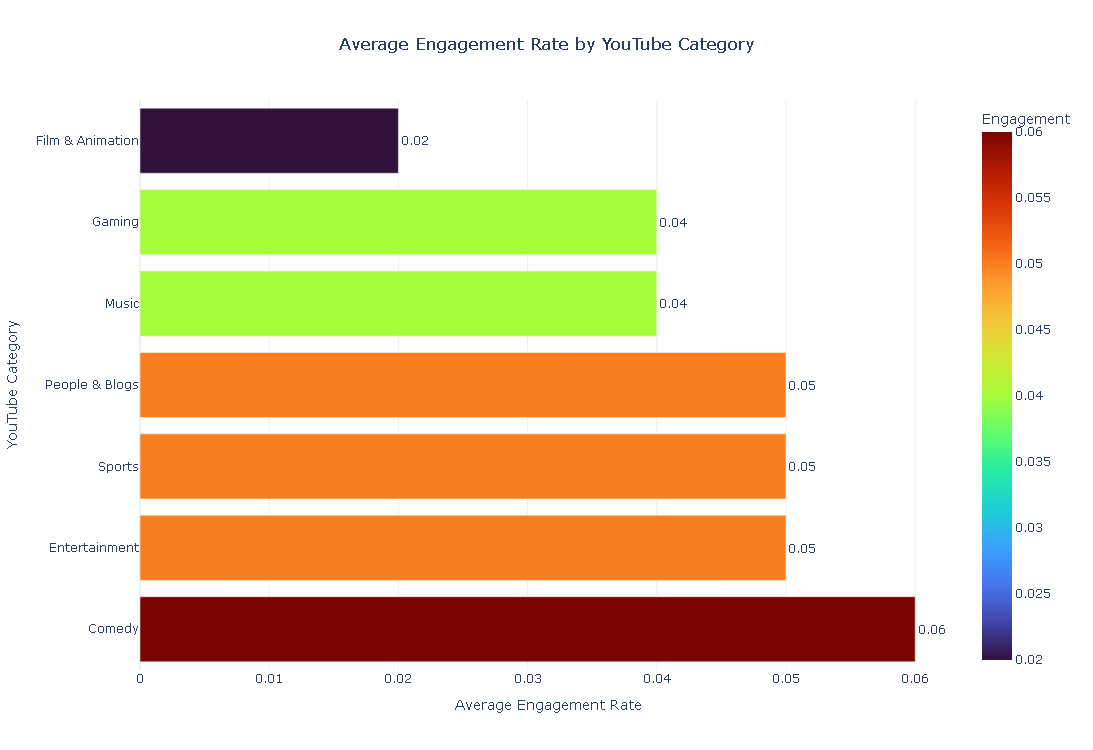

In [105]:
import plotly.express as px

fig = px.bar(

    category_engagement,

    x="Average_Engagement",

    y="category_name",

    orientation="h",

    color="Average_Engagement",

    text="Average_Engagement",

    color_continuous_scale="Turbo",

    hover_data=[

        "Total_Videos",

        "Average_Views",

        "View_Share_%",

        "Rank"

    ],

    title="Average Engagement Rate by YouTube Category"

)

fig.update_traces(

    texttemplate="%{text:.2f}",

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    height=750,

    title_x=0.5,

    xaxis_title="Average Engagement Rate",

    yaxis_title="YouTube Category",

    coloraxis_colorbar_title="Engagement"

)

fig.show()

In [106]:
import pandas as pd

executive_summary = pd.DataFrame({

    "KPI":[
        "Total Trending Videos",
        "Total Channels",
        "Total Categories",
        "Total Views",
        "Total Likes",
        "Total Comments",
        "Average Views",
        "Average Likes",
        "Average Comments",
        "Average Engagement Rate",
        "Average Like Rate",
        "Average Comment Rate",
        "Average Duration (Seconds)"
    ],

    "Value":[
        df["video_id"].count(),
        df["channel_title"].nunique(),
        df["category_name"].nunique(),
        df["view_count"].sum(),
        df["like_count"].sum(),
        df["comment_count"].sum(),
        round(df["view_count"].mean(), 2),
        round(df["like_count"].mean(), 2),
        round(df["comment_count"].mean(), 2),
        round(df["engagement_rate"].mean(), 2),
        round(df["like_rate"].mean(), 2),
        round(df["comment_rate"].mean(), 2),
        round(df["duration_seconds"].mean(), 2)
    ]

})   # <-- Ye missing tha

executive_summary

,KPI,Value
0,Total Trending Videos,199.00
1,Total Channels,199.00
2,Total Categories,7.00
3,Total Views,97893093.00
4,Total Likes,4011422.00
5,Total Comments,290634.00
6,Average Views,491925.09
7,Average Likes,20157.90
8,Average Comments,1460.47
9,Average Engagement Rate,0.04


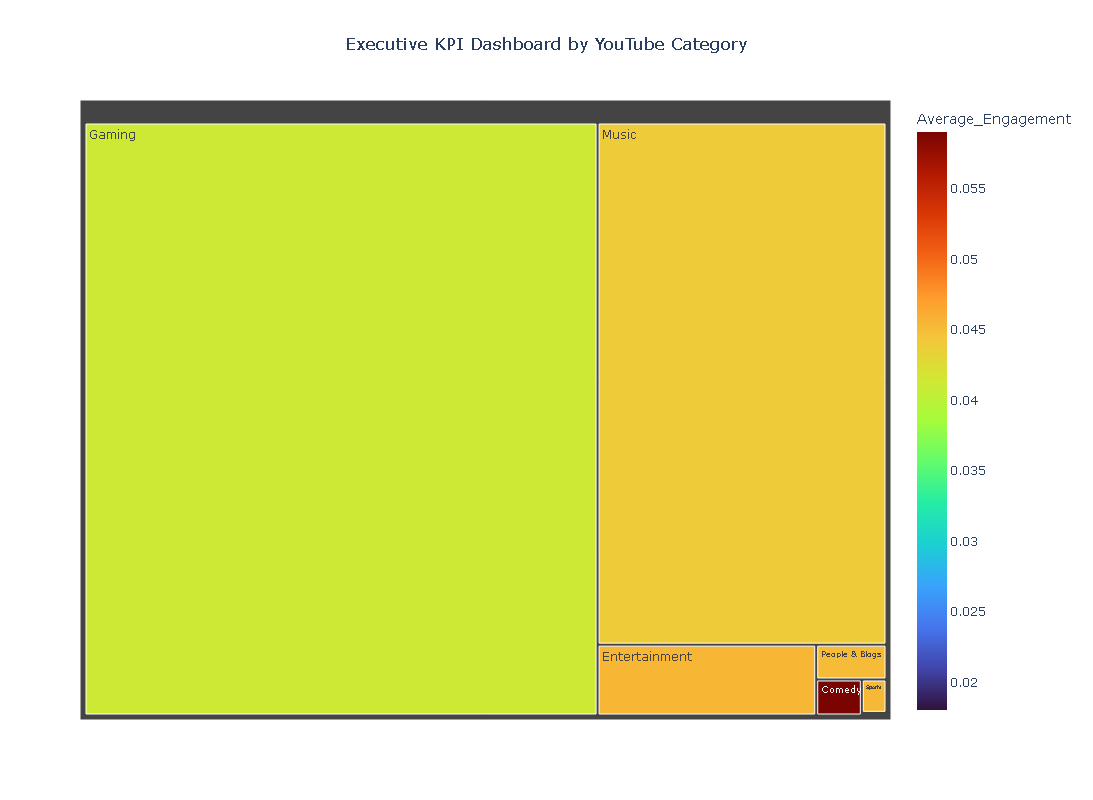

In [107]:
# ==========================================================
# Executive Dashboard
# ==========================================================

import plotly.express as px

dashboard = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Views=("view_count","sum"),

        Total_Likes=("like_count","sum"),

        Total_Comments=("comment_count","sum"),

        Average_Engagement=("engagement_rate","mean"),

        Total_Videos=("video_id","count")

    )

)

dashboard["Engagement_Score"] = (

    dashboard["Total_Likes"]

    +

    dashboard["Total_Comments"]

)

fig = px.treemap(

    dashboard,

    path=["category_name"],

    values="Total_Views",

    color="Average_Engagement",

    color_continuous_scale="Turbo",

    hover_data=[

        "Total_Videos",

        "Total_Likes",

        "Total_Comments",

        "Engagement_Score"

    ],

    title="Executive KPI Dashboard by YouTube Category"

)

fig.update_layout(

    template="plotly_white",

    height=800,

    title_x=0.5

)

fig.show()

In [108]:
# Hypothesis Testing Analysis
# ==========================================================
# Statistical Analysis #1
# Do YouTube categories have significantly different
# audience engagement rates?
# ==========================================================

import pandas as pd
from scipy.stats import f_oneway

# -------------------------------
# Business Summary
# -------------------------------

category_summary = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Median_Engagement=("engagement_rate","median"),

        Std_Engagement=("engagement_rate","std"),

        Average_Likes=("like_count","mean"),

        Average_Comments=("comment_count","mean")

    )

)

category_summary = (

    category_summary

    .assign(

        View_Share=lambda x:

        (x["Total_Views"]/x["Total_Views"].sum())*100,

        Engagement_Rank=lambda x:

        x["Average_Engagement"]

        .rank(

            ascending=False,

            method="dense"

        )

        .astype(int)

    )

)

category_summary = (

    category_summary

    .round(2)

    .sort_values(

        "Engagement_Rank"

    )

)

# -------------------------------
# One-Way ANOVA
# -------------------------------

groups = [

    group["engagement_rate"].dropna()

    for _, group in df.groupby("category_name")

]

F_statistic, p_value = f_oneway(*groups)

print(f"F Statistic : {F_statistic:.4f}")
print(f"P Value     : {p_value:.6f}")

alpha = 0.05

if p_value < alpha:

    print("\n✅ Reject H₀")
    print("Average engagement differs significantly across categories.")

else:

    print("\n❌ Fail to Reject H₀")
    print("No significant difference found.")

display(category_summary)

F Statistic : 0.2583
P Value     : 0.955421

❌ Fail to Reject H₀
No significant difference found.


,category_name,Total_Videos,Total_Views,Average_Views,Average_Engagement,Median_Engagement,Std_Engagement,Average_Likes,Average_Comments,View_Share,Engagement_Rank
0,Comedy,1,338216,338216.00,0.06,0.06,NaN,18851.00,1120.00,0.35,1
1,Entertainment,11,3188988,289908.00,0.05,0.03,0.05,8390.18,951.09,3.26,2
6,Sports,1,169473,169473.00,0.05,0.05,NaN,7293.00,387.00,0.17,3
5,People & Blogs,4,503789,125947.25,0.05,0.04,0.04,2065.25,426.25,0.51,4
4,Music,24,31051962,1293831.75,0.04,0.04,0.03,75956.79,6178.00,31.72,5
3,Gaming,157,62627153,398899.06,0.04,0.04,0.03,13130.81,819.55,63.98,6
2,Film & Animation,1,13512,13512.00,0.02,0.02,NaN,225.00,19.00,0.01,7


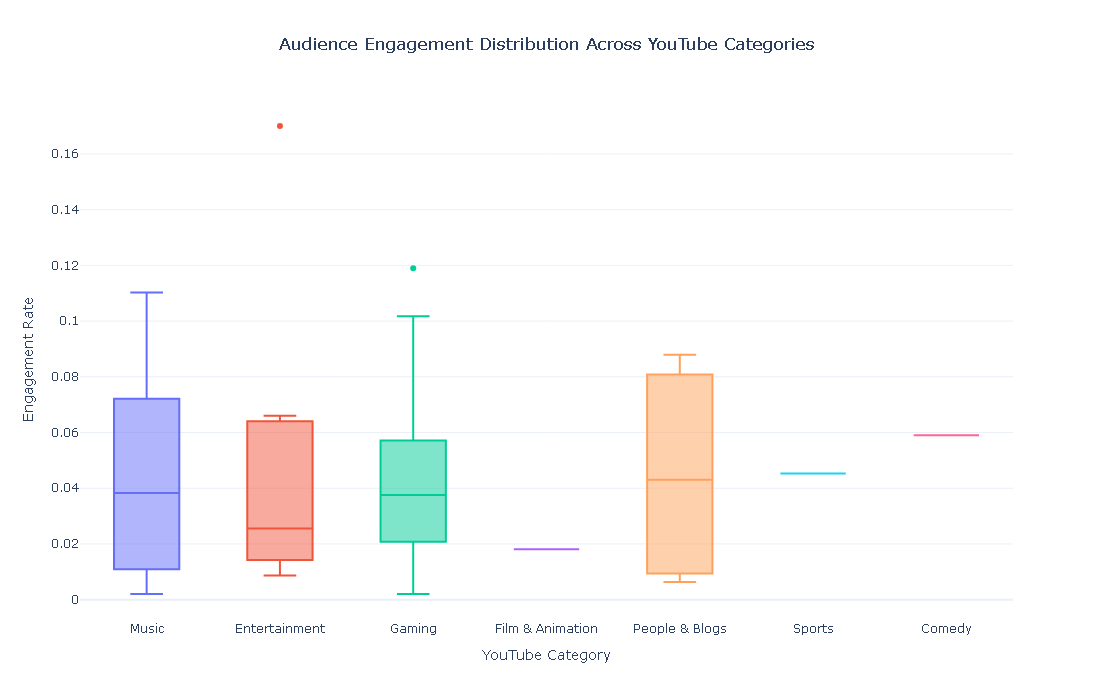

In [109]:
import plotly.express as px

fig = px.box(

    df,

    x="category_name",

    y="engagement_rate",

    color="category_name",

    points="outliers",

    title="Audience Engagement Distribution Across YouTube Categories"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="YouTube Category",

    yaxis_title="Engagement Rate",

    showlegend=False

)

fig.show()

In [110]:
# ==========================================================
# Statistical Analysis #2
# Does upload session influence audience engagement?
# ==========================================================

import pandas as pd
from scipy.stats import kruskal

# ----------------------------------------------------------
# Business Summary using Pivot Table
# ----------------------------------------------------------

session_summary = pd.pivot_table(

    df,

    index="publish_session",

    values=[

        "view_count",

        "engagement_rate",

        "like_count",

        "comment_count"

    ],

    aggfunc={

        "view_count":["count","sum","mean","median"],

        "engagement_rate":["mean","median","std"],

        "like_count":"mean",

        "comment_count":"mean"

    }

)

session_summary.columns=[

    "_".join(col).strip()

    for col in session_summary.columns.values

]

session_summary=session_summary.reset_index()

session_summary=session_summary.rename(columns={

    "view_count_count":"Total_Videos",

    "view_count_sum":"Total_Views",

    "view_count_mean":"Average_Views",

    "view_count_median":"Median_Views",

    "engagement_rate_mean":"Average_Engagement",

    "engagement_rate_median":"Median_Engagement",

    "engagement_rate_std":"Std_Engagement",

    "like_count_mean":"Average_Likes",

    "comment_count_mean":"Average_Comments"

})

session_summary["View_Share_%"]=(

    session_summary["Total_Views"]

    /

    session_summary["Total_Views"].sum()

    *100

)

session_summary["Engagement_Rank"]=(

    session_summary["Average_Engagement"]

    .rank(

        ascending=False,

        method="dense"

    )

    .astype(int)

)

session_summary=session_summary.round(2)

session_summary=session_summary.sort_values(

    "Engagement_Rank"

)

# ----------------------------------------------------------
# Kruskal-Wallis Test
# ----------------------------------------------------------

groups=[

    group["engagement_rate"].dropna()

    for _,group in df.groupby("publish_session")

]

H_statistic,p_value=kruskal(*groups)

print(f"H Statistic : {H_statistic:.4f}")

print(f"P Value     : {p_value:.6f}")

alpha=0.05

if p_value<alpha:

    print("\n✅ Reject H₀")
    print("Upload session significantly affects engagement.")

else:

    print("\n❌ Fail to Reject H₀")
    print("No significant difference between upload sessions.")

session_summary

H Statistic : 9.4174
P Value     : 0.024226

✅ Reject H₀
Upload session significantly affects engagement.


,publish_session,Average_Comments,Average_Engagement,Median_Engagement,Std_Engagement,Average_Likes,Total_Videos,Average_Views,Median_Views,Total_Views,View_Share_%,Engagement_Rank
1,Evening,711.25,0.05,0.05,0.03,10018.58,55,285085.33,121728.0,15679693,16.02,1
0,Afternoon,2807.70,0.04,0.04,0.02,39971.80,69,882612.38,158649.0,60900254,62.21,2
3,Night,740.92,0.04,0.04,0.03,10104.79,52,292907.33,138200.0,15231181,15.56,3
2,Morning,837.22,0.03,0.02,0.03,7691.17,23,264433.26,170404.0,6081965,6.21,4


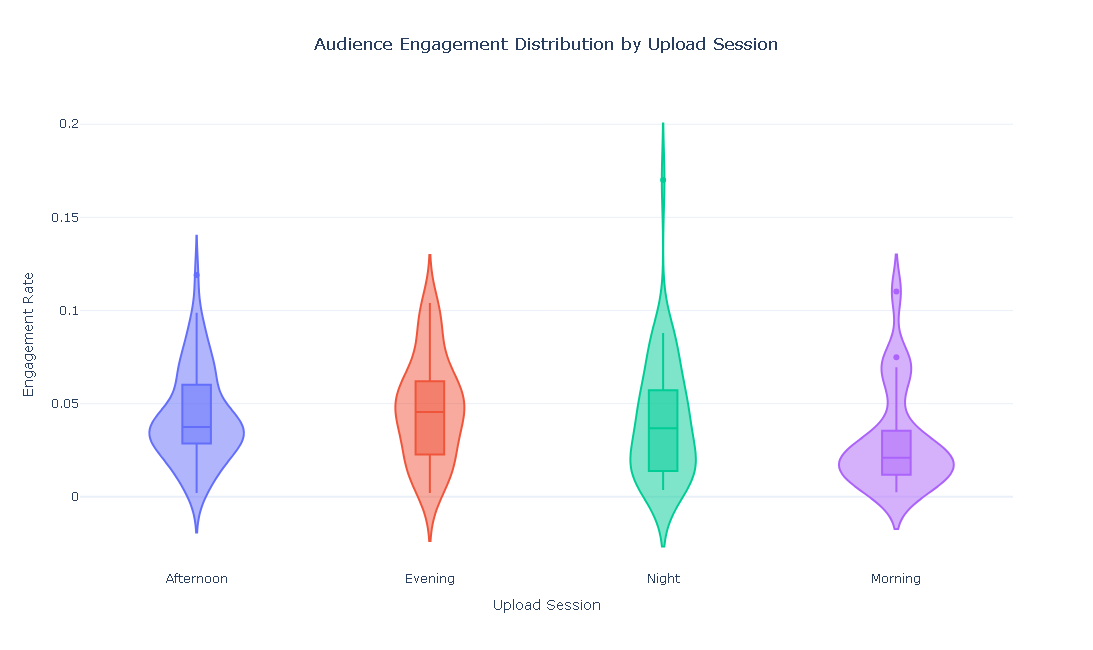

In [111]:
import plotly.express as px

fig=px.violin(

    df,

    x="publish_session",

    y="engagement_rate",

    color="publish_session",

    box=True,

    points="outliers",

    title="Audience Engagement Distribution by Upload Session"

)

fig.update_layout(

    template="plotly_white",

    height=650,

    title_x=0.5,

    xaxis_title="Upload Session",

    yaxis_title="Engagement Rate",

    showlegend=False

)

fig.show()

In [112]:
# ==========================================================
# Statistical Analysis #3
# Upload Session vs Duration Category
# ==========================================================

import pandas as pd
from scipy.stats import chi2_contingency

# ----------------------------------------------------------
# Crosstab Summary
# ----------------------------------------------------------

cross_tab = pd.crosstab(

    index=df["publish_session"],

    columns=df["duration_category"],

    margins=True,

    normalize=False

)

cross_tab

duration_category,Long,Medium,All
publish_session,,,
Afternoon,54,15,69
Evening,48,7,55
Morning,20,3,23
Night,43,9,52
All,165,34,199


In [113]:
# ----------------------------------------------------------
# Row-wise Percentage
# ----------------------------------------------------------

cross_percentage = (

    pd.crosstab(

        index=df["publish_session"],

        columns=df["duration_category"],

        normalize="index"

    )

    *100

).round(2)

cross_percentage

duration_category,Long,Medium
publish_session,,
Afternoon,78.26,21.74
Evening,87.27,12.73
Morning,86.96,13.04
Night,82.69,17.31


In [114]:
# ----------------------------------------------------------
# Chi-Square Test
# ----------------------------------------------------------

contingency = pd.crosstab(

    df["publish_session"],

    df["duration_category"]

)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-Square Statistic : {chi2:.4f}")
print(f"Degrees of Freedom   : {dof}")
print(f"P-value              : {p_value:.6f}")

alpha = 0.05

if p_value < alpha:

    print("\n✅ Reject H₀")
    print("Upload session and duration category are significantly associated.")

else:

    print("\n❌ Fail to Reject H₀")
    print("No significant association exists.")

Chi-Square Statistic : 2.0593
Degrees of Freedom   : 3
P-value              : 0.560186

❌ Fail to Reject H₀
No significant association exists.


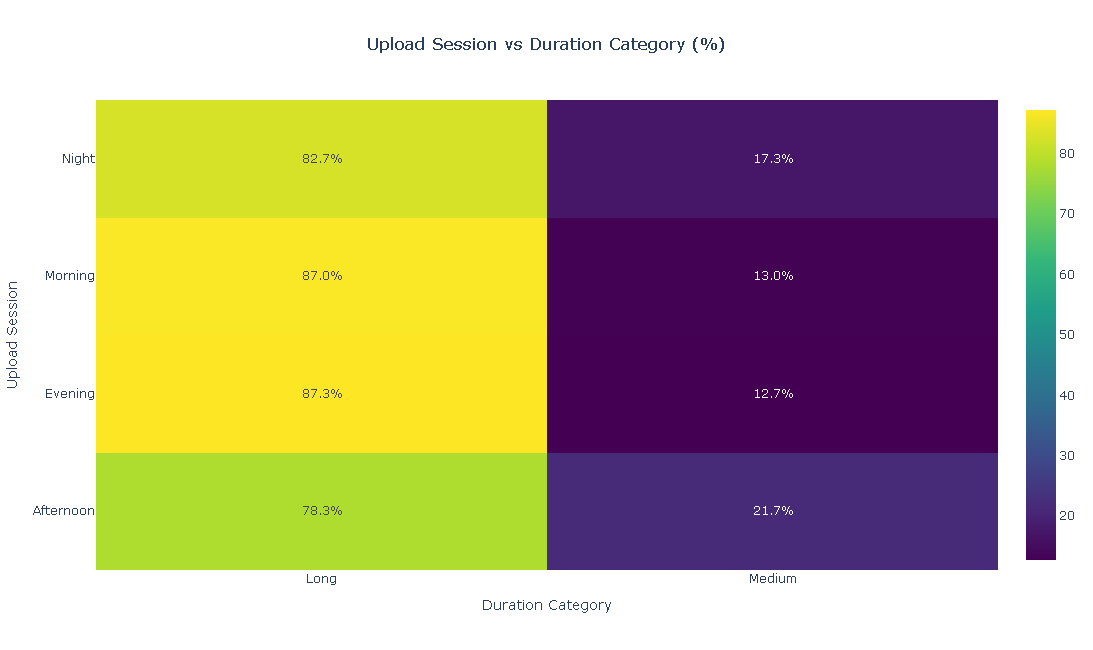

In [115]:
import plotly.graph_objects as go

fig = go.Figure(

    data=go.Heatmap(

        z=cross_percentage.values,

        x=cross_percentage.columns,

        y=cross_percentage.index,

        colorscale="Viridis",

        text=cross_percentage.values,

        texttemplate="%{text:.1f}%",

        hovertemplate=

        "<b>Session:</b> %{y}<br>" +

        "<b>Duration:</b> %{x}<br>" +

        "<b>Percentage:</b> %{z:.2f}%<extra></extra>"

    )

)

fig.update_layout(

    title="Upload Session vs Duration Category (%)",

    template="plotly_white",

    title_x=0.5,

    height=650,

    xaxis_title="Duration Category",

    yaxis_title="Upload Session"

)

fig.show()

In [116]:
# ==========================================================
# Statistical Analysis #4
# Caption vs No Caption Performance
# ==========================================================

import pandas as pd
from scipy.stats import mannwhitneyu

# ----------------------------------------------------------
# Business Summary
# ----------------------------------------------------------

caption_summary = (

    df

    .groupby("has_caption", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Median_Engagement=("engagement_rate","median"),

        Average_Likes=("like_count","mean"),

        Average_Comments=("comment_count","mean")

    )

)

caption_summary = (

    caption_summary

    .assign(

        View_Share=lambda x:

        (x["Total_Views"] /

        x["Total_Views"].sum())*100,

        Engagement_Rank=lambda x:

        x["Average_Engagement"]

        .rank(

            ascending=False,

            method="dense"

        )

        .astype(int)

    )

)

caption_summary = (

    caption_summary

    .round(2)

    .sort_values(

        "Engagement_Rank"

    )

)

caption_summary

,has_caption,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Median_Engagement,Average_Likes,Average_Comments,View_Share,Engagement_Rank
1,1,11,44074879,4006807.18,485755.0,0.07,0.08,193518.00,11994.18,45.02,1
0,0,188,53818214,286267.10,141170.0,0.04,0.04,10014.49,844.14,54.98,2


In [117]:
caption_pivot = pd.pivot_table(

    df,

    index="has_caption",

    values=[

        "view_count",

        "engagement_rate",

        "like_count",

        "comment_count"

    ],

    aggfunc={

        "view_count":["mean","median","sum"],

        "engagement_rate":["mean","std"],

        "like_count":"mean",

        "comment_count":"mean"

    }

)

caption_pivot

comment_count engagement_rate               like_count  \
                     mean            mean       std           mean   
has_caption                                                          
0              844.138298        0.040344  0.026685   10014.489362   
1            11994.181818        0.069095  0.031736  193518.000000   

               view_count                      
                     mean    median       sum  
has_caption                                    
0            2.862671e+05  141170.0  53818214  
1            4.006807e+06  485755.0  44074879

In [118]:
caption_yes = df.loc[
    df["has_caption"]==True,
    "engagement_rate"
].dropna()

caption_no = df.loc[
    df["has_caption"]==False,
    "engagement_rate"
].dropna()

u_statistic,p_value = mannwhitneyu(

    caption_yes,

    caption_no,

    alternative="two-sided"

)

print(f"U Statistic : {u_statistic:.2f}")

print(f"P Value     : {p_value:.6f}")

alpha=0.05

if p_value<alpha:

    print("\n✅ Reject H₀")

    print("Captions significantly affect engagement.")

else:

    print("\n❌ Fail to Reject H₀")

    print("Captions do not significantly affect engagement.")

U Statistic : 1591.00
P Value     : 0.002722

✅ Reject H₀
Captions significantly affect engagement.


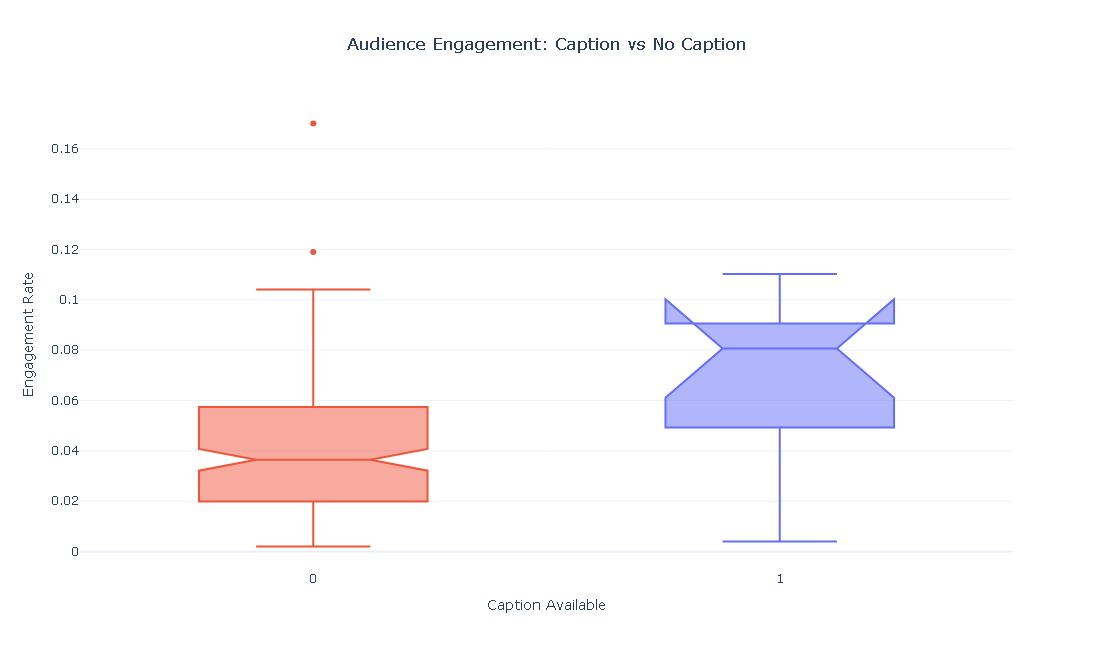

In [119]:
import plotly.express as px

fig = px.box(

    df,

    x="has_caption",

    y="engagement_rate",

    color="has_caption",

    points="outliers",

    notched=True,

    title="Audience Engagement: Caption vs No Caption"

)

fig.update_layout(

    template="plotly_white",

    title_x=0.5,

    height=650,

    xaxis_title="Caption Available",

    yaxis_title="Engagement Rate",

    showlegend=False

)

fig.show()

In [121]:
# ==========================================================
# Business Summary
# ==========================================================

quality_summary = (

    df

    .groupby("definition", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Std_Views=("view_count","std"),

        Average_Engagement=("engagement_rate","mean"),

        Median_Engagement=("engagement_rate","median"),

        Std_Engagement=("engagement_rate","std"),

        Average_Likes=("like_count","mean"),

        Average_Comments=("comment_count","mean")

    )

)

quality_summary["View_Share_%"]=(

    quality_summary["Total_Views"]

    /

    quality_summary["Total_Views"].sum()

    *100

)

quality_summary["Performance_Rank"]=(

    quality_summary["Average_Views"]

    .rank(

        ascending=False,

        method="dense"

    )

)

quality_summary=quality_summary.round(2)

quality_summary

,definition,Total_Videos,Total_Views,Average_Views,Median_Views,Std_Views,Average_Engagement,Median_Engagement,Std_Engagement,Average_Likes,Average_Comments,View_Share_%,Performance_Rank
0,hd,197,97636402,495616.25,144310.0,1885807.36,0.04,0.04,0.03,20301.72,1471.4,99.74,1.0
1,sd,2,256691,128345.50,128345.5,9135.11,0.05,0.05,0.01,5991.50,384.5,0.26,2.0


In [122]:
# ==========================================================
# Pivot Summary
# ==========================================================

quality_pivot = pd.pivot_table(

    df,

    index="definition",

    values=[

        "view_count",

        "engagement_rate",

        "like_count",

        "comment_count"

    ],

    aggfunc={

        "view_count":["mean","median","std","sum"],

        "engagement_rate":["mean","median","std"],

        "like_count":"mean",

        "comment_count":"mean"

    }

)

quality_pivot=quality_pivot.round(2)

quality_pivot

comment_count engagement_rate              like_count view_count  \
                    mean            mean median   std       mean       mean   
definition                                                                    
hd                1471.4            0.04   0.04  0.03   20301.72  495616.25   
sd                 384.5            0.05   0.05  0.01    5991.50  128345.50   

                                            
              median         std       sum  
definition                                  
hd          144310.0  1885807.36  97636402  
sd          128345.5     9135.11    256691

In [123]:
# ==========================================================
# Independent t-Test
# ==========================================================

from scipy.stats import ttest_ind

hd = df.loc[

    df["definition"]=="hd",

    "view_count"

].dropna()

sd = df.loc[

    df["definition"]=="sd",

    "view_count"

].dropna()

t_stat,p_value = ttest_ind(

    hd,

    sd,

    equal_var=False

)

print(f"T Statistic : {t_stat:.4f}")

print(f"P Value     : {p_value:.6f}")

alpha=0.05

if p_value<alpha:

    print("\n✅ Reject H₀")

    print("HD videos significantly outperform SD videos.")

else:

    print("\n❌ Fail to Reject H₀")

    print("No statistically significant difference.")

T Statistic : 2.7304
P Value     : 0.006901

✅ Reject H₀
HD videos significantly outperform SD videos.


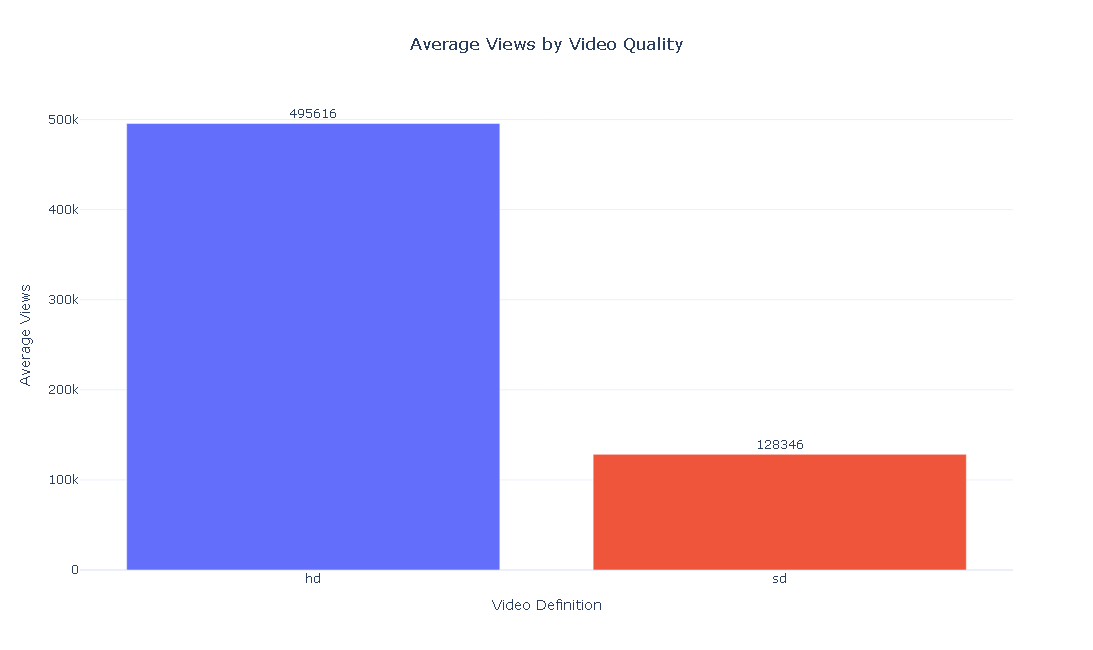

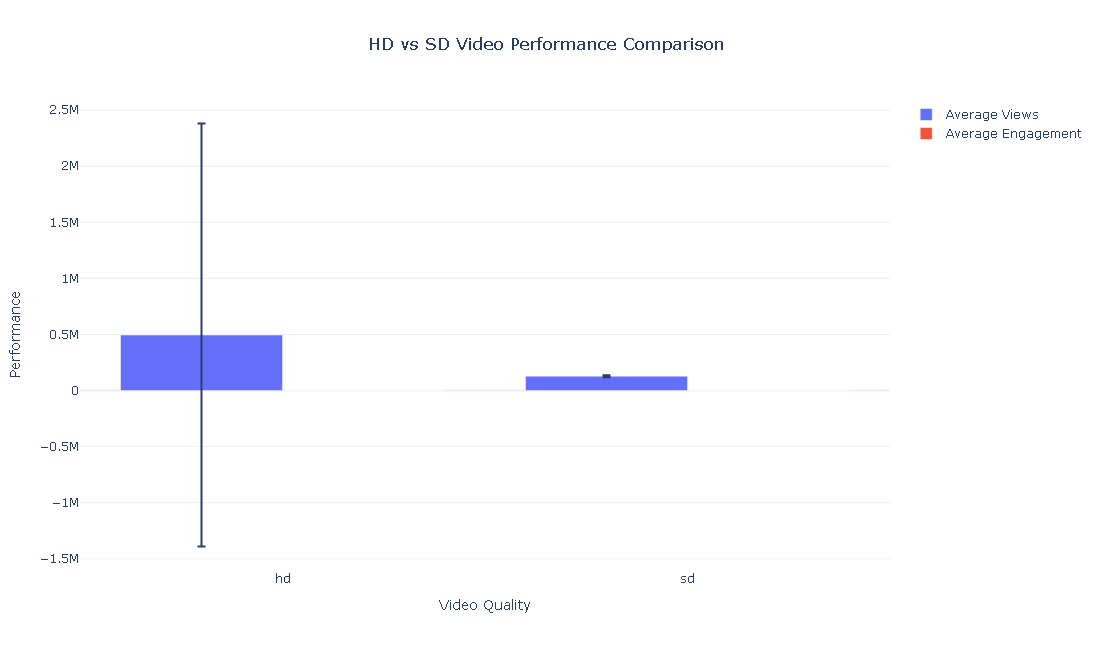

In [125]:
import plotly.express as px

fig = px.bar(

    quality_summary,

    x="definition",

    y="Average_Views",

    color="definition",

    text="Average_Views",

    title="Average Views by Video Quality"

)

fig.update_traces(

    texttemplate="%{text:.0f}",

    textposition="outside"

)

fig.update_layout(

    template="plotly_white",

    height=650,

    title_x=0.5,

    xaxis_title="Video Definition",

    yaxis_title="Average Views",

    showlegend=False

)

fig.show()

import plotly.graph_objects as go

fig=go.Figure()

fig.add_trace(

    go.Bar(

        name="Average Views",

        x=quality_summary["definition"],

        y=quality_summary["Average_Views"],

        error_y=dict(

            type="data",

            array=quality_summary["Std_Views"]

        )

    )

)

fig.add_trace(

    go.Bar(

        name="Average Engagement",

        x=quality_summary["definition"],

        y=quality_summary["Average_Engagement"]

    )

)

fig.update_layout(

    barmode="group",

    template="plotly_white",

    height=650,

    title="HD vs SD Video Performance Comparison",

    title_x=0.5,

    xaxis_title="Video Quality",

    yaxis_title="Performance"

)

fig.show()

In [126]:
# ==========================================================
# Statistical Analysis #6
# Which publish day has the highest engagement consistency?
# ==========================================================

import pandas as pd
from scipy.stats import levene

day_summary = (

    df

    .groupby("publish_day_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Total_Views=("view_count","sum"),

        Average_Views=("view_count","mean"),

        Median_Views=("view_count","median"),

        Average_Engagement=("engagement_rate","mean"),

        Median_Engagement=("engagement_rate","median"),

        Std_Engagement=("engagement_rate","std"),

        Average_Likes=("like_count","mean"),

        Average_Comments=("comment_count","mean")

    )

)

# Coefficient of Variation (Consistency Metric)
day_summary["CV_%"]=(

    day_summary["Std_Engagement"]

    /

    day_summary["Average_Engagement"]

    *100

)

day_summary["Consistency_Rank"]=(

    day_summary["CV_%"]

    .rank(

        ascending=True,

        method="dense"

    )

)

# Arrange weekdays correctly
day_order=[

    "Monday",

    "Tuesday",

    "Wednesday",

    "Thursday",

    "Friday",

    "Saturday",

    "Sunday"

]

day_summary["publish_day_name"]=pd.Categorical(

    day_summary["publish_day_name"],

    categories=day_order,

    ordered=True

)

day_summary=(

    day_summary

    .sort_values("publish_day_name")

    .round(2)

)

day_summary

,publish_day_name,Total_Videos,Total_Views,Average_Views,Median_Views,Average_Engagement,Median_Engagement,Std_Engagement,Average_Likes,Average_Comments,CV_%,Consistency_Rank
1,Monday,49,8487539,173215.08,84202.0,0.03,0.02,0.03,4056.39,283.94,92.19,4.0
4,Tuesday,1,33799,33799.00,33799.0,0.01,0.01,NaN,391.00,8.00,NaN,NaN
5,Wednesday,1,55223,55223.00,55223.0,0.00,0.00,NaN,216.00,7.00,NaN,NaN
0,Friday,12,24540531,2045044.25,866197.0,0.04,0.05,0.03,110145.42,8744.25,66.97,3.0
2,Saturday,23,35726759,1553337.35,553624.0,0.04,0.03,0.02,48492.39,2071.00,53.39,1.0
3,Sunday,113,29049242,257072.94,134805.0,0.05,0.04,0.03,12167.98,1098.60,55.97,2.0


In [127]:
# ==========================================================
# Levene Test
# ==========================================================

groups=[

    group["engagement_rate"].dropna()

    for _,group in df.groupby("publish_day_name")

]

statistic,p_value=levene(*groups)

print(f"Levene Statistic : {statistic:.4f}")

print(f"P Value          : {p_value:.6f}")

alpha=0.05

if p_value>alpha:

    print("\n✅ Equal variance across publish days.")

else:

    print("\n❌ Variance differs across publish days.")

Levene Statistic : 1.0920
P Value          : 0.366142

✅ Equal variance across publish days.


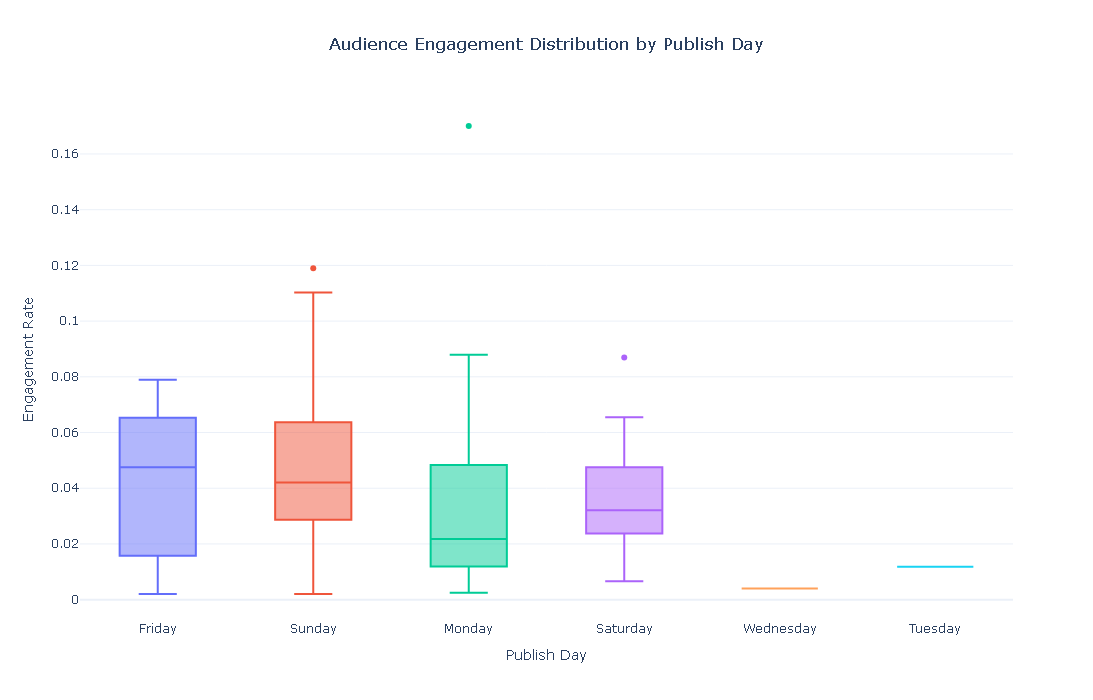

In [128]:
import plotly.express as px

fig=px.box(

    df,

    x="publish_day_name",

    y="engagement_rate",

    color="publish_day_name",

    points="outliers",

    title="Audience Engagement Distribution by Publish Day"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="Publish Day",

    yaxis_title="Engagement Rate",

    showlegend=False

)

fig.show()

In [129]:
# ==========================================================
# Statistical Analysis #7
# Is title length correlated with engagement?
# ==========================================================

import pandas as pd
from scipy.stats import spearmanr

# ----------------------------------------------------------
# Create Title Length Buckets
# ----------------------------------------------------------

title_analysis = df.copy()

title_analysis["Title_Group"] = pd.qcut(

    title_analysis["title_length"],

    q=5,

    labels=[

        "Very Short",

        "Short",

        "Medium",

        "Long",

        "Very Long"

    ]

)

# ----------------------------------------------------------
# Business Summary
# ----------------------------------------------------------

title_summary = (

    title_analysis

    .groupby("Title_Group", observed=False, as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Average_Title_Length=("title_length","mean"),

        Average_Views=("view_count","mean"),

        Average_Engagement=("engagement_rate","mean"),

        Average_Likes=("like_count","mean"),

        Average_Comments=("comment_count","mean")

    )

)

title_summary["Engagement_Rank"]=(

    title_summary["Average_Engagement"]

    .rank(

        ascending=False,

        method="dense"

    )

)

title_summary=title_summary.round(2)

title_summary

,Title_Group,Total_Videos,Average_Title_Length,Average_Views,Average_Engagement,Average_Likes,Average_Comments,Engagement_Rank
0,Very Short,41,22.90,468630.85,0.04,21888.24,1856.61,2.0
1,Short,39,35.13,365727.05,0.04,13081.10,986.15,5.0
2,Medium,42,42.14,999747.76,0.05,40533.07,2632.98,1.0
3,Long,37,49.76,292376.97,0.04,10832.68,887.84,4.0
4,Very Long,40,74.00,290212.97,0.04,12516.08,815.45,3.0


In [130]:
# ==========================================================
# Spearman Correlation
# ==========================================================

corr,p_value=spearmanr(

    df["title_length"],

    df["engagement_rate"]

)

print(f"Spearman Correlation : {corr:.4f}")

print(f"P-value              : {p_value:.6f}")

alpha=0.05

if p_value<alpha:

    print("\n✅ Reject H₀")

    print("Title length is significantly correlated with engagement.")

else:

    print("\n❌ Fail to Reject H₀")

    print("No statistically significant correlation.")

Spearman Correlation : -0.0197
P-value              : 0.782949

❌ Fail to Reject H₀
No statistically significant correlation.


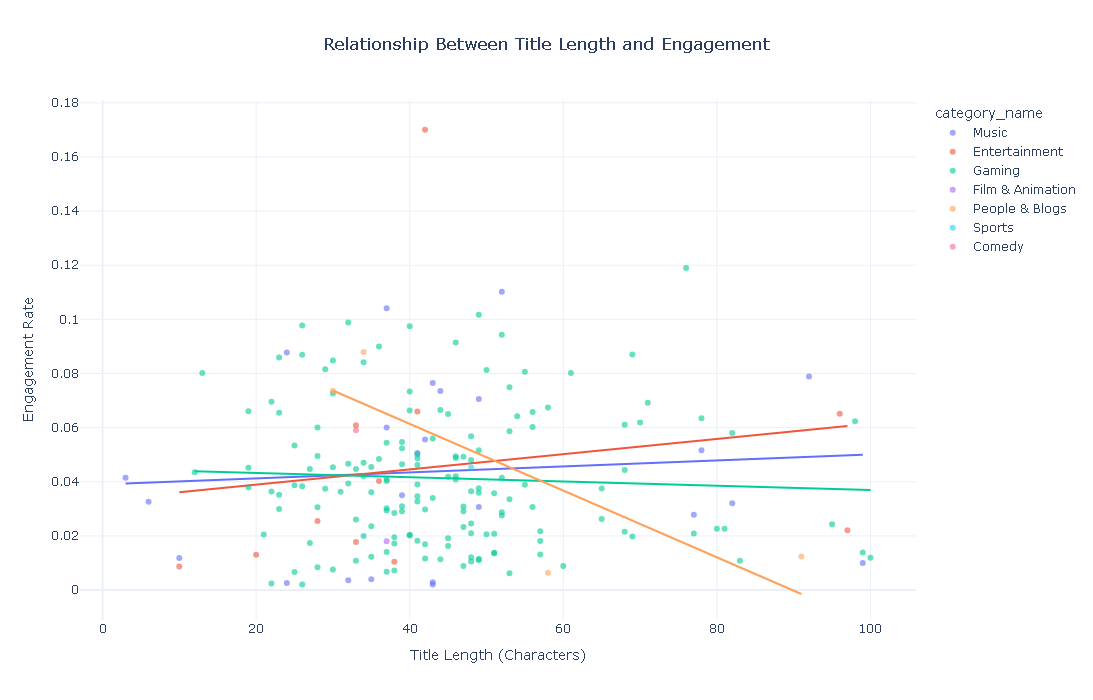

In [131]:
import plotly.express as px

fig = px.scatter(

    df,

    x="title_length",

    y="engagement_rate",

    color="category_name",

    trendline="ols",

    opacity=0.60,

    hover_data=[

        "title",

        "channel_title",

        "view_count"

    ],

    title="Relationship Between Title Length and Engagement"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="Title Length (Characters)",

    yaxis_title="Engagement Rate"

)

fig.show()

In [132]:
# ==========================================================
# Statistical Analysis #8
# Are Views and Likes Strongly Related?
# ==========================================================

import pandas as pd
from scipy.stats import pearsonr

# ----------------------------------------------------------
# Correlation Matrix
# ----------------------------------------------------------

correlation_summary = (

    df[[

        "view_count",

        "like_count",

        "comment_count",

        "engagement_rate"

    ]]

    .corr(method="pearson")

)

display(correlation_summary)

# ----------------------------------------------------------
# Category Summary
# ----------------------------------------------------------

category_views = (

    df

    .groupby("category_name", as_index=False)

    .agg(

        Total_Videos=("video_id","count"),

        Average_Views=("view_count","mean"),

        Average_Likes=("like_count","mean"),

        Average_Comments=("comment_count","mean"),

        Average_Engagement=("engagement_rate","mean")

    )

)

category_views["Like_to_View_Ratio"]=(

    category_views["Average_Likes"]

    /

    category_views["Average_Views"]

    *100

)

category_views=category_views.round(2)

category_views

,view_count,like_count,comment_count,engagement_rate
view_count,1.000000,0.912630,0.633582,0.019155
like_count,0.912630,1.000000,0.883307,0.149746
comment_count,0.633582,0.883307,1.000000,0.209527
engagement_rate,0.019155,0.149746,0.209527,1.000000


,category_name,Total_Videos,Average_Views,Average_Likes,Average_Comments,Average_Engagement,Like_to_View_Ratio
0,Comedy,1,338216.00,18851.00,1120.00,0.06,5.57
1,Entertainment,11,289908.00,8390.18,951.09,0.05,2.89
2,Film & Animation,1,13512.00,225.00,19.00,0.02,1.67
3,Gaming,157,398899.06,13130.81,819.55,0.04,3.29
4,Music,24,1293831.75,75956.79,6178.00,0.04,5.87
5,People & Blogs,4,125947.25,2065.25,426.25,0.05,1.64
6,Sports,1,169473.00,7293.00,387.00,0.05,4.30


In [133]:
# ==========================================================
# Pearson Correlation
# ==========================================================

corr,p_value = pearsonr(

    df["view_count"],

    df["like_count"]

)

print(f"Pearson Correlation : {corr:.4f}")

print(f"P-value             : {p_value:.6f}")

alpha=0.05

if p_value<alpha:

    print("\n✅ Reject H₀")

    print("Views and Likes are significantly correlated.")

else:

    print("\n❌ Fail to Reject H₀")

    print("No significant correlation.")

Pearson Correlation : 0.9126
P-value             : 0.000000

✅ Reject H₀
Views and Likes are significantly correlated.


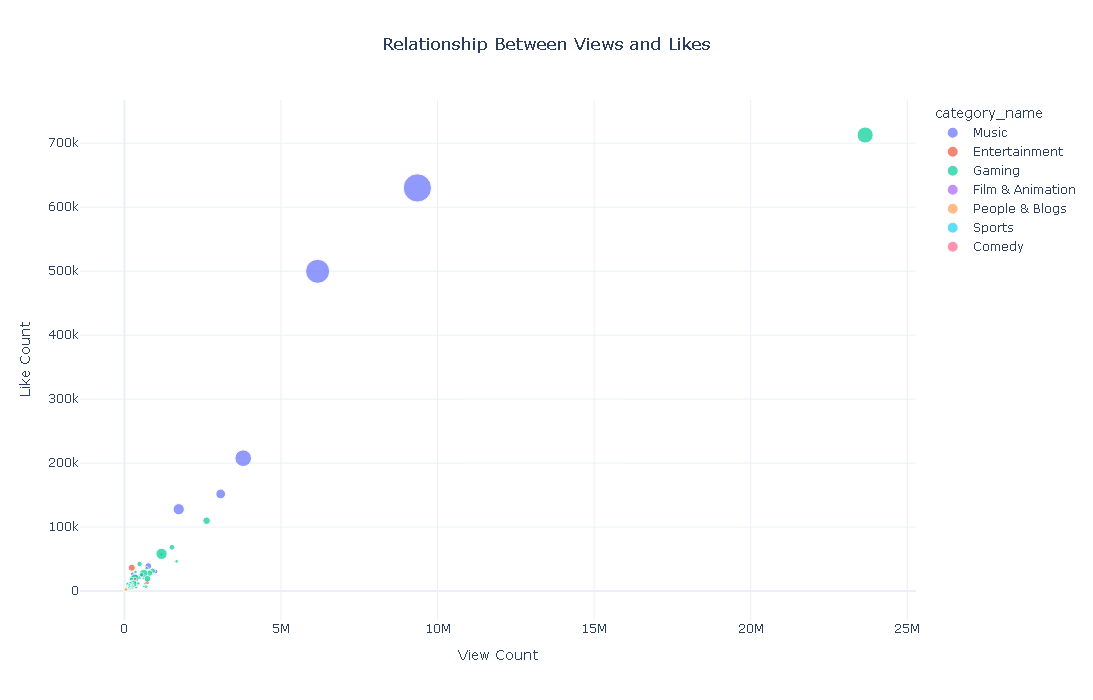

In [134]:
import plotly.express as px

fig=px.scatter(

    df,

    x="view_count",

    y="like_count",

    color="category_name",

    size="comment_count",

    hover_name="title",

    opacity=0.70,

    title="Relationship Between Views and Likes"

)

fig.update_layout(

    template="plotly_white",

    height=700,

    title_x=0.5,

    xaxis_title="View Count",

    yaxis_title="Like Count"

)

fig.show()

In [135]:
# ==========================================================
# Statistical Analysis #9
# Which duration category performs best?
# ==========================================================

import pandas as pd
from scipy.stats import kruskal

# ----------------------------------------------------------
# Pivot Table Summary
# ----------------------------------------------------------

duration_summary = pd.pivot_table(

    df,

    index="duration_category",

    values=[

        "view_count",
        "like_count",
        "comment_count",
        "engagement_rate"

    ],

    aggfunc={

        "view_count":["count","mean","median"],

        "like_count":"mean",

        "comment_count":"mean",

        "engagement_rate":["mean","median","std"]

    }

)

# Flatten MultiIndex Columns
duration_summary.columns=[

    "_".join(col)

    for col in duration_summary.columns

]

duration_summary=duration_summary.reset_index()

# Rename Columns
duration_summary=duration_summary.rename(columns={

    "view_count_count":"Total_Videos",

    "view_count_mean":"Average_Views",

    "view_count_median":"Median_Views",

    "like_count_mean":"Average_Likes",

    "comment_count_mean":"Average_Comments",

    "engagement_rate_mean":"Average_Engagement",

    "engagement_rate_median":"Median_Engagement",

    "engagement_rate_std":"Std_Engagement"

})

duration_summary["Performance_Rank"]=(

    duration_summary["Average_Engagement"]

    .rank(

        ascending=False,

        method="dense"

    )

)

duration_summary=duration_summary.round(2)

duration_summary

,duration_category,Average_Comments,Average_Engagement,Median_Engagement,Std_Engagement,Average_Likes,Total_Videos,Average_Views,Median_Views,Performance_Rank
0,Long,813.28,0.04,0.04,0.03,12567.78,165,376156.05,132427.0,2.0
1,Medium,4601.24,0.04,0.04,0.03,56992.29,34,1053745.44,345037.5,1.0


In [136]:
# ==========================================================
# Kruskal-Wallis Test
# ==========================================================

groups=[

    group["engagement_rate"].dropna()

    for _,group in df.groupby("duration_category")

]

H,p_value=kruskal(*groups)

print(f"H Statistic : {H:.4f}")

print(f"P-value     : {p_value:.6f}")

alpha=0.05

if p_value<alpha:

    print("\n✅ Reject H₀")

    print("Duration categories have significantly different engagement.")

else:

    print("\n❌ Fail to Reject H₀")

    print("No significant engagement difference.")

H Statistic : 0.0719
P-value     : 0.788569

❌ Fail to Reject H₀
No significant engagement difference.


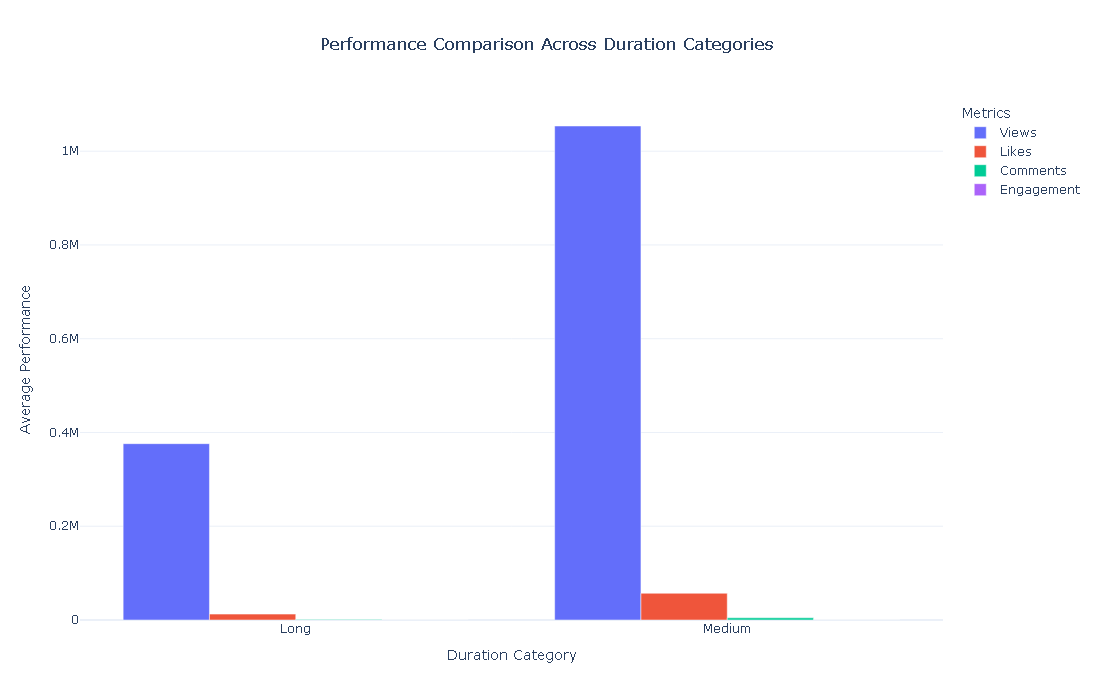

In [140]:
import plotly.graph_objects as go

metrics = [
    "Average_Views",
    "Average_Likes",
    "Average_Comments",
    "Average_Engagement"
]

fig = go.Figure()

for metric in metrics:

    fig.add_trace(
        go.Bar(
            x=duration_summary["duration_category"],
            y=duration_summary[metric],
            name=metric.replace("Average_", "")
        )
    )

fig.update_layout(

    barmode="group",

    template="plotly_white",

    title="Performance Comparison Across Duration Categories",

    title_x=0.5,

    xaxis_title="Duration Category",

    yaxis_title="Average Performance",

    height=700,

    legend_title="Metrics"

)

fig.show()

In [141]:
# ==========================================================
# Statistical Analysis #10
# Which Category Contributes Highest Engagement?
# ==========================================================

import pandas as pd

# ----------------------------------------------------------
# Business Summary
# ----------------------------------------------------------

category_summary = (

    df

    .pivot_table(

        index="category_name",

        values=[

            "view_count",

            "like_count",

            "comment_count",

            "engagement_score"

        ],

        aggfunc={

            "view_count":"sum",

            "like_count":"sum",

            "comment_count":"sum",

            "engagement_score":"sum"

        }

    )

)

category_summary = (

    category_summary

    .reset_index()

)

# ----------------------------------------------------------
# KPI Engineering
# ----------------------------------------------------------

category_summary = (

    category_summary

    .assign(

        Engagement_Share=lambda x:

        (

            x["engagement_score"]

            /

            x["engagement_score"].sum()

        )*100,

        View_Share=lambda x:

        (

            x["view_count"]

            /

            x["view_count"].sum()

        )*100

    )

)

category_summary["Rank"]=(

    category_summary["Engagement_Share"]

    .rank(

        ascending=False,

        method="dense"

    )

)

category_summary=(

    category_summary

    .round(2)

    .sort_values(

        "Rank"

    )

)

category_summary

,category_name,comment_count,engagement_score,like_count,view_count,Engagement_Share,View_Share,Rank
3,Gaming,128669,2190206,2061537,62627153,50.91,63.98,1.0
4,Music,148272,1971235,1822963,31051962,45.82,31.72,2.0
1,Entertainment,10462,102754,92292,3188988,2.39,3.26,3.0
0,Comedy,1120,19971,18851,338216,0.46,0.35,4.0
5,People & Blogs,1705,9966,8261,503789,0.23,0.51,5.0
6,Sports,387,7680,7293,169473,0.18,0.17,6.0
2,Film & Animation,19,244,225,13512,0.01,0.01,7.0


In [142]:
category_summary.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
comment_count,7.0,41519.14,66567.24,19.00,753.50,1705.00,69565.50,148272.00
engagement_score,7.0,614579.43,1004152.23,244.00,8823.00,19971.00,1036994.50,2190206.00
like_count,7.0,573060.29,938379.54,225.00,7777.00,18851.00,957627.50,2061537.00
view_count,7.0,13984727.57,24248515.91,13512.00,253844.50,503789.00,17120475.00,62627153.00
Engagement_Share,7.0,14.29,23.34,0.01,0.20,0.46,24.10,50.91
View_Share,7.0,14.29,24.77,0.01,0.26,0.51,17.49,63.98
Rank,7.0,4.00,2.16,1.00,2.50,4.00,5.50,7.00


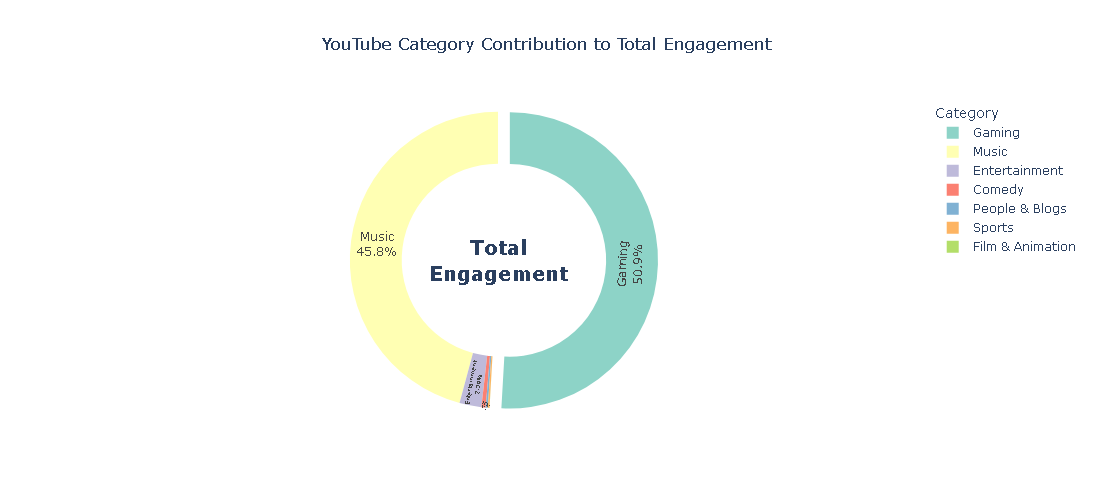

In [143]:
import plotly.express as px

donut_data = category_summary.sort_values(
    "Engagement_Share",
    ascending=False
)

fig = px.pie(

    donut_data,

    names="category_name",

    values="Engagement_Share",

    hole=0.65,

    title="YouTube Category Contribution to Total Engagement",

    color_discrete_sequence=px.colors.qualitative.Set3

)

fig.update_traces(

    textposition="inside",

    textinfo="percent+label",

    pull=[0.08]+[0]*(len(donut_data)-1),

    hovertemplate="<b>%{label}</b><br>Share: %{value:.2f}%<br><extra></extra>"

)

fig.add_annotation(

    text="<b>Total<br>Engagement</b>",

    x=0.5,

    y=0.5,

    showarrow=False,

    font=dict(size=20)

)

fig.update_layout(

    template="plotly_white",

    width=650,

    height=500,

    title_x=0.5,

    legend_title="Category"

)

fig.show()

# 🎉 Project Completed

## 📌 Conclusion

This project presents a comprehensive end-to-end analysis of YouTube Trending Videos using Python and modern data analytics techniques. The workflow includes data cleaning, feature engineering, exploratory data analysis (EDA), business intelligence, time series analysis, statistical hypothesis testing, and interactive visualizations.

### ✅ Key Achievements

- Data Cleaning & Preprocessing
- Feature Engineering
- Exploratory Data Analysis (EDA)
- 30 Business Questions
- Advanced Data Visualization
- Time Series Analysis
- Statistical Hypothesis Testing
- Business Recommendations
- Executive Dashboard

### 📊 Business Impact

The project provides valuable insights into video performance, audience engagement, content strategy, publishing behavior, and category trends. These findings can support data-driven decision-making for content creators, digital marketers, and business stakeholders.

---

**Tools & Technologies:**  
Python • Pandas • NumPy • Plotly • Seaborn • SciPy • Matplotlib • Jupyter Notebook

---

**Project Status:** ✅ Completed Successfully

# THE END >>>